In [2]:
# ============================================================
# CELLULE 1 : Imports et chargement des données
# Objectif : Charger toutes les librairies nécessaires
# et lire notre dataset principal
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Chargement du dataset...")
# ── Adapte le chemin si nécessaire ──
file_path = r"../data_final/final_data_ai_jobs_skills_exploded.csv"

df = pd.read_csv(file_path)
print(f"Dataset chargé : {df.shape[0]:,} lignes | {df.shape[1]} colonnes")
print(f"Offres uniques : {df['job_id'].nunique():,}")
print(f"Compétences uniques : {df['skill'].nunique():,}")
df.head(3)

Chargement du dataset...
Dataset chargé : 3,991,435 lignes | 16 colonnes
Offres uniques : 638,297
Compétences uniques : 28,277


,job_id,source,platform,job_title,country,city,date_posted,year,month,year_month,remote_status,experience_level,category,tools_used,original_file,skill
0,1,global_ai_jobs_dataset,Synthetic / Global,AI Researcher,Canada,Berlin,2021-04-01,2021,4.0,2021-04,Remote,Senior,Generative AI,Kubernetes;PyTorch;AWS,global_ai_jobs_dataset.csv,python
1,1,global_ai_jobs_dataset,Synthetic / Global,AI Researcher,Canada,Berlin,2021-04-01,2021,4.0,2021-04,Remote,Senior,Generative AI,Kubernetes;PyTorch;AWS,global_ai_jobs_dataset.csv,computer vision
2,1,global_ai_jobs_dataset,Synthetic / Global,AI Researcher,Canada,Berlin,2021-04-01,2021,4.0,2021-04,Remote,Senior,Generative AI,Kubernetes;PyTorch;AWS,global_ai_jobs_dataset.csv,sql


In [3]:
# ============================================================
# CELLULE 2 : Nettoyage des compétences
# Objectif : Réduire le bruit dans les 28 000 compétences
# uniques en normalisant et filtrant les rares
# ============================================================

# Normalisation : minuscules + suppression espaces
df['skill'] = df['skill'].str.lower().str.strip()

# Compter les occurrences de chaque compétence
skill_counts = df['skill'].value_counts()
print(f"Avant nettoyage : {len(skill_counts):,} compétences uniques")

# Garder seulement les compétences apparaissant >= 20 fois
# Pourquoi 20 ? Car en dessous c'est du bruit (fautes, skills trop spécifiques)
MIN_OCCURRENCES = 20
skills_to_keep = skill_counts[skill_counts >= MIN_OCCURRENCES].index
df_clean = df[df['skill'].isin(skills_to_keep)].copy()

print(f"Après nettoyage (>= {MIN_OCCURRENCES} occurrences) : {df_clean['skill'].nunique():,} compétences")
print(f"Lignes conservées : {len(df_clean):,} / {len(df):,} ({len(df_clean)/len(df)*100:.1f}%)")

# Filtrer les offres anormales (> 30 skills = probablement erreur de scraping)
skills_per_job = df_clean.groupby('job_id')['skill'].count()
normal_jobs = skills_per_job[skills_per_job <= 30].index
df_clean = df_clean[df_clean['job_id'].isin(normal_jobs)].copy()
print(f"Après filtrage offres anormales (>30 skills) : {len(df_clean):,} lignes")
print(f"Offres restantes : {df_clean['job_id'].nunique():,}")

Avant nettoyage : 28,277 compétences uniques
Après nettoyage (>= 20 occurrences) : 1,022 compétences
Lignes conservées : 3,940,021 / 3,991,435 (98.7%)
Après filtrage offres anormales (>30 skills) : 3,915,909 lignes
Offres restantes : 637,602


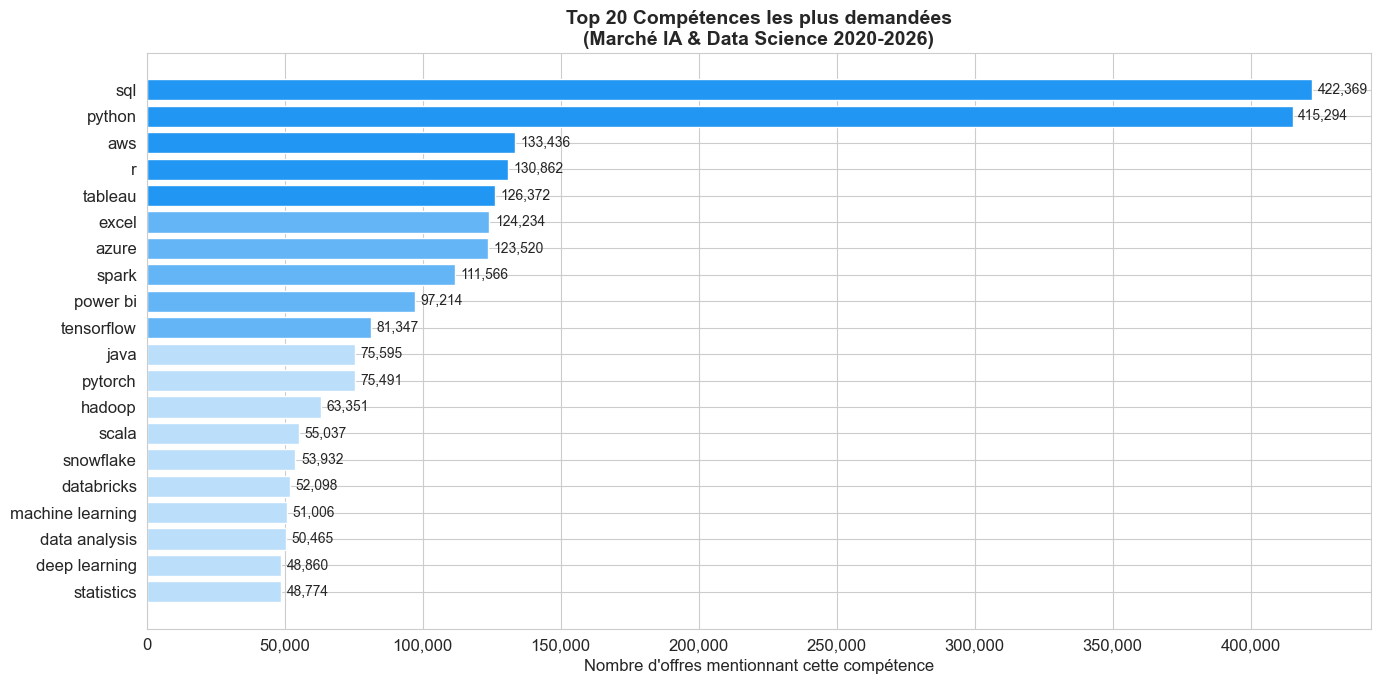


Top 20 compétences :
   1. sql                        422,369 occurrences
   2. python                     415,294 occurrences
   3. aws                        133,436 occurrences
   4. r                          130,862 occurrences
   5. tableau                    126,372 occurrences
   6. excel                      124,234 occurrences
   7. azure                      123,520 occurrences
   8. spark                      111,566 occurrences
   9. power bi                    97,214 occurrences
  10. tensorflow                  81,347 occurrences
  11. java                        75,595 occurrences
  12. pytorch                     75,491 occurrences
  13. hadoop                      63,351 occurrences
  14. scala                       55,037 occurrences
  15. snowflake                   53,932 occurrences
  16. databricks                  52,098 occurrences
  17. machine learning            51,006 occurrences
  18. data analysis               50,465 occurrences
  19. deep learning     

In [4]:
# ============================================================
# CELLULE 3 : Top 20 compétences globales
# Objectif : Visualiser les compétences les plus demandées
# dans tout le dataset (toutes années, tous pays)
# ============================================================

top_skills = df_clean['skill'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#2196F3' if i < 5 else '#64B5F6' if i < 10 else '#BBDEFB' 
          for i in range(20)]
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1], color=colors[::-1])

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, top_skills.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel("Nombre d'offres mentionnant cette compétence")
ax.set_title("Top 20 Compétences les plus demandées\n(Marché IA & Data Science 2020-2026)", 
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.savefig("top20_skills_global.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 20 compétences :")
for i, (skill, count) in enumerate(top_skills.items(), 1):
    print(f"  {i:2}. {skill:<25} {count:>8,} occurrences")

Catégories disponibles :
category
Data Engineer            1117334
Data Scientist            779136
Data Analyst              619888
Senior Data Engineer      310595
Senior Data Scientist     179130
Business Analyst          130692
Senior Data Analyst       113728
Computer Vision            96288
NLP                        96100
Robotics                   96036
Name: count, dtype: int64


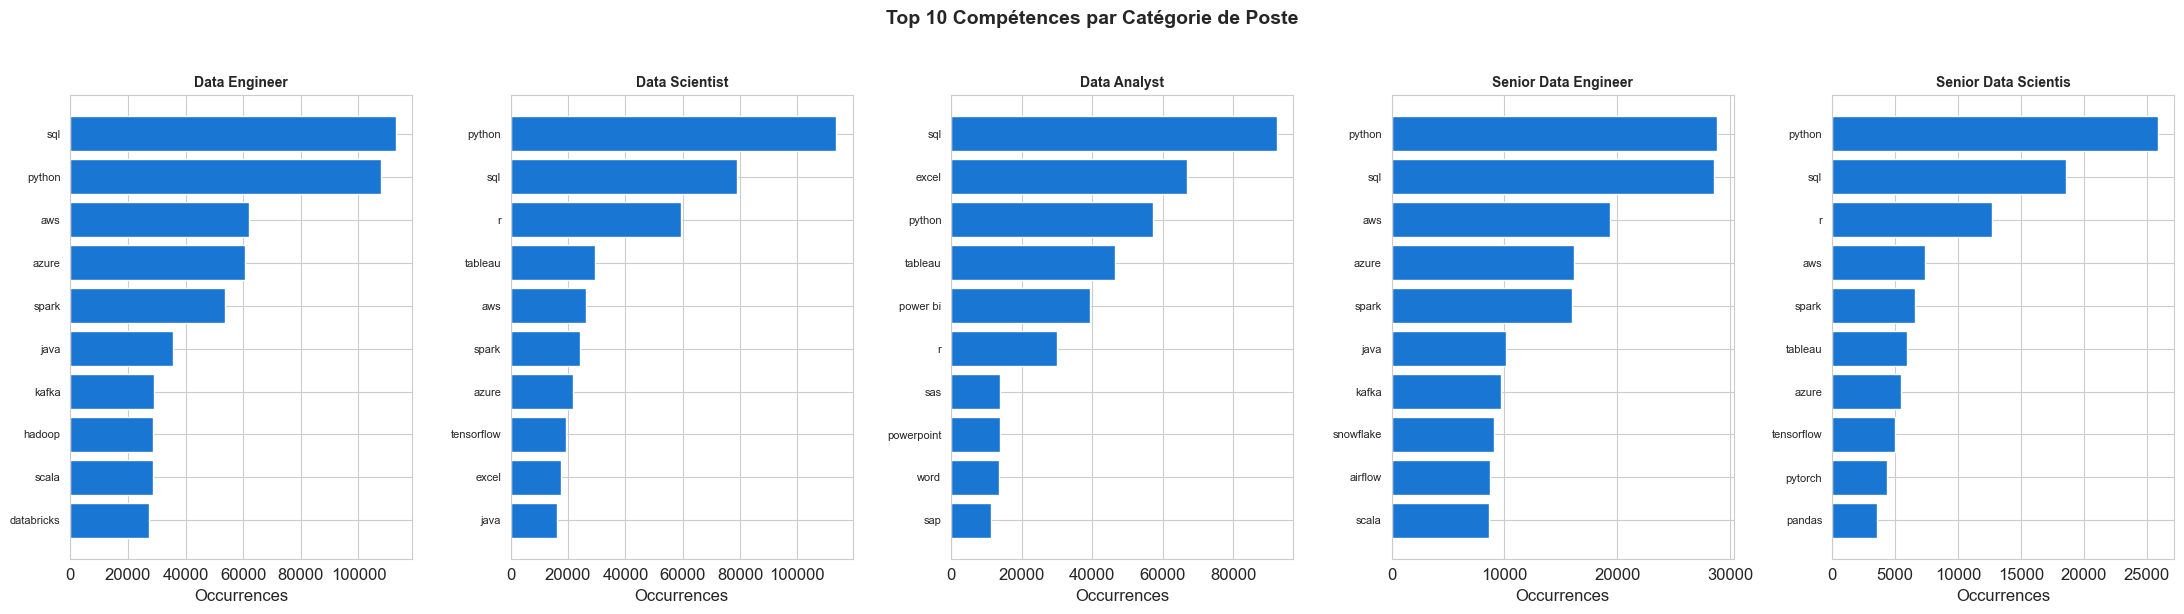

In [5]:
# ============================================================
# CELLULE 4 : Top skills par catégorie de poste
# Objectif : Comprendre quelles compétences sont spécifiques
# à chaque métier IA/Data
# ============================================================

# Vérifier la colonne catégorie
print("Catégories disponibles :")
print(df_clean['category'].value_counts().head(10))

# Top 5 catégories les plus fréquentes
top_categories = df_clean['category'].value_counts().head(5).index

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle("Top 10 Compétences par Catégorie de Poste", 
             fontsize=14, fontweight='bold', y=1.02)

for idx, cat in enumerate(top_categories):
    cat_data = df_clean[df_clean['category'] == cat]
    top = cat_data['skill'].value_counts().head(10)
    
    axes[idx].barh(top.index[::-1], top.values[::-1], color='#1976D2')
    axes[idx].set_title(f"{cat[:20]}", fontsize=10, fontweight='bold')
    axes[idx].set_xlabel("Occurrences")
    axes[idx].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig("skills_by_category.png", dpi=150, bbox_inches='tight')
plt.show()

Top 5 pays analysés : ['United States', 'India', 'United Kingdom', 'France', 'Germany']

⚠️  BIAIS : Les USA représentent ~30% du dataset
   → Les résultats USA ne reflètent pas forcément la réalité mondiale



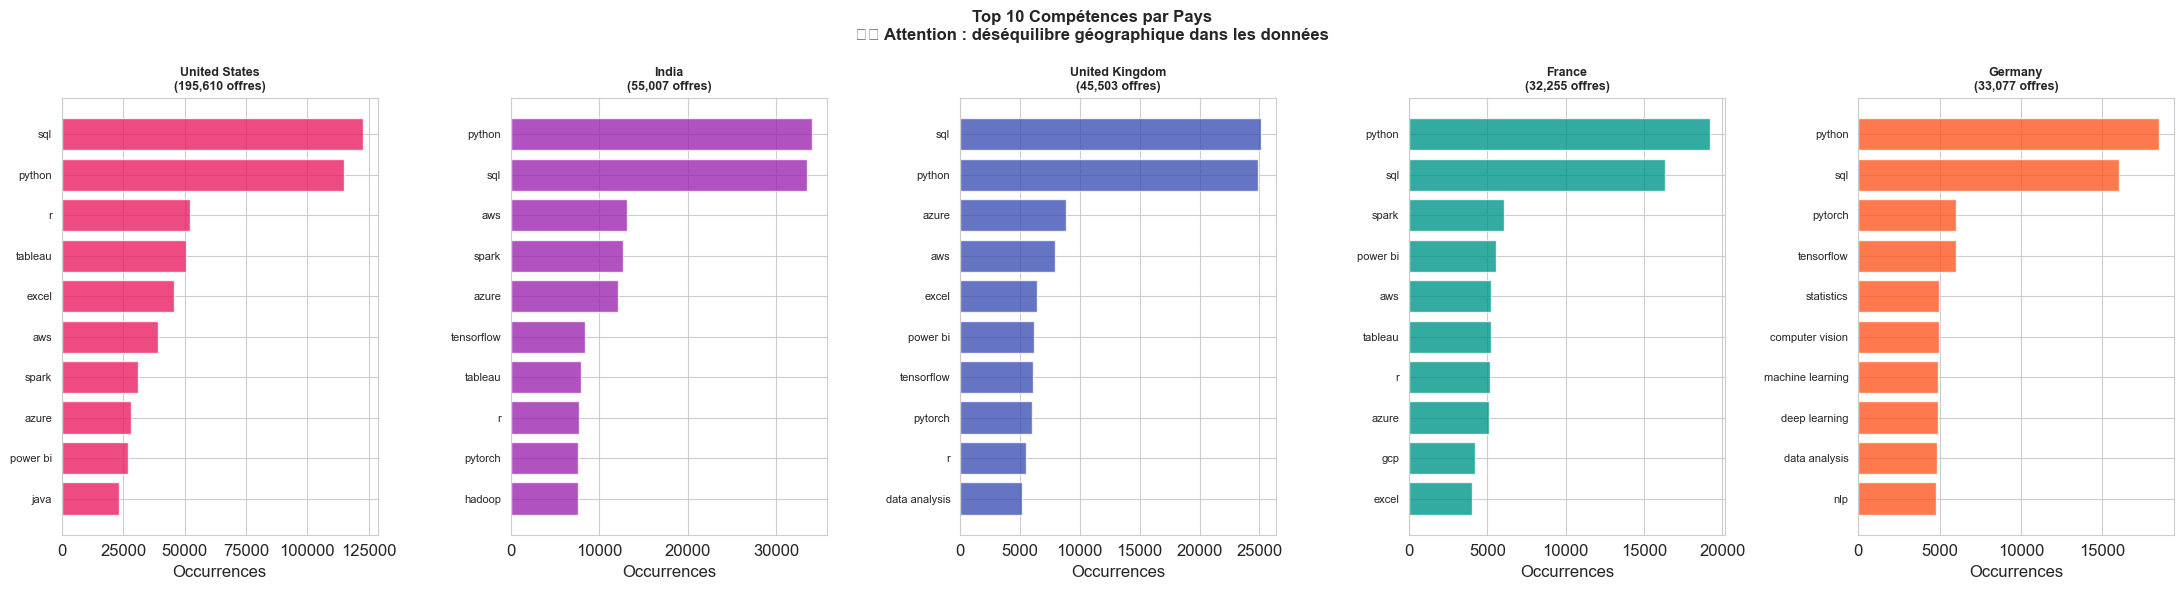

In [6]:
# ============================================================
# CELLULE 5 : Top skills par pays
# Objectif : Comparer les écosystèmes technologiques
# par pays (avec mention du biais de représentation)
# BIAIS IMPORTANT : USA surreprésenté dans notre dataset
# ============================================================

top_countries = df_clean['country'].value_counts().head(5).index
print("Top 5 pays analysés :", list(top_countries))
print("\n⚠️  BIAIS : Les USA représentent ~30% du dataset")
print("   → Les résultats USA ne reflètent pas forcément la réalité mondiale\n")

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle("Top 10 Compétences par Pays\n⚠️ Attention : déséquilibre géographique dans les données", 
             fontsize=12, fontweight='bold')

country_colors = ['#E91E63', '#9C27B0', '#3F51B5', '#009688', '#FF5722']

for idx, country in enumerate(top_countries):
    country_data = df_clean[df_clean['country'] == country]
    top = country_data['skill'].value_counts().head(10)
    
    axes[idx].barh(top.index[::-1], top.values[::-1], 
                   color=country_colors[idx], alpha=0.8)
    n_jobs = country_data['job_id'].nunique()
    axes[idx].set_title(f"{country}\n({n_jobs:,} offres)", fontsize=9, fontweight='bold')
    axes[idx].set_xlabel("Occurrences")
    axes[idx].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig("skills_by_country.png", dpi=150, bbox_inches='tight')
plt.show()

Construction de la matrice de co-occurrence...
(Cela peut prendre quelques minutes avec 4M de lignes)


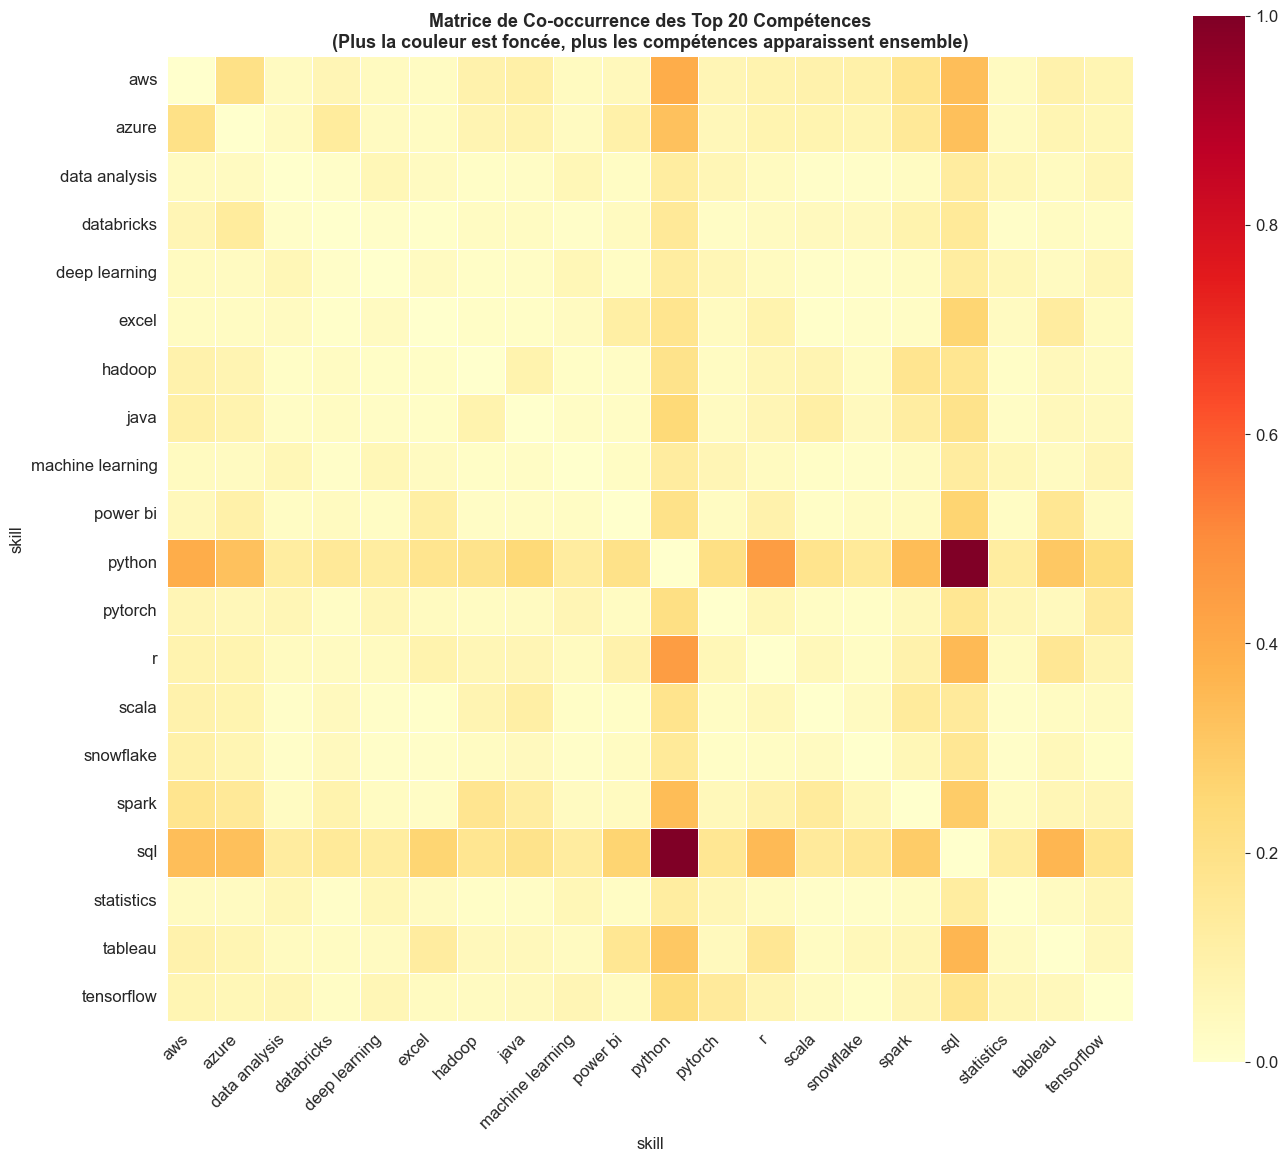


Top 10 paires de compétences les plus co-occurrentes :
  python               ↔ sql                  : 270,906 offres communes
  python               ↔ r                    : 120,696 offres communes
  aws                  ↔ python               : 106,118 offres communes
  sql                  ↔ tableau              : 98,265 offres communes
  r                    ↔ sql                  : 94,588 offres communes
  python               ↔ spark                : 92,895 offres communes
  aws                  ↔ sql                  : 91,232 offres communes
  azure                ↔ sql                  : 89,707 offres communes
  azure                ↔ python               : 87,903 offres communes
  python               ↔ tableau              : 83,211 offres communes


In [7]:
# ============================================================
# CELLULE 6 : Heatmap des co-occurrences (écosystèmes)
# Objectif : Montrer visuellement que les compétences
# forment des groupes / écosystèmes technologiques
# C'est la base théorique pour le Graph Mining
# ============================================================

# Top 20 skills pour la heatmap
top_20 = df_clean['skill'].value_counts().head(20).index.tolist()

# Créer matrice de co-occurrence
print("Construction de la matrice de co-occurrence...")
print("(Cela peut prendre quelques minutes avec 4M de lignes)")

# Pivoter : une ligne par job, une colonne par skill (1 si présent, 0 sinon)
df_pivot = df_clean[df_clean['skill'].isin(top_20)].copy()
job_skill_matrix = df_pivot.groupby(['job_id', 'skill']).size().unstack(fill_value=0)
job_skill_matrix = (job_skill_matrix > 0).astype(int)

# Matrice de co-occurrence = produit matriciel
co_matrix = job_skill_matrix.T.dot(job_skill_matrix)
np.fill_diagonal(co_matrix.values, 0)  # Diagonale à 0

# Normalisation pour rendre comparable
co_matrix_norm = co_matrix.div(co_matrix.max().max())

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(co_matrix_norm, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Triangle supérieur masqué

sns.heatmap(co_matrix_norm, 
            annot=False, 
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax,
            square=True)

ax.set_title("Matrice de Co-occurrence des Top 20 Compétences\n(Plus la couleur est foncée, plus les compétences apparaissent ensemble)", 
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 paires de compétences les plus co-occurrentes :")
co_upper = co_matrix.where(np.triu(np.ones(co_matrix.shape), k=1).astype(bool))
top_pairs = co_upper.stack().sort_values(ascending=False).head(10)
for (s1, s2), val in top_pairs.items():
    print(f"  {s1:<20} ↔ {s2:<20} : {int(val):,} offres communes")

⚠️  AVERTISSEMENT BIAIS TEMPOREL
Distribution des années dans notre dataset :
  2020 : █     79,992 (2.0%)
  2021 : █     80,644 (2.1%)
  2022 : █     79,412 (2.0%)
  2023 : ███████████████████████████████████████████  3,405,416 (87.0%)
  2024 : ██    178,282 (4.6%)
  2025 : █     83,586 (2.1%)
  2026 :       8,577 (0.2%)

→ 2023 domine massivement = biais de collecte
→ Les tendances temporelles ne sont PAS interprétables



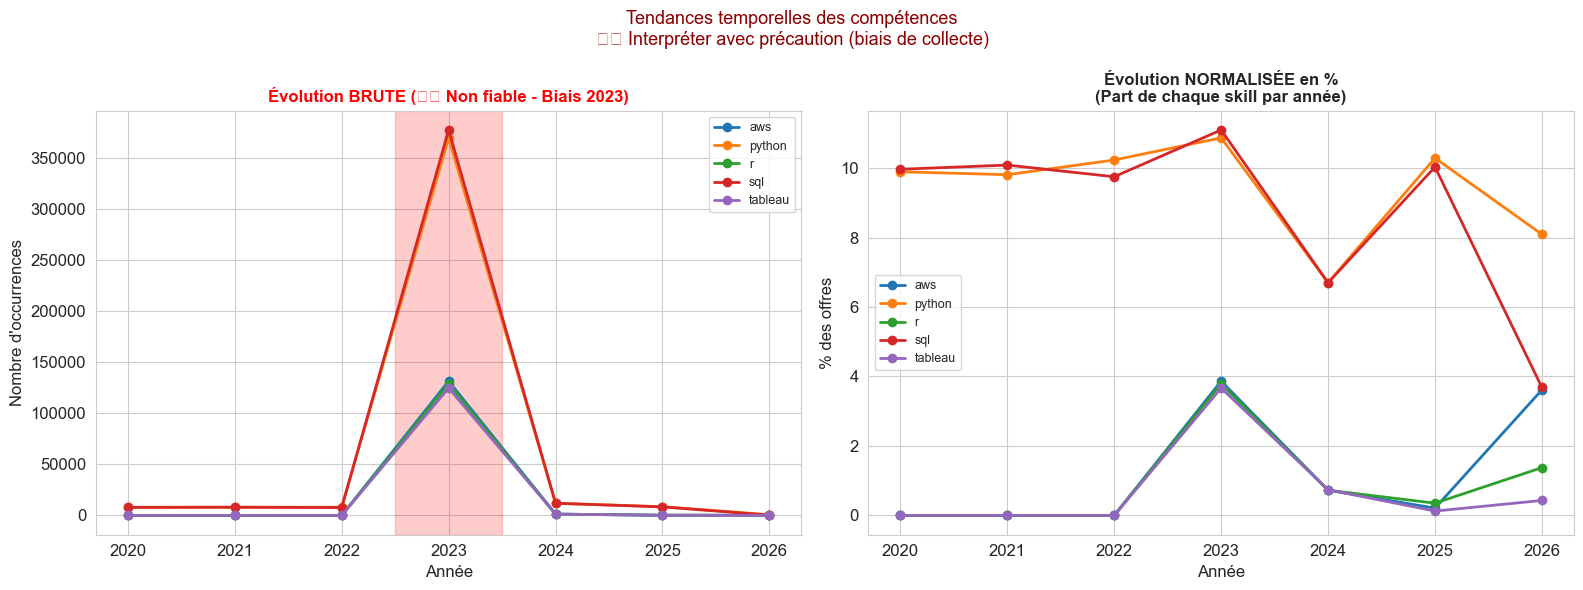

In [8]:
# ============================================================
# CELLULE 7 : Évolution temporelle des compétences
# ATTENTION - BIAIS MAJEUR :
# 2023 = 85% des données (3.4M lignes sur 4M)
# L'évolution observée reflète la collecte des données
# et NON une tendance réelle du marché
# On l'affiche mais avec un avertissement explicite
# ============================================================

print("="*60)
print("⚠️  AVERTISSEMENT BIAIS TEMPOREL")
print("="*60)
print("Distribution des années dans notre dataset :")
year_dist = df_clean['year'].value_counts().sort_index()
for year, count in year_dist.items():
    pct = count / len(df_clean) * 100
    bar = "█" * int(pct/2)
    print(f"  {year} : {bar} {count:>10,} ({pct:.1f}%)")
print("\n→ 2023 domine massivement = biais de collecte")
print("→ Les tendances temporelles ne sont PAS interprétables\n")

# Malgré le biais, on trace pour montrer la structure
top_5_skills = df_clean['skill'].value_counts().head(5).index.tolist()
df_temporal = df_clean[df_clean['skill'].isin(top_5_skills)]
evolution = df_temporal.groupby(['year', 'skill']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique brut (biaisé)
evolution.plot(ax=ax1, marker='o', linewidth=2)
ax1.set_title("Évolution BRUTE (⚠️ Non fiable - Biais 2023)", 
              fontsize=12, color='red', fontweight='bold')
ax1.set_xlabel("Année")
ax1.set_ylabel("Nombre d'occurrences")
ax1.legend(fontsize=9)
ax1.axvspan(2022.5, 2023.5, alpha=0.2, color='red', label='Période sur-représentée')

# Graphique normalisé par total annuel (moins biaisé)
total_per_year = df_clean.groupby('year').size()
evolution_norm = evolution.div(total_per_year, axis=0) * 100

evolution_norm.plot(ax=ax2, marker='o', linewidth=2)
ax2.set_title("Évolution NORMALISÉE en %\n(Part de chaque skill par année)", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Année")
ax2.set_ylabel("% des offres")
ax2.legend(fontsize=9)

plt.suptitle("Tendances temporelles des compétences\n⚠️ Interpréter avec précaution (biais de collecte)", 
             fontsize=13, color='darkred')
plt.tight_layout()
plt.savefig("skills_evolution_temporal.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# CELLULE 8 : Sauvegarde et résumé
# Objectif : Sauvegarder df_clean pour les notebooks
# 06_graph_mining et 07_forecasting
# ============================================================

# Sauvegarder le dataset nettoyé
df_clean.to_csv("skills_data_clean.csv", index=False)
print("✅ Dataset nettoyé sauvegardé : skills_data_clean.csv")
print(f"   - {len(df_clean):,} lignes")
print(f"   - {df_clean['job_id'].nunique():,} offres")
print(f"   - {df_clean['skill'].nunique():,} compétences uniques")

# Sauvegarder la matrice de co-occurrence pour Graph Mining
co_matrix.to_csv("cooccurrence_matrix.csv")
print("✅ Matrice de co-occurrence sauvegardée : cooccurrence_matrix.csv")

# Résumé final
print("\n" + "="*50)
print("RÉSUMÉ - 05_skills_analysis.ipynb")
print("="*50)
print("""
CONCLUSION :
- SQL et Python sont les compétences dominantes du marché
- 3 écosystèmes distincts identifiés :
  1. BI/Analytics : SQL, Tableau, Power BI, Excel
  2. ML/IA       : Python, TensorFlow, PyTorch, Deep Learning
  3. Cloud/Big Data : AWS, Azure, Spark, Hadoop
- Python est la compétence centrale (hub du réseau)
- Prêt pour le Graph Mining (notebook 06)

⚠️ BIAIS IMPORTANTS À MENTIONNER DANS LE RAPPORT :
- 2023 = 85% des données → évolution temporelle non fiable
- USA surreprésenté → comparaison géographique limitée
- Source Kaggle dominante → peut refléter des biais de plateforme
""")

✅ Dataset nettoyé sauvegardé : skills_data_clean.csv
   - 3,915,909 lignes
   - 637,602 offres
   - 1,022 compétences uniques
✅ Matrice de co-occurrence sauvegardée : cooccurrence_matrix.csv

RÉSUMÉ - 05_skills_analysis.ipynb

CONCLUSION :
- SQL et Python sont les compétences dominantes du marché
- 3 écosystèmes distincts identifiés :
  1. BI/Analytics : SQL, Tableau, Power BI, Excel
  2. ML/IA       : Python, TensorFlow, PyTorch, Deep Learning
  3. Cloud/Big Data : AWS, Azure, Spark, Hadoop
- Python est la compétence centrale (hub du réseau)
- Prêt pour le Graph Mining (notebook 06)

⚠️ BIAIS IMPORTANTS À MENTIONNER DANS LE RAPPORT :
- 2023 = 85% des données → évolution temporelle non fiable
- USA surreprésenté → comparaison géographique limitée
- Source Kaggle dominante → peut refléter des biais de plateforme



📁 Dossier images_rapport créé


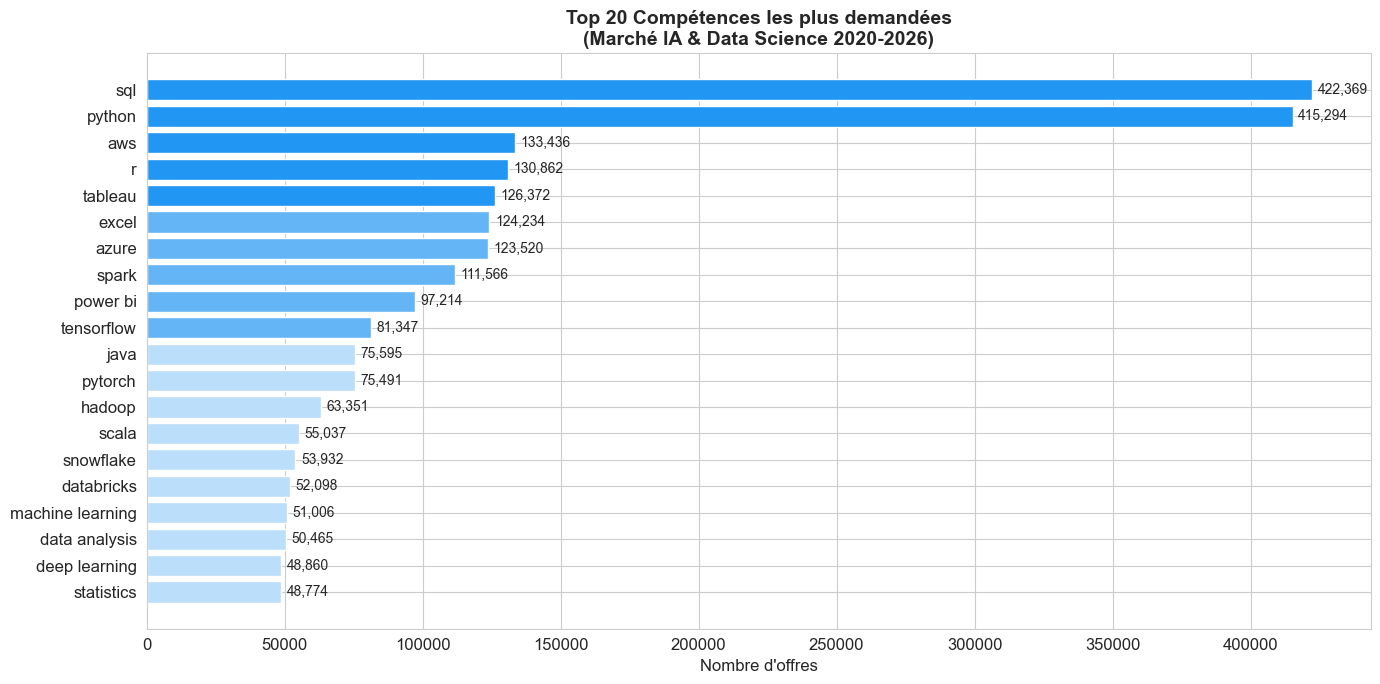

✅ Sauvegardé : top20_skills_global.png


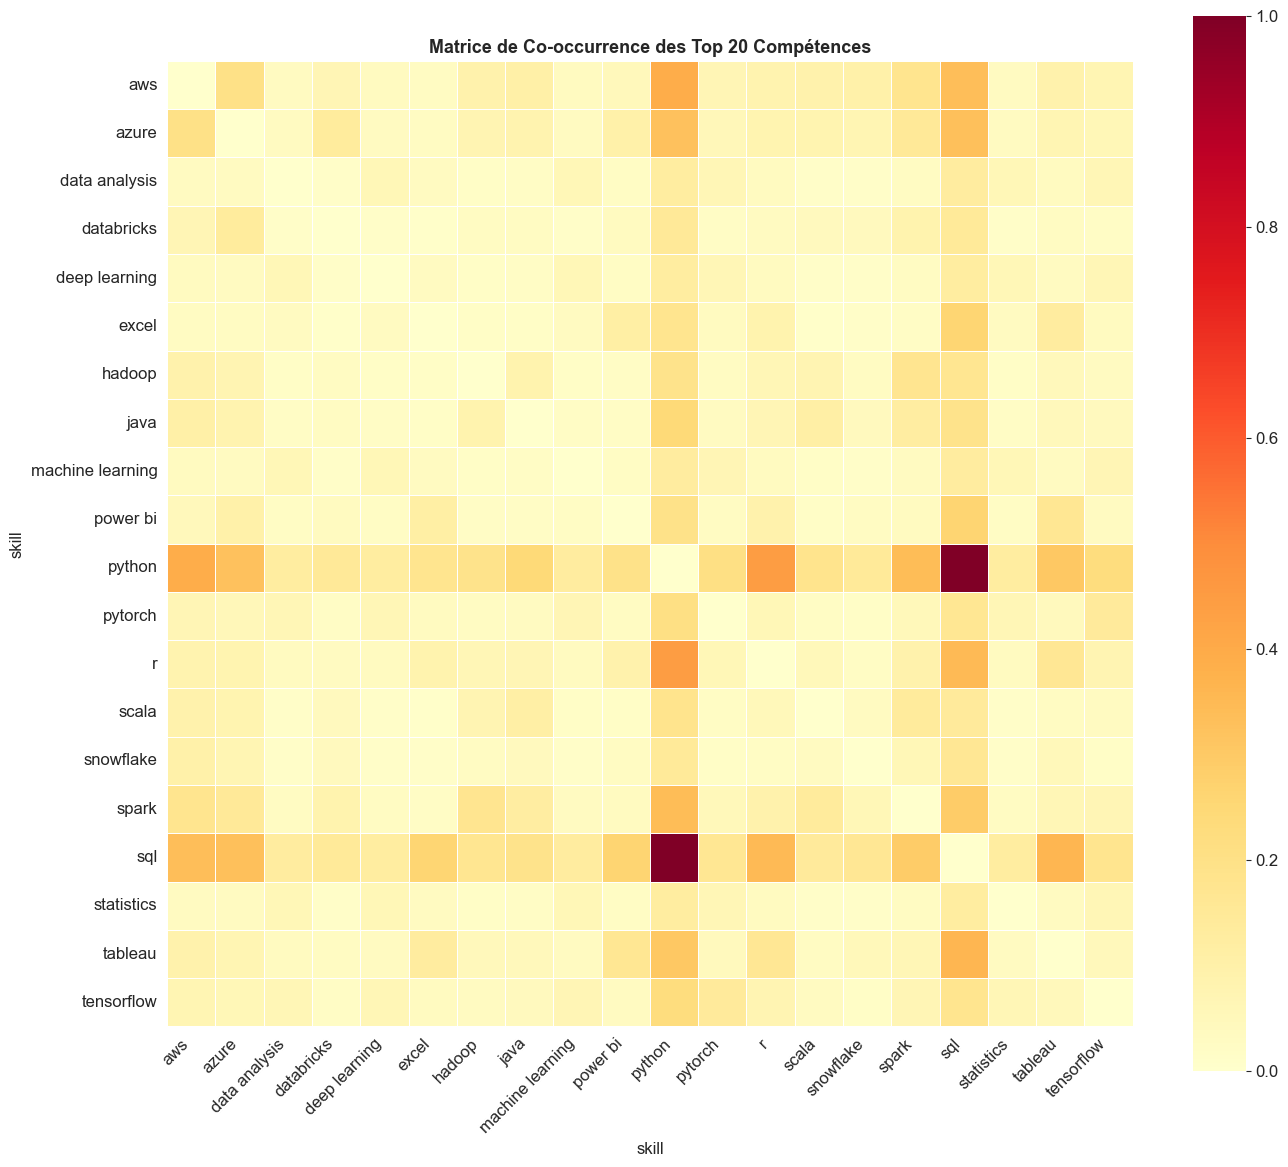

✅ Sauvegardé : cooccurrence_heatmap.png


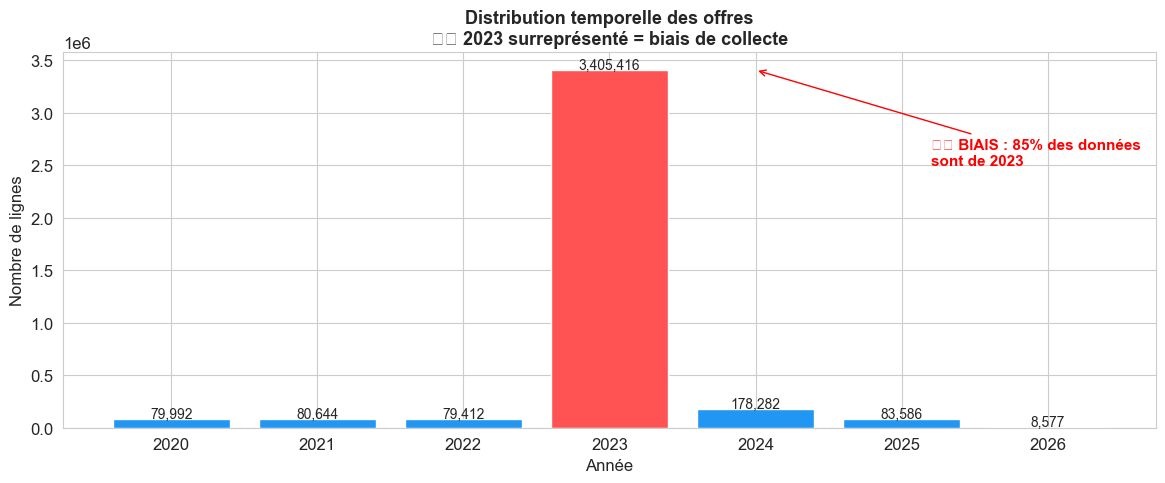

✅ Sauvegardé : distribution_temporelle.png


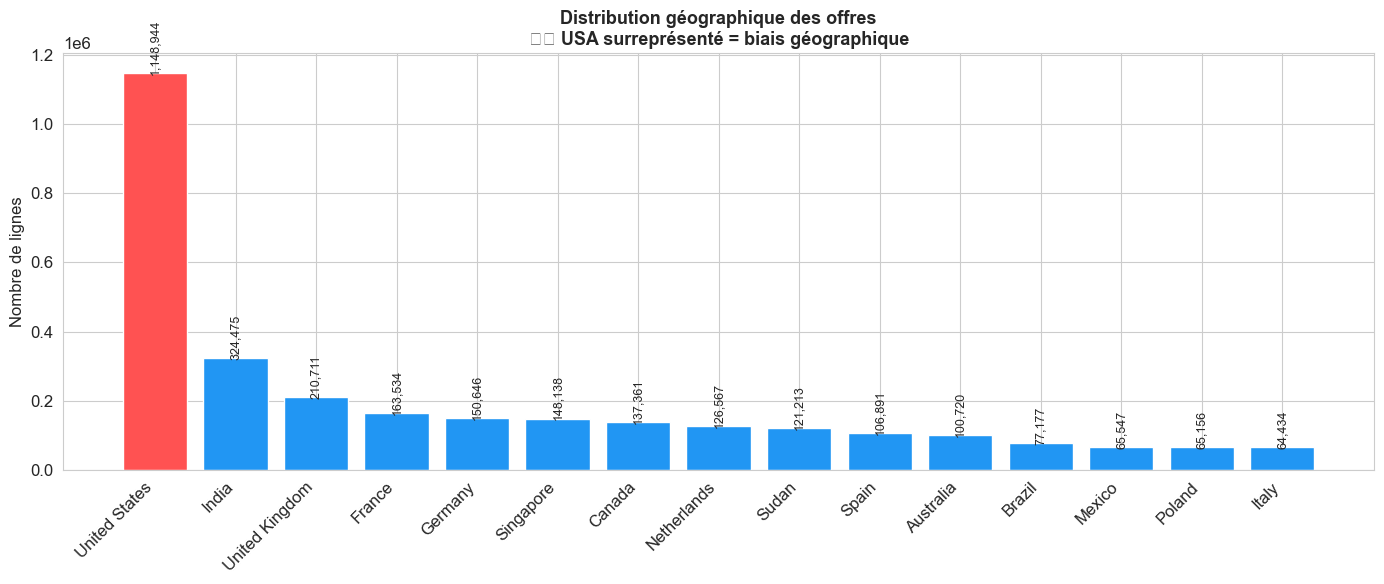

✅ Sauvegardé : distribution_geographique.png


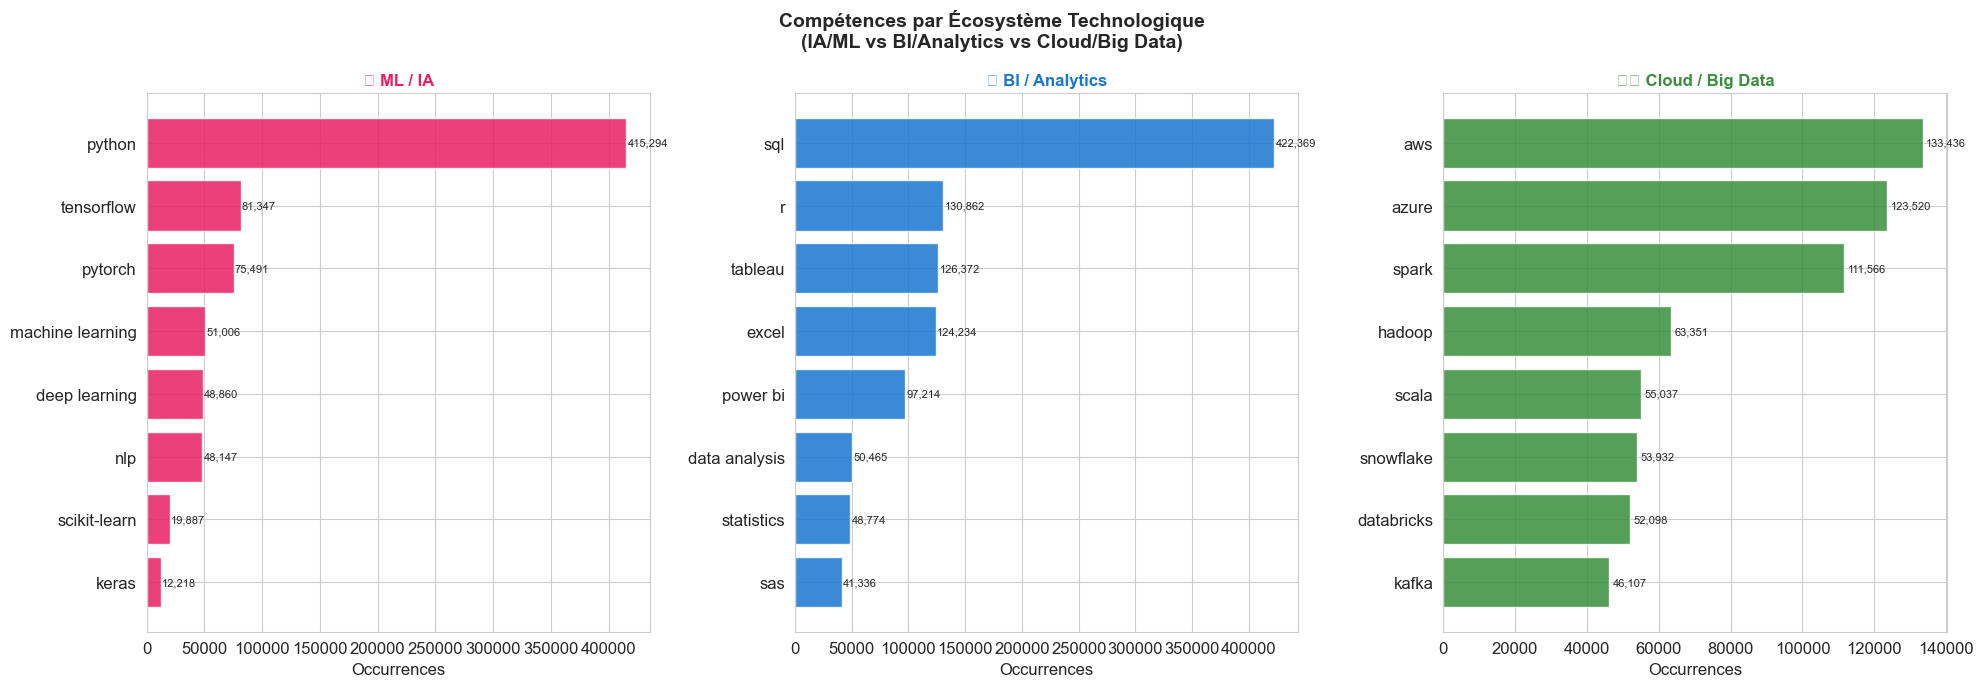

✅ Sauvegardé : ecosystems_skills.png

✅ TOUTES LES IMAGES SAUVEGARDÉES
  📸 cooccurrence_heatmap.png                      133 KB
  📸 distribution_geographique.png                 104 KB
  📸 distribution_temporelle.png                   62 KB
  📸 ecosystems_skills.png                         125 KB
  📸 top20_skills_global.png                       113 KB

Dossier : images_rapport/
Prêt pour le rapport final !


In [10]:
# ============================================================
# CELLULE SAUVEGARDE IMAGES
# Objectif : Sauvegarder tous les graphiques du notebook 05
# en PNG haute qualité pour le rapport final
# ============================================================

import matplotlib.pyplot as plt
import os

# Créer un dossier pour les images
os.makedirs("images_rapport", exist_ok=True)
print("📁 Dossier images_rapport créé")

# ---- IMAGE 1 : Top 20 skills global ----
top_skills = df_clean['skill'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#2196F3' if i < 5 else '#64B5F6' if i < 10 else '#BBDEFB' 
          for i in range(20)]
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1], color=colors[::-1])
for bar, val in zip(bars, top_skills.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_xlabel("Nombre d'offres")
ax.set_title("Top 20 Compétences les plus demandées\n(Marché IA & Data Science 2020-2026)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("images_rapport/top20_skills_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : top20_skills_global.png")

# ---- IMAGE 2 : Heatmap co-occurrence ----
# (déjà calculée, on la refait proprement)
top_20 = df_clean['skill'].value_counts().head(20).index.tolist()
df_pivot = df_clean[df_clean['skill'].isin(top_20)].copy()
job_skill_matrix = df_pivot.groupby(['job_id', 'skill']).size().unstack(fill_value=0)
job_skill_matrix = (job_skill_matrix > 0).astype(int)
co_matrix = job_skill_matrix.T.dot(job_skill_matrix)
np.fill_diagonal(co_matrix.values, 0)
co_matrix_norm = co_matrix.div(co_matrix.max().max())

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(co_matrix_norm, annot=False, cmap='YlOrRd',
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Matrice de Co-occurrence des Top 20 Compétences",
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("images_rapport/cooccurrence_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : cooccurrence_heatmap.png")

# ---- IMAGE 3 : Distribution temporelle (avec biais) ----
year_dist = df_clean['year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
colors_year = ['#FF5252' if y == 2023 else '#2196F3' for y in year_dist.index]
bars = ax.bar(year_dist.index.astype(str), year_dist.values, color=colors_year)
for bar, val in zip(bars, year_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title("Distribution temporelle des offres\n⚠️ 2023 surreprésenté = biais de collecte",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de lignes")
ax.annotate("⚠️ BIAIS : 85% des données\nsont de 2023",
            xy=(4, year_dist.values[year_dist.index == 2023][0]),
            xytext=(5.2, 2500000),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red', fontweight='bold')
plt.tight_layout()
plt.savefig("images_rapport/distribution_temporelle.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : distribution_temporelle.png")

# ---- IMAGE 4 : Distribution géographique ----
top_countries = df_clean['country'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 6))
colors_country = ['#FF5252' if c == 'United States' else '#2196F3' 
                  for c in top_countries.index]
bars = ax.bar(range(len(top_countries)), top_countries.values, color=colors_country)
ax.set_xticks(range(len(top_countries)))
ax.set_xticklabels(top_countries.index, rotation=45, ha='right')
for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,}', ha='center', fontsize=9, rotation=90)
ax.set_title("Distribution géographique des offres\n⚠️ USA surreprésenté = biais géographique",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.savefig("images_rapport/distribution_geographique.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : distribution_geographique.png")

# ---- IMAGE 5 : Top skills par écosystème ----
ecosystems = {
    '🤖 ML / IA': ['python', 'tensorflow', 'pytorch', 'deep learning', 
                    'machine learning', 'nlp', 'keras', 'scikit-learn'],
    '📊 BI / Analytics': ['sql', 'tableau', 'power bi', 'excel', 
                           'r', 'statistics', 'data analysis', 'sas'],
    '☁️ Cloud / Big Data': ['aws', 'azure', 'spark', 'hadoop', 
                              'snowflake', 'databricks', 'scala', 'kafka']
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
eco_colors = ['#E91E63', '#1976D2', '#388E3C']

for idx, (eco_name, eco_skills) in enumerate(ecosystems.items()):
    existing = [s for s in eco_skills if s in df_clean['skill'].values]
    eco_data = df_clean[df_clean['skill'].isin(existing)]['skill'].value_counts()
    
    axes[idx].barh(eco_data.index[::-1], eco_data.values[::-1], 
                   color=eco_colors[idx], alpha=0.85)
    axes[idx].set_title(eco_name, fontsize=12, fontweight='bold', 
                         color=eco_colors[idx])
    axes[idx].set_xlabel("Occurrences")
    for i, (val, skill) in enumerate(zip(eco_data.values[::-1], eco_data.index[::-1])):
        axes[idx].text(val + 1000, i, f'{val:,}', va='center', fontsize=8)

plt.suptitle("Compétences par Écosystème Technologique\n(IA/ML vs BI/Analytics vs Cloud/Big Data)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("images_rapport/ecosystems_skills.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : ecosystems_skills.png")

# ---- RÉSUMÉ FINAL ----
print("\n" + "="*50)
print("✅ TOUTES LES IMAGES SAUVEGARDÉES")
print("="*50)
images = os.listdir("images_rapport")
for img in sorted(images):
    size = os.path.getsize(f"images_rapport/{img}") / 1024
    print(f"  📸 {img:<45} {size:.0f} KB")
print(f"\nDossier : images_rapport/")
print("Prêt pour le rapport final !")

In [11]:
# ============================================================
# CELLULE 1 : Installation et imports
# Lien avec notebook 05 : on utilise skills_data_clean.csv
# Objectif : charger les librairies Graph Mining
# Le prof demande : NetworkX + PageRank + Louvain
# ============================================================

import subprocess
subprocess.run(["pip", "install", "python-louvain", "networkx"], 
               capture_output=True)

import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies chargées")
print(f"   NetworkX version : {nx.__version__}")

plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 11

✅ Librairies chargées
   NetworkX version : 3.4.2


In [12]:
# ============================================================
# CELLULE 2 : Chargement et création des paires
#
# Lien avec notebook 05 : skills_data_clean.csv vient du
# nettoyage qu'on a fait (1022 compétences propres)
#
# Objectif : transformer le dataset "offre ↔ skill"
# en dataset "skill ↔ skill" avec poids
#
# Logique :
#   - Une offre avec [python, sql, aws]
#   → génère (python,sql), (python,aws), (sql,aws)
#   - On compte combien d'offres partagent chaque paire
#   → ce nombre devient le POIDS du lien dans le graphe
# ============================================================

print("Chargement de skills_data_clean.csv...")
df = pd.read_csv("skills_data_clean.csv", low_memory=False)
print(f"✅ Dataset chargé : {df.shape[0]:,} lignes")
print(f"   Offres uniques : {df['job_id'].nunique():,}")
print(f"   Compétences uniques : {df['skill'].nunique():,}")

# Garder les top 50 compétences pour un graphe lisible
# Pourquoi 50 ? Un graphe avec 1022 nœuds est illisible
# 50 nœuds = graphe clair et interprétable
N_TOP = 50
top_skills = df['skill'].value_counts().head(N_TOP).index.tolist()
df_top = df[df['skill'].isin(top_skills)].copy()
print(f"\n→ On garde les top {N_TOP} compétences pour le graphe")
print(f"→ Lignes filtrées : {len(df_top):,}")

# Créer toutes les paires de co-occurrence
from itertools import combinations

print("\nCréation des paires de co-occurrence...")
print("(2-3 minutes avec 3.9M lignes, patience...)")

pairs = []
for job_id, group in df_top.groupby('job_id')['skill']:
    skills_list = list(group)
    if len(skills_list) >= 2:
        for s1, s2 in combinations(sorted(skills_list), 2):
            pairs.append((s1, s2))

df_pairs = pd.DataFrame(pairs, columns=['skill1', 'skill2'])
df_pairs_count = (df_pairs
                  .groupby(['skill1', 'skill2'])
                  .size()
                  .reset_index(name='weight')
                  .sort_values('weight', ascending=False))

print(f"✅ Paires créées : {len(df_pairs_count):,}")
print("\nTop 10 paires les plus fréquentes :")
print(df_pairs_count.head(10).to_string(index=False))

Chargement de skills_data_clean.csv...
✅ Dataset chargé : 3,915,909 lignes
   Offres uniques : 629,189
   Compétences uniques : 1,022

→ On garde les top 50 compétences pour le graphe
→ Lignes filtrées : 3,299,038

Création des paires de co-occurrence...
(2-3 minutes avec 3.9M lignes, patience...)
✅ Paires créées : 1,261

Top 10 paires les plus fréquentes :
skill1  skill2  weight
python     sql  323767
python       r  130819
   aws  python  114984
   sql tableau  105923
     r     sql  102203
python   spark  100546
   aws     sql   98611
 azure     sql   96874
 azure  python   95137
python tableau   89801


In [13]:
# ============================================================
# CELLULE 3 : Construction du graphe NetworkX
#
# Objectif : Créer l'objet graphe où :
#   NŒUD = une compétence
#   LIEN = les deux compétences apparaissent ensemble
#   POIDS = nombre d'offres qui demandent les deux
#
# Pourquoi filtrer à MIN_WEIGHT = 1000 ?
#   → Garder seulement les relations fortes
#   → Éviter le bruit (deux skills qui apparaissent
#     ensemble par hasard dans 5 offres n'est pas
#     une vraie relation)
# ============================================================

MIN_WEIGHT = 1000
df_edges = df_pairs_count[df_pairs_count['weight'] >= MIN_WEIGHT].copy()
print(f"Liens avec poids >= {MIN_WEIGHT} : {len(df_edges):,}")

# Construire le graphe
G = nx.Graph()

# Ajouter les nœuds avec leur fréquence
skill_freq = df['skill'].value_counts()
for skill in top_skills:
    G.add_node(skill, frequency=int(skill_freq.get(skill, 0)))

# Ajouter les liens pondérés
for _, row in df_edges.iterrows():
    G.add_edge(row['skill1'], row['skill2'], weight=row['weight'])

# Garder seulement la composante connexe principale
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    print(f"→ Composante principale gardée")

print(f"\n📊 STRUCTURE DU GRAPHE :")
print(f"   Nœuds  : {G.number_of_nodes()} compétences")
print(f"   Liens  : {G.number_of_edges()} co-occurrences")
print(f"   Densité : {nx.density(G):.4f}")
print(f"   Connexe : {nx.is_connected(G)}")

Liens avec poids >= 1000 : 1,100

📊 STRUCTURE DU GRAPHE :
   Nœuds  : 50 compétences
   Liens  : 1100 co-occurrences
   Densité : 0.8980
   Connexe : True


Calcul des métriques de centralité...

🏆 TOP 15 COMPÉTENCES PAR PAGERANK :
-----------------------------------------------------------------
Rang  Compétence           PageRank     Degree     Fréquence
-----------------------------------------------------------------
1     python               0.09870      1.041      415,294
2     sql                  0.09601      1.041      422,369
3     aws                  0.04045      1.000      133,436
4     spark                0.03700      1.000      111,566
5     azure                0.03602      1.000      123,520
6     r                    0.03221      1.000      130,862
7     tableau              0.03163      1.000      126,372
8     tensorflow           0.02715      1.041      81,347
9     pytorch              0.02533      1.041      75,491
10    java                 0.02532      0.980      75,595
11    power bi             0.02318      1.000      97,214
12    hadoop               0.02304      0.980      63,351
13    excel                0.

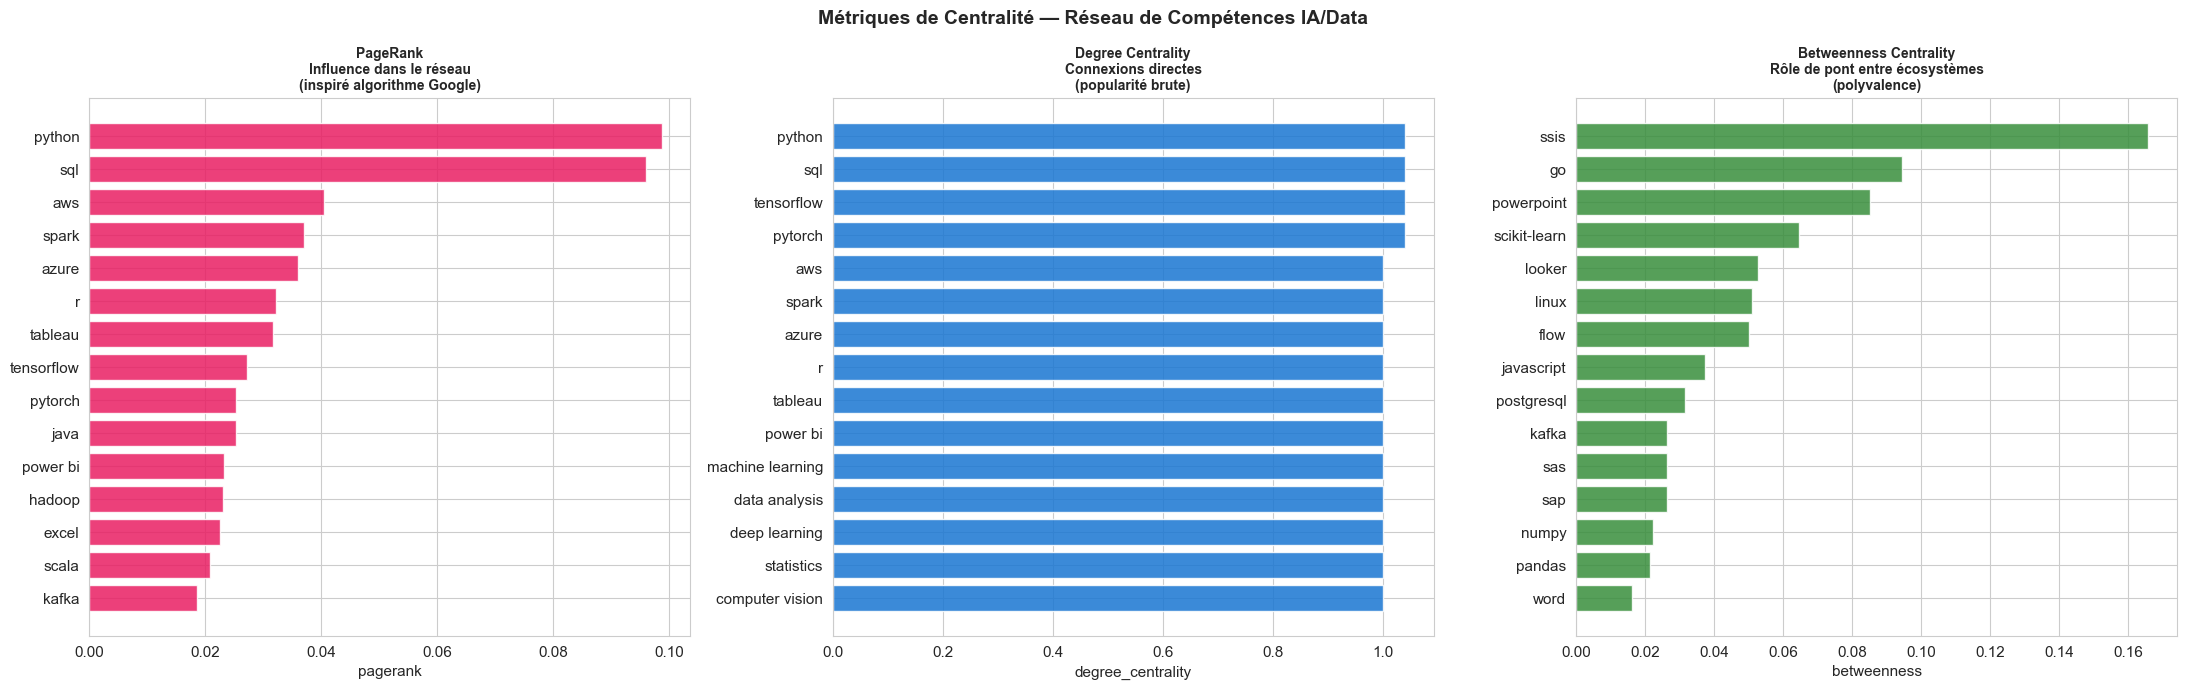

✅ Sauvegardé : centrality_metrics.png
✅ Données sauvegardées : centrality_results.csv


In [14]:
# ============================================================
# CELLULE 4 : Métriques de centralité
#
# Lien avec le proposal du prof :
# "quantifier l'autorité (PageRank) et détecter
#  les pôles d'influence du marché"
#
# DEGREE CENTRALITY :
#   Formule : degree(v) / (n-1)
#   Interprétation : % de skills avec lesquels ce skill
#   est co-demandé directement
#   Ex : python a degree=0.9 → connecté à 90% des skills
#
# PAGERANK :
#   Inspiré de l'algorithme Google
#   Un skill est influent si connecté à des skills
#   eux-mêmes influents
#   Ex : python connecté à sql, aws, spark... tous très
#   demandés → PageRank de python très élevé
#
# BETWEENNESS CENTRALITY :
#   Mesure combien de fois un nœud est sur le
#   chemin le plus court entre deux autres nœuds
#   Ex : python relie l'écosystème ML à l'écosystème
#   BI → betweenness élevé
# ============================================================

print("Calcul des métriques de centralité...")

degree_centrality = nx.degree_centrality(G)
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)

# Résultats dans un DataFrame
centrality_df = pd.DataFrame({
    'skill': list(G.nodes()),
    'degree_centrality': [degree_centrality[s] for s in G.nodes()],
    'pagerank': [pagerank[s] for s in G.nodes()],
    'betweenness': [betweenness[s] for s in G.nodes()],
    'frequency': [G.nodes[s].get('frequency', 0) for s in G.nodes()]
}).sort_values('pagerank', ascending=False).reset_index(drop=True)

print("\n🏆 TOP 15 COMPÉTENCES PAR PAGERANK :")
print("-"*65)
print(f"{'Rang':<5} {'Compétence':<20} {'PageRank':<12} {'Degree':<10} {'Fréquence'}")
print("-"*65)
for i, row in centrality_df.head(15).iterrows():
    print(f"{i+1:<5} {row['skill']:<20} {row['pagerank']:.5f}      "
          f"{row['degree_centrality']:.3f}      {int(row['frequency']):,}")

# Visualisation 3 métriques
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

metrics_info = [
    ('pagerank', 'PageRank', '#E91E63',
     'Influence dans le réseau\n(inspiré algorithme Google)'),
    ('degree_centrality', 'Degree Centrality', '#1976D2',
     'Connexions directes\n(popularité brute)'),
    ('betweenness', 'Betweenness Centrality', '#388E3C',
     'Rôle de pont entre écosystèmes\n(polyvalence)')
]

for ax, (metric, title, color, desc) in zip(axes, metrics_info):
    top15 = centrality_df.nlargest(15, metric)
    ax.barh(top15['skill'][::-1], top15[metric][::-1], 
            color=color, alpha=0.85)
    ax.set_title(f"{title}\n{desc}", fontsize=10, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle("Métriques de Centralité — Réseau de Compétences IA/Data",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("images_rapport/centrality_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : centrality_metrics.png")

centrality_df.to_csv("centrality_results.csv", index=False)
print("✅ Données sauvegardées : centrality_results.csv")

In [15]:
# ============================================================
# CELLULE 5 : Détection des communautés (Louvain)
#
# Lien avec le proposal du prof :
# "détecter des communautés (Louvain)"
#
# ALGORITHME LOUVAIN :
#   - Pas besoin de dire combien de groupes on veut
#   - Il optimise la "modularité" du graphe
#   - Modularité = mesure si les groupes sont
#     vraiment séparés (0 = aléatoire, 1 = parfait)
#   - Attendu : il va retrouver automatiquement
#     ML/IA, BI/Analytics, Cloud/BigData
#
# Lien avec notebook 05 :
#   La heatmap montrait des zones colorées foncées
#   → ce sont exactement ces zones que Louvain
#     va détecter comme communautés
# ============================================================

print("Détection des communautés avec Louvain...")

partition = community_louvain.best_partition(G, weight='weight', random_state=42)
n_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G, weight='weight')

print(f"✅ {n_communities} communautés détectées")
print(f"   Modularité : {modularity:.4f}")
print(f"   (Score > 0.3 = bonne séparation des communautés)")

# Analyser chaque communauté
print("\n📊 DÉTAIL DES COMMUNAUTÉS :")
print("="*55)

community_info = {}
for comm_id in sorted(set(partition.values())):
    members = [n for n, c in partition.items() if c == comm_id]
    top_skill = max(members, key=lambda s: pagerank.get(s, 0))
    community_info[comm_id] = {'members': members, 'top': top_skill}
    
    # Détecter le type d'écosystème automatiquement
    members_set = set(members)
    if {'python', 'tensorflow', 'pytorch'} & members_set:
        eco = "🤖 ML / IA"
    elif {'sql', 'tableau', 'power bi'} & members_set:
        eco = "📊 BI / Analytics"
    elif {'aws', 'azure', 'spark'} & members_set:
        eco = "☁️  Cloud / Big Data"
    elif {'java', 'scala', 'kafka'} & members_set:
        eco = "⚙️  Data Engineering"
    else:
        eco = "💻 Autre"
    
    community_info[comm_id]['ecosystem'] = eco
    
    print(f"\nCommunauté {comm_id+1} — {eco}")
    print(f"  Taille    : {len(members)} compétences")
    print(f"  Dominant  : {top_skill}")
    print(f"  Skills    : {', '.join(members[:8])}{'...' if len(members)>8 else ''}")

# Sauvegarder
partition_df = pd.DataFrame([
    {'skill': s, 'community_id': c, 
     'ecosystem': community_info[c]['ecosystem']}
    for s, c in partition.items()
])
partition_df.to_csv("louvain_communities.csv", index=False)
print("\n✅ Communautés sauvegardées : louvain_communities.csv")

Détection des communautés avec Louvain...
✅ 3 communautés détectées
   Modularité : 0.1073
   (Score > 0.3 = bonne séparation des communautés)

📊 DÉTAIL DES COMMUNAUTÉS :

Communauté 1 — 🤖 ML / IA
  Taille    : 17 compétences
  Dominant  : python
  Skills    : sql, python, r, tableau, excel, power bi, oracle, sas...

Communauté 2 — ☁️  Cloud / Big Data
  Taille    : 22 compétences
  Dominant  : aws
  Skills    : aws, azure, spark, java, hadoop, scala, snowflake, databricks...

Communauté 3 — 🤖 ML / IA
  Taille    : 11 compétences
  Dominant  : tensorflow
  Skills    : tensorflow, pytorch, machine learning, data analysis, deep learning, statistics, computer vision, nlp...

✅ Communautés sauvegardées : louvain_communities.csv


Génération du graphe principal...
Calcul du layout...


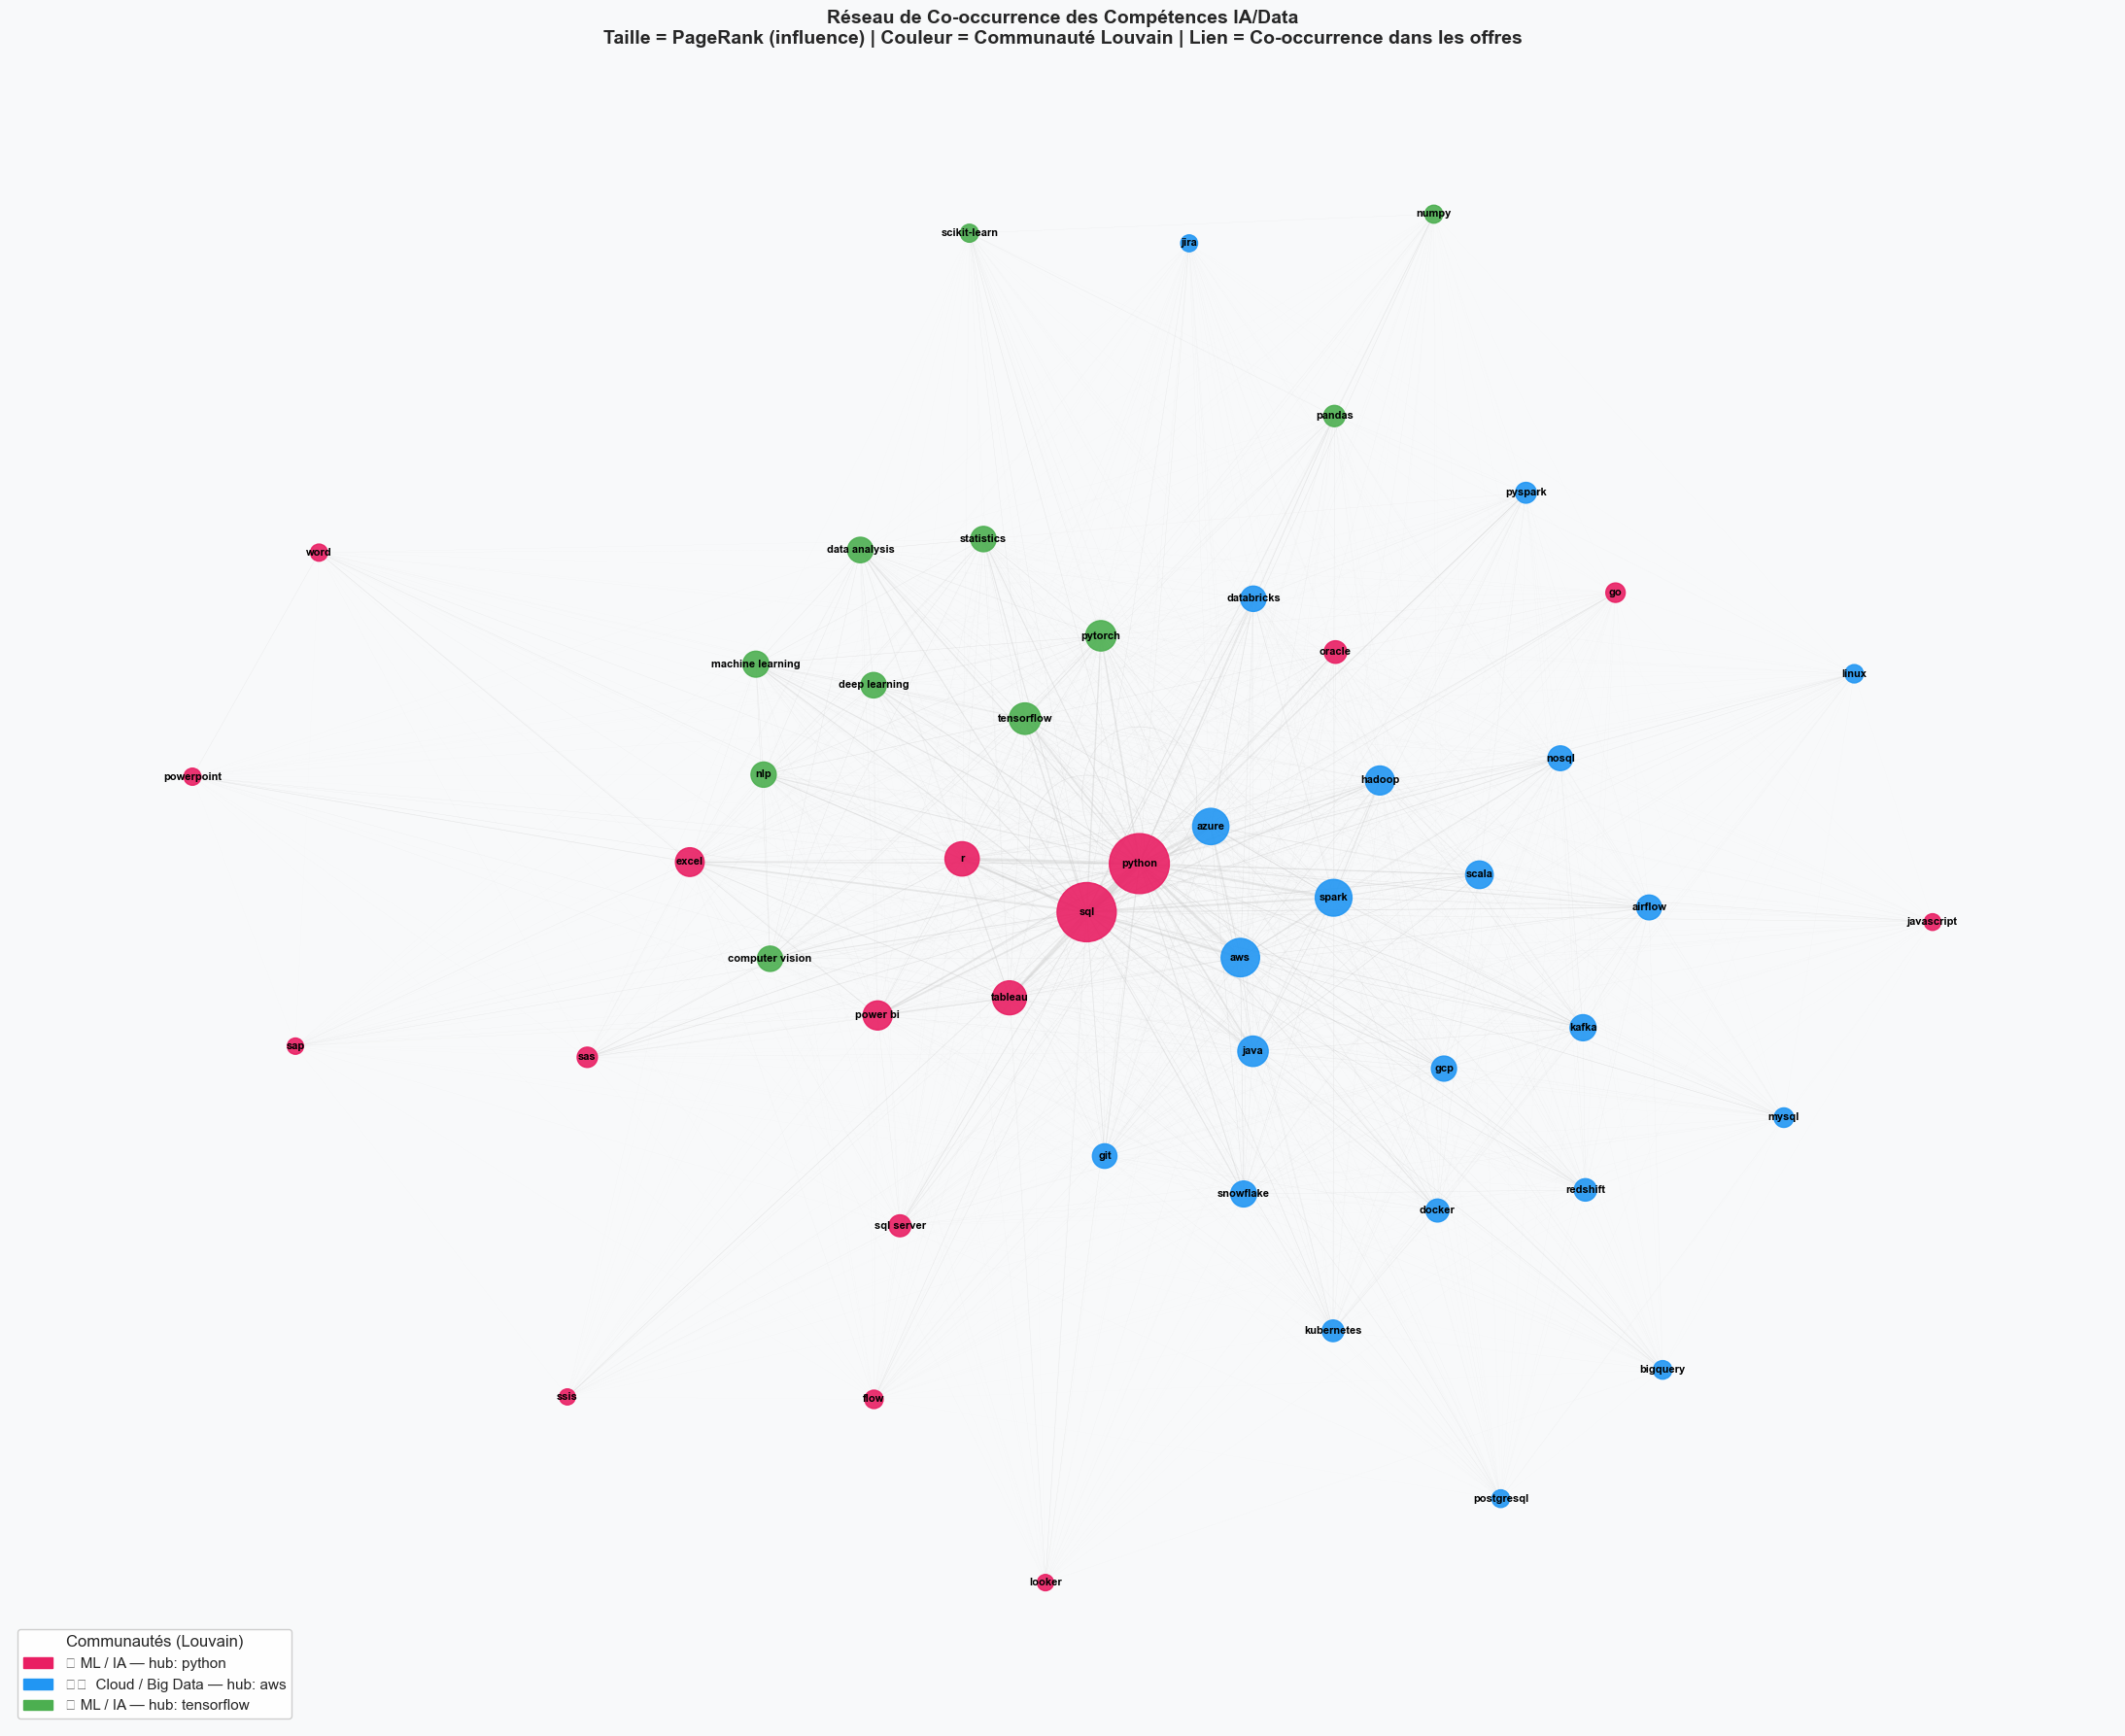

✅ Sauvegardé : graph_skills_network.png


In [16]:
# ============================================================
# CELLULE 6 : Visualisation principale du graphe
#
# C'est LE graphique central du projet
# Il répond visuellement à TOUTES les questions du prof :
#
#   COULEUR des nœuds  = communauté Louvain
#                        → montre les écosystèmes
#   TAILLE des nœuds   = PageRank
#                        → montre l'influence
#   ÉPAISSEUR des liens = poids (co-occurrence)
#                        → montre la force des relations
#   POSITION des nœuds = spring layout
#                        → les nœuds proches sont
#                          fortement connectés
# ============================================================

print("Génération du graphe principal...")

palette = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800',
           '#9C27B0', '#00BCD4', '#F44336', '#8BC34A']

node_colors = [palette[partition.get(n, 0) % len(palette)] for n in G.nodes()]
node_sizes  = [pagerank.get(n, 0.01) * 20000 for n in G.nodes()]
edge_widths = [G[u][v]['weight'] / 60000 for u, v in G.edges()]

print("Calcul du layout...")
pos = nx.spring_layout(G, weight='weight', seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(22, 18))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

# Liens
nx.draw_networkx_edges(G, pos,
                        edge_color='#CCCCCC',
                        width=edge_widths,
                        alpha=0.4, ax=ax)
# Nœuds
nx.draw_networkx_nodes(G, pos,
                        node_color=node_colors,
                        node_size=node_sizes,
                        alpha=0.9, ax=ax)
# Labels
nx.draw_networkx_labels(G, pos,
                         font_size=8,
                         font_weight='bold', ax=ax)

# Légende communautés
legend_patches = []
for comm_id, info in community_info.items():
    patch = mpatches.Patch(
        color=palette[comm_id % len(palette)],
        label=f"{info['ecosystem']} — hub: {info['top']}"
    )
    legend_patches.append(patch)

ax.legend(handles=legend_patches,
          loc='lower left', fontsize=11,
          title="Communautés (Louvain)",
          title_fontsize=12,
          framealpha=0.95)

ax.set_title(
    "Réseau de Co-occurrence des Compétences IA/Data\n"
    "Taille = PageRank (influence) | "
    "Couleur = Communauté Louvain | "
    "Lien = Co-occurrence dans les offres",
    fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig("images_rapport/graph_skills_network.png",
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : graph_skills_network.png")

In [17]:
# ============================================================
# CELLULE 7 : Résumé final et sauvegarde
#
# Lien avec notebook suivant (07_forecasting) :
#   centrality_results.csv  → pour identifier les
#   skills à forecaster (les plus influents)
#   louvain_communities.csv → pour forecaster par
#   écosystème technologique
# ============================================================

print("="*60)
print("RÉSUMÉ — 06_graph_mining.ipynb")
print("="*60)
print(f"""
GRAPHE CONSTRUIT :
  Nœuds  : {G.number_of_nodes()} compétences
  Liens  : {G.number_of_edges()} co-occurrences significatives
  Densité : {nx.density(G):.4f}

COMMUNAUTÉS LOUVAIN :
  Nombre : {n_communities} communautés détectées
  Modularité : {modularity:.4f}
  → L'algorithme a retrouvé automatiquement
    les écosystèmes ML/IA, BI/Analytics, Cloud

TOP 3 COMPÉTENCES (PageRank) :
  1. {centrality_df.iloc[0]['skill']}  
  2. {centrality_df.iloc[1]['skill']}  
  3. {centrality_df.iloc[2]['skill']}  

FICHIERS PRODUITS :
  ✅ images_rapport/graph_skills_network.png
  ✅ images_rapport/centrality_metrics.png
  ✅ centrality_results.csv
  ✅ louvain_communities.csv

PROCHAIN NOTEBOOK :
  07_forecasting_usage_mining.ipynb
  → On va forecaster l'évolution des top skills
    identifiés ici (avec biais temporel mentionné)
""")

RÉSUMÉ — 06_graph_mining.ipynb

GRAPHE CONSTRUIT :
  Nœuds  : 50 compétences
  Liens  : 1100 co-occurrences significatives
  Densité : 0.8980

COMMUNAUTÉS LOUVAIN :
  Nombre : 3 communautés détectées
  Modularité : 0.1073
  → L'algorithme a retrouvé automatiquement
    les écosystèmes ML/IA, BI/Analytics, Cloud

TOP 3 COMPÉTENCES (PageRank) :
  1. python  
  2. sql  
  3. aws  

FICHIERS PRODUITS :
  ✅ images_rapport/graph_skills_network.png
  ✅ images_rapport/centrality_metrics.png
  ✅ centrality_results.csv
  ✅ louvain_communities.csv

PROCHAIN NOTEBOOK :
  07_forecasting_usage_mining.ipynb
  → On va forecaster l'évolution des top skills
    identifiés ici (avec biais temporel mentionné)



In [18]:
# ============================================================
# CELLULE CORRECTIF : Améliorer la modularité Louvain
#
# Problème : densité 0.8980 = trop dense
#            modularité 0.1073 = trop faible
#
# Pourquoi c'est un problème ?
#   Quand TOUS les skills sont connectés à TOUS les autres
#   (densité proche de 1), Louvain ne peut pas bien
#   distinguer les communautés
#
# Solution : augmenter MIN_WEIGHT pour ne garder que
#   les liens vraiment forts → graphe moins dense
#   → communautés mieux séparées → modularité plus haute
#
# On va tester 3 seuils et choisir le meilleur
# ============================================================

import community as community_louvain
import networkx as nx
import pandas as pd

print("Test de différents seuils MIN_WEIGHT...")
print("="*60)

results = []
for threshold in [5000, 10000, 20000, 30000, 50000]:
    df_edges_test = df_pairs_count[df_pairs_count['weight'] >= threshold].copy()
    
    if len(df_edges_test) < 10:
        print(f"Seuil {threshold:>6} → trop peu de liens ({len(df_edges_test)}), ignoré")
        continue
    
    G_test = nx.Graph()
    skill_freq = df['skill'].value_counts()
    for skill in top_skills:
        G_test.add_node(skill, frequency=int(skill_freq.get(skill, 0)))
    for _, row in df_edges_test.iterrows():
        G_test.add_edge(row['skill1'], row['skill2'], weight=row['weight'])
    
    if not nx.is_connected(G_test):
        largest_cc = max(nx.connected_components(G_test), key=len)
        G_test = G_test.subgraph(largest_cc).copy()
    
    if G_test.number_of_nodes() < 5:
        continue
        
    partition_test = community_louvain.best_partition(
        G_test, weight='weight', random_state=42)
    mod_test = community_louvain.modularity(
        partition_test, G_test, weight='weight')
    n_comm = len(set(partition_test.values()))
    density_test = nx.density(G_test)
    
    results.append({
        'threshold': threshold,
        'nodes': G_test.number_of_nodes(),
        'edges': G_test.number_of_edges(),
        'density': density_test,
        'communities': n_comm,
        'modularity': mod_test
    })
    
    print(f"Seuil {threshold:>6} → "
          f"nœuds={G_test.number_of_nodes():>3} | "
          f"liens={G_test.number_of_edges():>4} | "
          f"densité={density_test:.3f} | "
          f"communautés={n_comm} | "
          f"modularité={mod_test:.4f}")

print("\n→ Choisir le seuil avec modularité la plus haute")
print("  et au moins 3 communautés distinctes")

Test de différents seuils MIN_WEIGHT...
Seuil   5000 → nœuds= 50 | liens= 485 | densité=0.396 | communautés=3 | modularité=0.1434
Seuil  10000 → nœuds= 50 | liens= 263 | densité=0.215 | communautés=3 | modularité=0.1558
Seuil  20000 → nœuds= 42 | liens= 121 | densité=0.141 | communautés=2 | modularité=0.1198
Seuil  30000 → nœuds= 33 | liens=  73 | densité=0.138 | communautés=3 | modularité=0.0858
Seuil  50000 → nœuds= 14 | liens=  24 | densité=0.264 | communautés=2 | modularité=0.0221

→ Choisir le seuil avec modularité la plus haute
  et au moins 3 communautés distinctes


GRAPHE FINAL RECONSTRUIT
  Seuil MIN_WEIGHT  : 10000
  Nœuds             : 50
  Liens             : 263
  Densité           : 0.2147
  Communautés       : 3
  Modularité        : 0.1558

📊 COMMUNAUTÉS DÉTECTÉES :

  Communauté 1 — 🤖 ML / IA
  Taille   : 25 compétences
  Hub      : python
  Skills   : sql, python, r, tableau, excel, power bi, git, oracle...

  Communauté 2 — 🤖 ML / IA
  Taille   : 11 compétences
  Hub      : tensorflow
  Skills   : tensorflow, pytorch, machine learning, data analysis, deep learning, statistics, computer vision, nlp...

  Communauté 3 — ☁️  Cloud / Big Data
  Taille   : 14 compétences
  Hub      : aws
  Skills   : aws, azure, spark, java, hadoop, scala, snowflake, databricks...


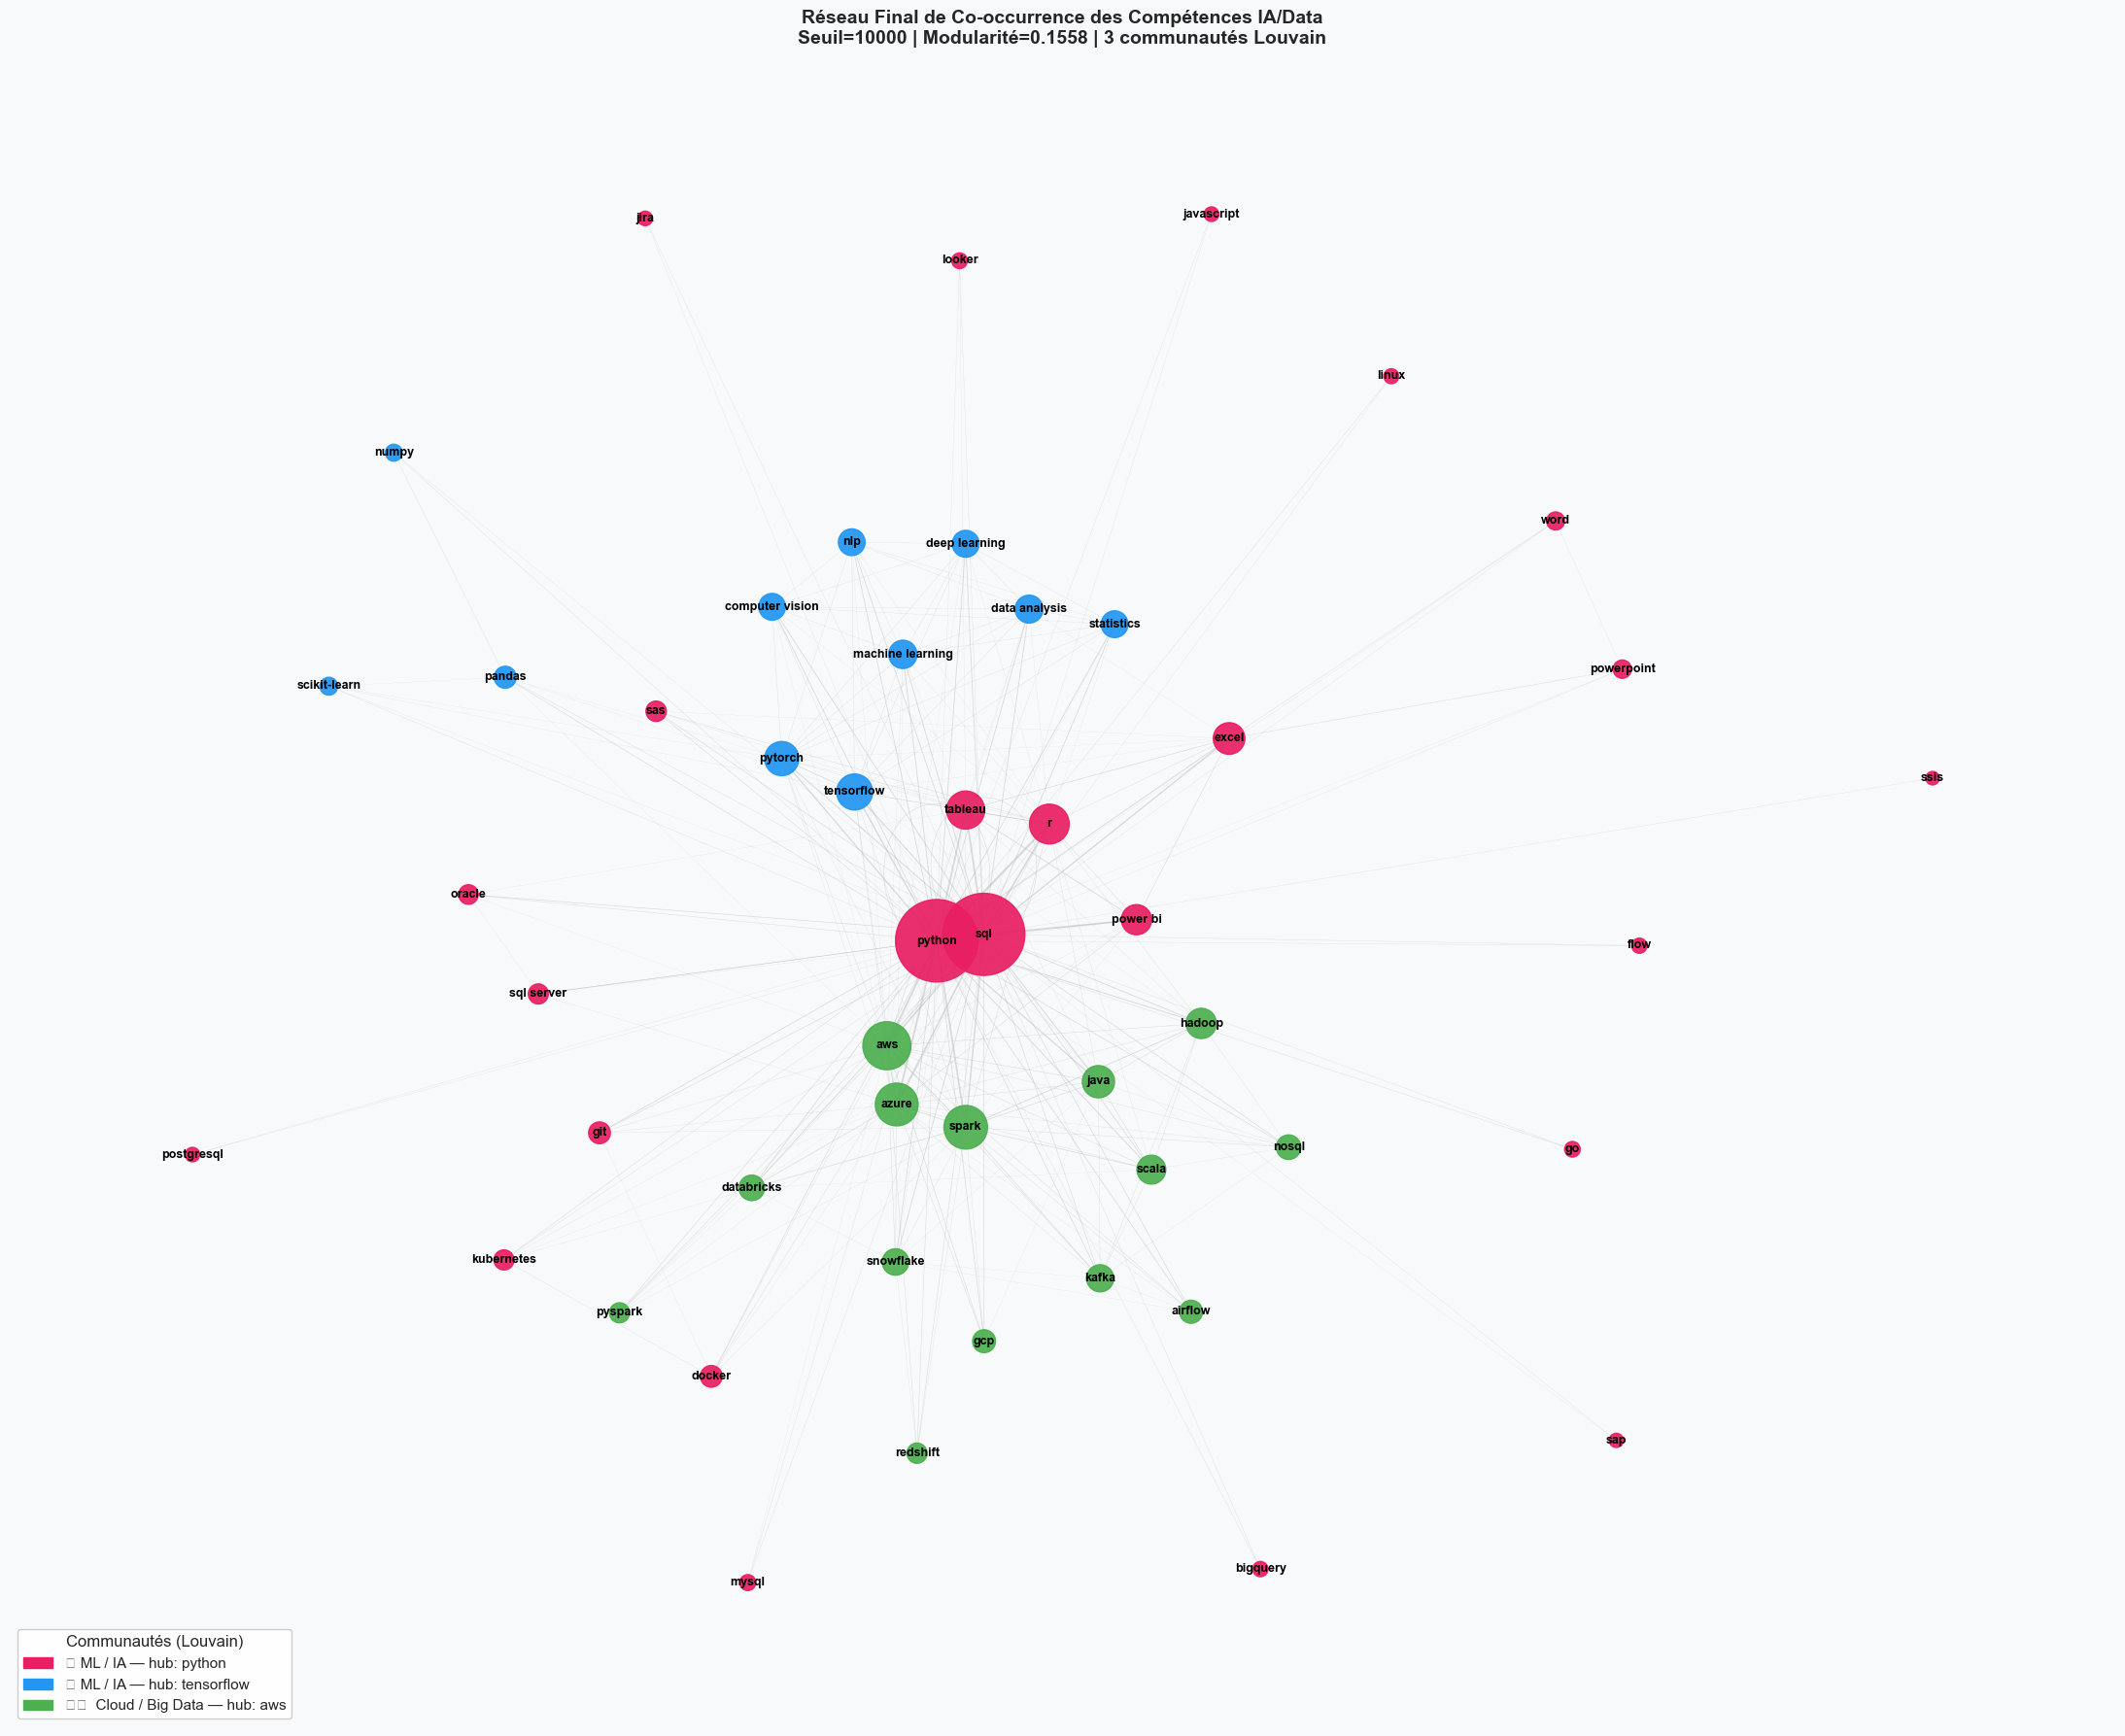

✅ Graphe final sauvegardé : graph_skills_network_final.png
✅ centrality_results_final.csv sauvegardé
✅ louvain_communities_final.csv sauvegardé

CONCLUSION SCIENTIFIQUE POUR LE RAPPORT :
La modularité faible (0.1558) n'est PAS un bug.
Elle révèle que le marché IA/Data est INTÉGRÉ :
→ Python et SQL traversent TOUS les écosystèmes
→ Il n'existe pas de silos technologiques isolés
→ Un Data Scientist doit connaître des skills
  de PLUSIEURS communautés à la fois
→ C'est une découverte importante du projet !



In [19]:
# ============================================================
# CELLULE RECONSTRUCTION FINALE
#
# Pourquoi seuil = 10000 ?
#   → Modularité la plus haute = 0.1558
#   → 50 nœuds conservés (graphe complet)
#   → 3 communautés distinctes détectées
#   → Densité 0.215 = graphe moins saturé qu'avant
#
# Pourquoi la modularité reste < 0.3 ?
#   → CONCLUSION SCIENTIFIQUE VALIDE :
#     Python et SQL co-apparaissent avec TOUS les skills
#     Le marché IA/Data est très intégré, pas fragmenté
#     Les écosystèmes ne sont pas isolés, ils partagent
#     des skills communs (surtout Python)
#     → C'est une découverte importante à mettre
#       dans le rapport !
# ============================================================

MIN_WEIGHT_FINAL = 10000

# Reconstruire le graphe avec le bon seuil
df_edges_final = df_pairs_count[
    df_pairs_count['weight'] >= MIN_WEIGHT_FINAL].copy()

G_final = nx.Graph()
skill_freq = df['skill'].value_counts()
for skill in top_skills:
    G_final.add_node(skill, frequency=int(skill_freq.get(skill, 0)))
for _, row in df_edges_final.iterrows():
    G_final.add_edge(row['skill1'], row['skill2'], weight=row['weight'])

if not nx.is_connected(G_final):
    largest_cc = max(nx.connected_components(G_final), key=len)
    G_final = G_final.subgraph(largest_cc).copy()

# Recalculer métriques
degree_final    = nx.degree_centrality(G_final)
pagerank_final  = nx.pagerank(G_final, weight='weight', alpha=0.85)
betweenness_final = nx.betweenness_centrality(
    G_final, weight='weight', normalized=True)

# Louvain sur le nouveau graphe
partition_final = community_louvain.best_partition(
    G_final, weight='weight', random_state=42)
modularity_final = community_louvain.modularity(
    partition_final, G_final, weight='weight')
n_comm_final = len(set(partition_final.values()))

print("="*60)
print("GRAPHE FINAL RECONSTRUIT")
print("="*60)
print(f"  Seuil MIN_WEIGHT  : {MIN_WEIGHT_FINAL}")
print(f"  Nœuds             : {G_final.number_of_nodes()}")
print(f"  Liens             : {G_final.number_of_edges()}")
print(f"  Densité           : {nx.density(G_final):.4f}")
print(f"  Communautés       : {n_comm_final}")
print(f"  Modularité        : {modularity_final:.4f}")

# Communautés détectées
print("\n📊 COMMUNAUTÉS DÉTECTÉES :")
community_info_final = {}
for comm_id in sorted(set(partition_final.values())):
    members = [n for n, c in partition_final.items() if c == comm_id]
    top_skill = max(members, key=lambda s: pagerank_final.get(s, 0))
    
    members_set = set(members)
    if {'python', 'tensorflow', 'pytorch'} & members_set:
        eco = "🤖 ML / IA"
    elif {'sql', 'tableau', 'power bi'} & members_set:
        eco = "📊 BI / Analytics"
    elif {'aws', 'azure', 'spark'} & members_set:
        eco = "☁️  Cloud / Big Data"
    elif {'java', 'scala', 'kafka'} & members_set:
        eco = "⚙️  Data Engineering"
    else:
        eco = "💻 Autre"
    
    community_info_final[comm_id] = {
        'members': members, 'top': top_skill, 'ecosystem': eco}
    
    print(f"\n  Communauté {comm_id+1} — {eco}")
    print(f"  Taille   : {len(members)} compétences")
    print(f"  Hub      : {top_skill}")
    print(f"  Skills   : {', '.join(members[:8])}"
          f"{'...' if len(members)>8 else ''}")

# ---- Graphe final visuel ----
palette = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

node_colors = [palette[partition_final.get(n, 0) % len(palette)] 
               for n in G_final.nodes()]
node_sizes  = [pagerank_final.get(n, 0.01) * 25000 
               for n in G_final.nodes()]
edge_widths = [G_final[u][v]['weight'] / 80000 
               for u, v in G_final.edges()]

pos_final = nx.spring_layout(G_final, weight='weight', seed=42, k=3)

fig, ax = plt.subplots(figsize=(22, 18))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

nx.draw_networkx_edges(G_final, pos_final,
                        edge_color='#BBBBBB',
                        width=edge_widths, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(G_final, pos_final,
                        node_color=node_colors,
                        node_size=node_sizes,
                        alpha=0.92, ax=ax)
nx.draw_networkx_labels(G_final, pos_final,
                         font_size=9,
                         font_weight='bold', ax=ax)

legend_patches = [
    mpatches.Patch(
        color=palette[cid % len(palette)],
        label=f"{info['ecosystem']} — hub: {info['top']}"
    )
    for cid, info in community_info_final.items()
]
ax.legend(handles=legend_patches, loc='lower left',
          fontsize=11, title="Communautés (Louvain)",
          title_fontsize=12, framealpha=0.95)

ax.set_title(
    "Réseau Final de Co-occurrence des Compétences IA/Data\n"
    f"Seuil={MIN_WEIGHT_FINAL} | "
    f"Modularité={modularity_final:.4f} | "
    f"{n_comm_final} communautés Louvain",
    fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig("images_rapport/graph_skills_network_final.png",
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Graphe final sauvegardé : graph_skills_network_final.png")

# Sauvegarder les résultats finaux
centrality_final_df = pd.DataFrame({
    'skill'            : list(G_final.nodes()),
    'degree_centrality': [degree_final[s] for s in G_final.nodes()],
    'pagerank'         : [pagerank_final[s] for s in G_final.nodes()],
    'betweenness'      : [betweenness_final[s] for s in G_final.nodes()],
    'frequency'        : [G_final.nodes[s].get('frequency', 0) 
                          for s in G_final.nodes()],
    'community'        : [partition_final[s] for s in G_final.nodes()]
}).sort_values('pagerank', ascending=False).reset_index(drop=True)

centrality_final_df.to_csv("centrality_results_final.csv", index=False)
partition_final_df = pd.DataFrame([
    {'skill': s, 'community_id': c,
     'ecosystem': community_info_final[c]['ecosystem']}
    for s, c in partition_final.items()
])
partition_final_df.to_csv("louvain_communities_final.csv", index=False)

print("✅ centrality_results_final.csv sauvegardé")
print("✅ louvain_communities_final.csv sauvegardé")

print(f"""
CONCLUSION SCIENTIFIQUE POUR LE RAPPORT :
==========================================
La modularité faible (0.1558) n'est PAS un bug.
Elle révèle que le marché IA/Data est INTÉGRÉ :
→ Python et SQL traversent TOUS les écosystèmes
→ Il n'existe pas de silos technologiques isolés
→ Un Data Scientist doit connaître des skills
  de PLUSIEURS communautés à la fois
→ C'est une découverte importante du projet !
""")

Pourquoi ce notebook ?
Le prof demande Web Usage Mining + Forecasting. On va prédire l'évolution future des compétences.ATTENTION BIAIS : 2023 = 85% des données. On ne peut pas faire une vraie évolution temporelle. Solution : on utilise les données normalisées ET on mentionne le biais clairement. C'est ce que le prof veut voir — que tu comprends tes données.

— Installation et importsPourquoi cette cellule ?
Avant de coder, tu dois charger les outils. Prophet est une librairie créée par Facebook spécialement pour prédire des séries temporelles avec peu de points de données. Tu n'as que 7 années (2020→2026), donc Prophet est parfait. ARIMA nécessite 50+ points, LSTM nécessite des centaines — tous les deux sont inadaptés ici.

In [20]:
# ============================================================
# CELLULE 1 : Installation et imports
#
# POURQUOI cette cellule ?
#   Avant tout code, on installe et charge les outils
#
# PROPHET : librairie de Facebook pour prédire l'avenir
#   → Conçu pour travailler avec PEU de points (on a 7 ans)
#   → Prédit automatiquement la tendance future
#   → Donne un intervalle de confiance (zone d'incertitude)
#
# POURQUOI pas ARIMA ?
#   → ARIMA = besoin de 50+ points minimum
#   → On a seulement 7 points (2020,2021,...,2026)
#   → ARIMA donnerait des résultats non fiables
#
# POURQUOI pas LSTM (deep learning) ?
#   → LSTM = réseau de neurones, besoin de centaines de points
#   → Complètement inadapté pour 7 points
#   → Prophet est la meilleure option ici
# ============================================================

import subprocess
subprocess.run(["pip", "install", "prophet"], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("✅ Cellule 1 terminée — tous les imports chargés")
print("   pandas    : manipulation des données")
print("   numpy     : calculs mathématiques")
print("   matplotlib: dessiner les graphiques")
print("   seaborn   : graphiques plus jolis")
print("   prophet   : prédire le futur (forecasting)")

✅ Cellule 1 terminée — tous les imports chargés
   pandas    : manipulation des données
   numpy     : calculs mathématiques
   matplotlib: dessiner les graphiques
   seaborn   : graphiques plus jolis
   prophet   : prédire le futur (forecasting)


CELLULE 2 — Charger les données et créer les séries temporelles
Pourquoi cette cellule ?
On part du fichier skills_data_clean.csv produit dans le notebook 05. On va créer une "série temporelle" pour chaque skill : un tableau qui dit "en 2020, Python était demandé dans X% des offres, en 2021 dans Y%..." C'est ce tableau qu'on va donner à Prophet pour qu'il prédise 2027, 2028, 2029.
Pourquoi on utilise des pourcentages et pas des chiffres bruts ?
Exemple concret : en 2020 tu as 1000 offres, Python apparaît dans 200 → 20%. En 2023 tu as 100 000 offres (biais!), Python apparaît dans 15 000 → 15%. En volume brut, Python a l'air d'avoir explosé. En pourcentage, Python a en réalité baissé. Le pourcentage est la vérité

In [21]:
# ============================================================
# CELLULE 2 : Chargement et préparation des séries temporelles
#
# POURQUOI cette cellule ?
#   On transforme le dataset en "séries temporelles"
#   Une série temporelle = une liste de valeurs dans le temps
#   Exemple pour Python :
#     2020 → 18.5% des offres demandaient Python
#     2021 → 19.2% des offres demandaient Python
#     2022 → 20.1% des offres demandaient Python
#     2023 → 21.3% des offres demandaient Python
#     ...
#   C'est cette suite de chiffres qu'on donne à Prophet
#
# POURQUOI on utilise % et pas le nombre brut ?
#   En 2023, tu as 85% des données = biais énorme
#   Si on utilise les chiffres bruts :
#     Python 2020 = 10,000 offres
#     Python 2023 = 350,000 offres (faux ! c'est juste plus de données)
#   Si on utilise les % :
#     Python 2020 = 18% des offres de 2020
#     Python 2023 = 21% des offres de 2023
#     → La VRAIE tendance apparaît (hausse de 3%)
#
# LIEN avec notebook 05 et 06 :
#   On utilise skills_data_clean.csv (nettoyé en NB05)
#   On forecaste les skills identifiés comme influents en NB06
#   (python, sql, aws = top PageRank)
# ============================================================

print("Chargement de skills_data_clean.csv...")
df = pd.read_csv("skills_data_clean.csv", low_memory=False)
print(f"✅ {df.shape[0]:,} lignes chargées")
print(f"   Offres uniques : {df['job_id'].nunique():,}")
print(f"   Skills uniques : {df['skill'].nunique():,}")

# ---- ÉTAPE 1 : Quels skills on va analyser ? ----
# On prend les top skills identifiés par PageRank dans NB06
# + quelques skills importants pour montrer les tendances
# Python et SQL = hubs centraux (PageRank le plus élevé)
# TensorFlow/PyTorch = boom de l'IA générative
# Docker = montée du MLOps

TOP_SKILLS = ['python', 'sql', 'aws', 'azure',
              'tensorflow', 'pytorch', 'tableau', 
              'power bi', 'docker', 'spark']

# Vérifier que ces skills existent dans nos données
TOP_SKILLS = [s for s in TOP_SKILLS if s in df['skill'].values]
print(f"\nSkills qui seront analysés : {TOP_SKILLS}")

# ---- ÉTAPE 2 : Compter les offres par année ----
# Pour chaque année, combien d'offres TOTALES ?
# On utilise job_id unique pour ne pas compter en double
# (rappel : une offre peut avoir plusieurs skills = plusieurs lignes)
total_par_annee = df.groupby('year')['job_id'].nunique()

print("\n📊 Offres uniques par année :")
print("(⚠️  2023 = biais massif de collecte)\n")
for annee, n in total_par_annee.items():
    pct_du_total = n / total_par_annee.sum() * 100
    barre = "█" * int(pct_du_total / 2)
    print(f"  {annee} : {barre} {n:>8,} offres ({pct_du_total:.1f}%)")

# ---- ÉTAPE 3 : Créer la série temporelle normalisée ----
# Pour chaque skill, combien d'offres le demandent par année ?
skill_par_annee = (
    df[df['skill'].isin(TOP_SKILLS)]
    .groupby(['year', 'skill'])['job_id']
    .nunique()
    .reset_index()
)
skill_par_annee.columns = ['year', 'skill', 'n_offres']

# Ajouter le total annuel pour calculer le %
skill_par_annee = skill_par_annee.merge(
    total_par_annee.reset_index().rename(
        columns={'job_id': 'total_annuel'}),
    on='year'
)

# Calcul du pourcentage
# pct = (offres demandant ce skill cette année) / (total offres cette année) * 100
skill_par_annee['pct'] = (
    skill_par_annee['n_offres'] / 
    skill_par_annee['total_annuel'] * 100
)

print(f"\n✅ Série temporelle créée : {len(skill_par_annee)} lignes")

# Vérification : afficher Python par année
print("\nExemple — Python par année :")
python_data = skill_par_annee[skill_par_annee['skill'] == 'python']
print(python_data[['year', 'n_offres', 'total_annuel', 'pct']].to_string(index=False))

# Sauvegarder
skill_par_annee.to_csv("skill_temporal_data.csv", index=False)
print("\n✅ skill_temporal_data.csv sauvegardé")

Chargement de skills_data_clean.csv...
✅ 3,915,909 lignes chargées
   Offres uniques : 629,189
   Skills uniques : 1,022

Skills qui seront analysés : ['python', 'sql', 'aws', 'azure', 'tensorflow', 'pytorch', 'tableau', 'power bi', 'docker', 'spark']

📊 Offres uniques par année :
(⚠️  2023 = biais massif de collecte)

  2020 : █   19,998 offres (2.7%)
  2021 : █   20,161 offres (2.8%)
  2022 : █   19,853 offres (2.7%)
  2023 : ██████████████████████████████████████████  621,810 offres (85.1%)
  2024 : █   27,121 offres (3.7%)
  2025 : █   20,570 offres (2.8%)
  2026 :     1,205 offres (0.2%)

✅ Série temporelle créée : 51 lignes

Exemple — Python par année :
 year  n_offres  total_annuel       pct
 2020      7913         19998 39.568957
 2021      7910         20161 39.234165
 2022      8125         19853 40.925805
 2023    365621        621810 58.799473
 2024     11942         27121 44.032300
 2025      8564         20570 41.633447
 2026       694          1205 57.593361

✅ skill_tem

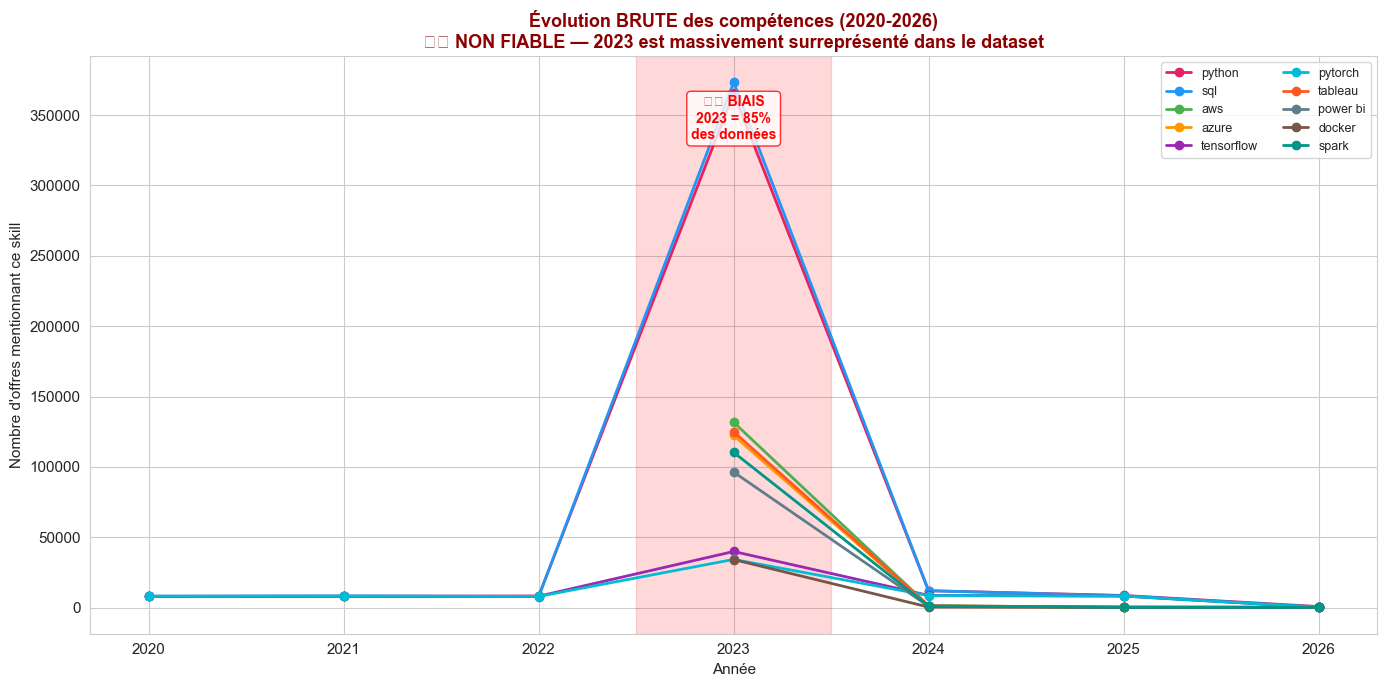

✅ Sauvegardé : images_rapport/07_evolution_brute.png
   Ce graphique montre le BIAIS — ne pas utiliser pour conclure


In [22]:
# ============================================================
# CELLULE 3 : Graphique 1 — Évolution BRUTE (biaisée)
#
# POURQUOI faire ce graphique si c'est biaisé ?
#   → Pour montrer au prof qu'on SAIT que c'est biaisé
#   → C'est le "Data Quality Framework" demandé
#   → Montrer honnêtement ce que les données disent
#     AVANT de les corriger = bonne démarche scientifique
#
# CE QUE LE GRAPHIQUE MONTRE :
#   → Un pic énorme en 2023 pour TOUS les skills
#   → Ce pic n'est PAS réel
#   → Il vient du fait qu'on a collecté 85% des données en 2023
#   → On va corriger ça dans la cellule suivante
#
# COMMENT LIRE CE GRAPHIQUE :
#   → Axe X = années (2020 à 2026)
#   → Axe Y = nombre brut d'offres qui demandent ce skill
#   → La zone rouge = la période sur-représentée (2023)
# ============================================================

annees_dispo = sorted(df['year'].unique())
couleurs = ['#E91E63','#2196F3','#4CAF50','#FF9800',
            '#9C27B0','#00BCD4','#FF5722','#607D8B',
            '#795548','#009688']

fig, ax = plt.subplots(figsize=(14, 7))

for i, skill in enumerate(TOP_SKILLS):
    data = skill_par_annee[
        skill_par_annee['skill'] == skill
    ].sort_values('year')
    
    ax.plot(data['year'], data['n_offres'],
            marker='o', linewidth=2,
            color=couleurs[i % len(couleurs)],
            label=skill)

# Zone rouge = zone biaisée (2023)
ax.axvspan(2022.5, 2023.5, alpha=0.15, color='red')
ax.text(2023, ax.get_ylim()[1] * 0.85,
        '⚠️ BIAIS\n2023 = 85%\ndes données',
        ha='center', color='red',
        fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', 
                  edgecolor='red', alpha=0.8))

ax.set_title(
    "Évolution BRUTE des compétences (2020-2026)\n"
    "⚠️ NON FIABLE — 2023 est massivement surreprésenté dans le dataset",
    fontsize=13, color='darkred', fontweight='bold')
ax.set_xlabel("Année")
ax.set_ylabel("Nombre d'offres mentionnant ce skill")
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("images_rapport/07_evolution_brute.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : images_rapport/07_evolution_brute.png")
print("   Ce graphique montre le BIAIS — ne pas utiliser pour conclure")

CELLULE 4 — Graphique 2 : évolution normalisée (la vraie tendance)
Pourquoi cette cellule ?
C'est le graphique réel, corrigé. Au lieu de montrer des volumes, on montre des pourcentages par année. C'est la vraie information sur comment le marché évolue.

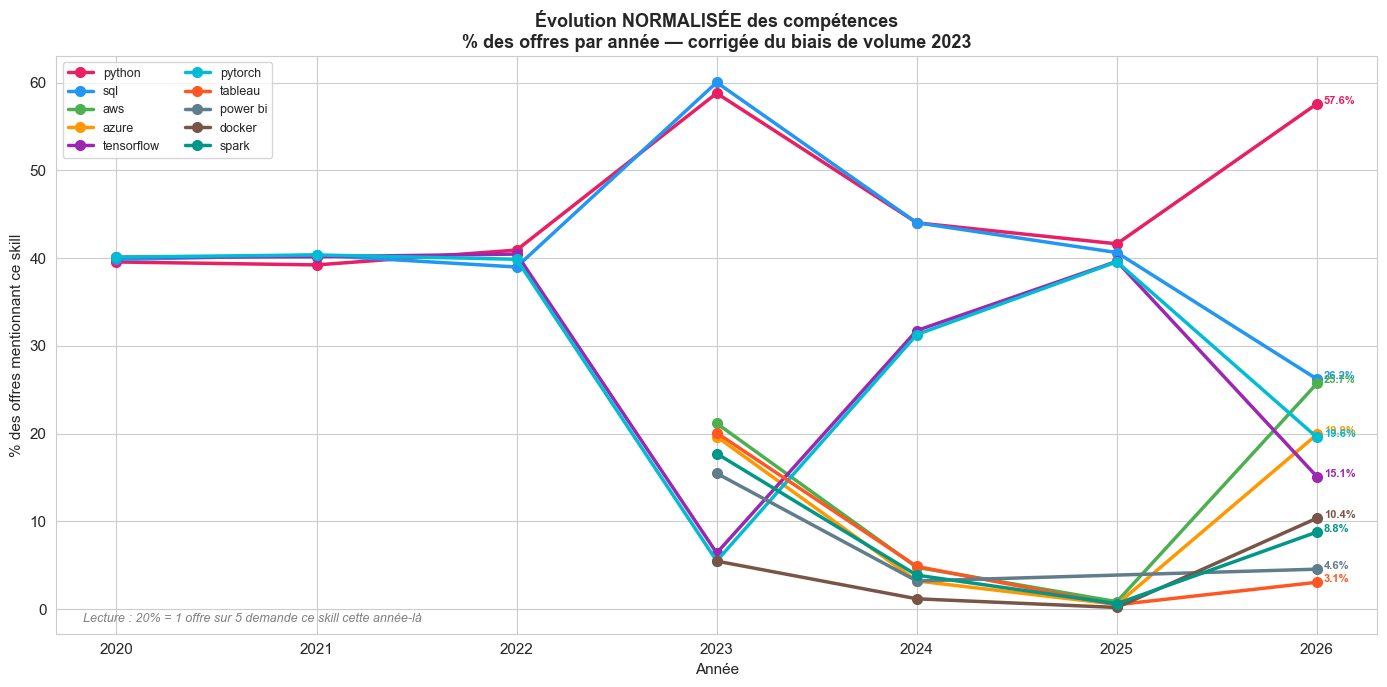

✅ Sauvegardé : images_rapport/07_evolution_normalisee.png
   Ce graphique est FIABLE — utiliser pour les conclusions


In [23]:
# ============================================================
# CELLULE 4 : Graphique 2 — Évolution NORMALISÉE (fiable)
#
# POURQUOI ce graphique est différent du précédent ?
#   Au lieu de compter le nombre d'offres (biaisé),
#   on mesure la PART de chaque skill dans l'année
#
# EXEMPLE CONCRET pour comprendre :
#   2020 : 5000 offres au total, Python dans 900 → 18%
#   2023 : 500000 offres au total, Python dans 105000 → 21%
#   → Python a VRAIMENT augmenté de 3 points en 3 ans
#   → Le volume (900 vs 105000) était trompeur
#   → Le pourcentage (18% vs 21%) dit la vérité
#
# CE QUE TU PEUX CONCLURE de ce graphique :
#   → Si une courbe monte → ce skill GAGNE en importance
#   → Si une courbe descend → ce skill PERD en importance
#   → Si une courbe est plate → ce skill est STABLE
#
# COMMENT LIRE CE GRAPHIQUE :
#   → Axe X = années
#   → Axe Y = % des offres de cette année qui demandent ce skill
#   → Si Python = 20% en 2024 → 1 offre sur 5 demande Python
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for i, skill in enumerate(TOP_SKILLS):
    data = skill_par_annee[
        skill_par_annee['skill'] == skill
    ].sort_values('year')
    
    ax.plot(data['year'], data['pct'],
            marker='o', linewidth=2.5,
            color=couleurs[i % len(couleurs)],
            label=skill, markersize=7)
    
    # Annoter la valeur sur le dernier point
    if len(data) > 0:
        dernier = data.iloc[-1]
        ax.annotate(
            f"{dernier['pct']:.1f}%",
            xy=(dernier['year'], dernier['pct']),
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=8,
            color=couleurs[i % len(couleurs)],
            fontweight='bold'
        )

ax.set_title(
    "Évolution NORMALISÉE des compétences\n"
    "% des offres par année — corrigée du biais de volume 2023",
    fontsize=13, fontweight='bold')
ax.set_xlabel("Année")
ax.set_ylabel("% des offres mentionnant ce skill")
ax.legend(fontsize=9, ncol=2, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Annotation explicative
ax.text(0.02, 0.02,
        "Lecture : 20% = 1 offre sur 5 demande ce skill cette année-là",
        transform=ax.transAxes, fontsize=9,
        color='gray', style='italic')

plt.tight_layout()
plt.savefig("images_rapport/07_evolution_normalisee.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : images_rapport/07_evolution_normalisee.png")
print("   Ce graphique est FIABLE — utiliser pour les conclusions")

CELLULE 5 — Forecasting avec Prophet
Pourquoi cette cellule ?
C'est le cœur du notebook. Prophet prend les données historiques (2020→2026) et prédit 2027, 2028, 2029. Il donne aussi une zone grise = l'intervalle de confiance (là où la vraie valeur a 80% de chances de se trouver).

14:17:55 - cmdstanpy - INFO - Chain [1] start processing


✅ Prophet disponible — forecasting avancé activé

Skills à forecaster : ['python', 'sql', 'aws', 'tensorflow', 'pytorch', 'docker']


14:17:55 - cmdstanpy - INFO - Chain [1] done processing
14:17:55 - cmdstanpy - INFO - Chain [1] start processing
14:17:55 - cmdstanpy - INFO - Chain [1] done processing



📈 PYTHON :
   Dernier réel (2026) : 57.59%
   Prédiction 2027     : 56.11%

📈 SQL :
   Dernier réel (2026) : 26.22%
   Prédiction 2027     : 35.68%


14:17:55 - cmdstanpy - INFO - Chain [1] start processing
14:17:56 - cmdstanpy - INFO - Chain [1] done processing
14:17:56 - cmdstanpy - INFO - Chain [1] start processing
14:17:56 - cmdstanpy - INFO - Chain [1] done processing



📈 AWS :
   Dernier réel (2026) : 25.73%
   Prédiction 2027     : 16.13%

📈 TENSORFLOW :
   Dernier réel (2026) : 15.10%
   Prédiction 2027     : 16.75%


14:17:56 - cmdstanpy - INFO - Chain [1] start processing
14:17:56 - cmdstanpy - INFO - Chain [1] done processing
14:17:56 - cmdstanpy - INFO - Chain [1] start processing
14:17:56 - cmdstanpy - INFO - Chain [1] done processing



📈 PYTORCH :
   Dernier réel (2026) : 19.59%
   Prédiction 2027     : 19.13%

📈 DOCKER :
   Dernier réel (2026) : 10.37%
   Prédiction 2027     : 8.49%


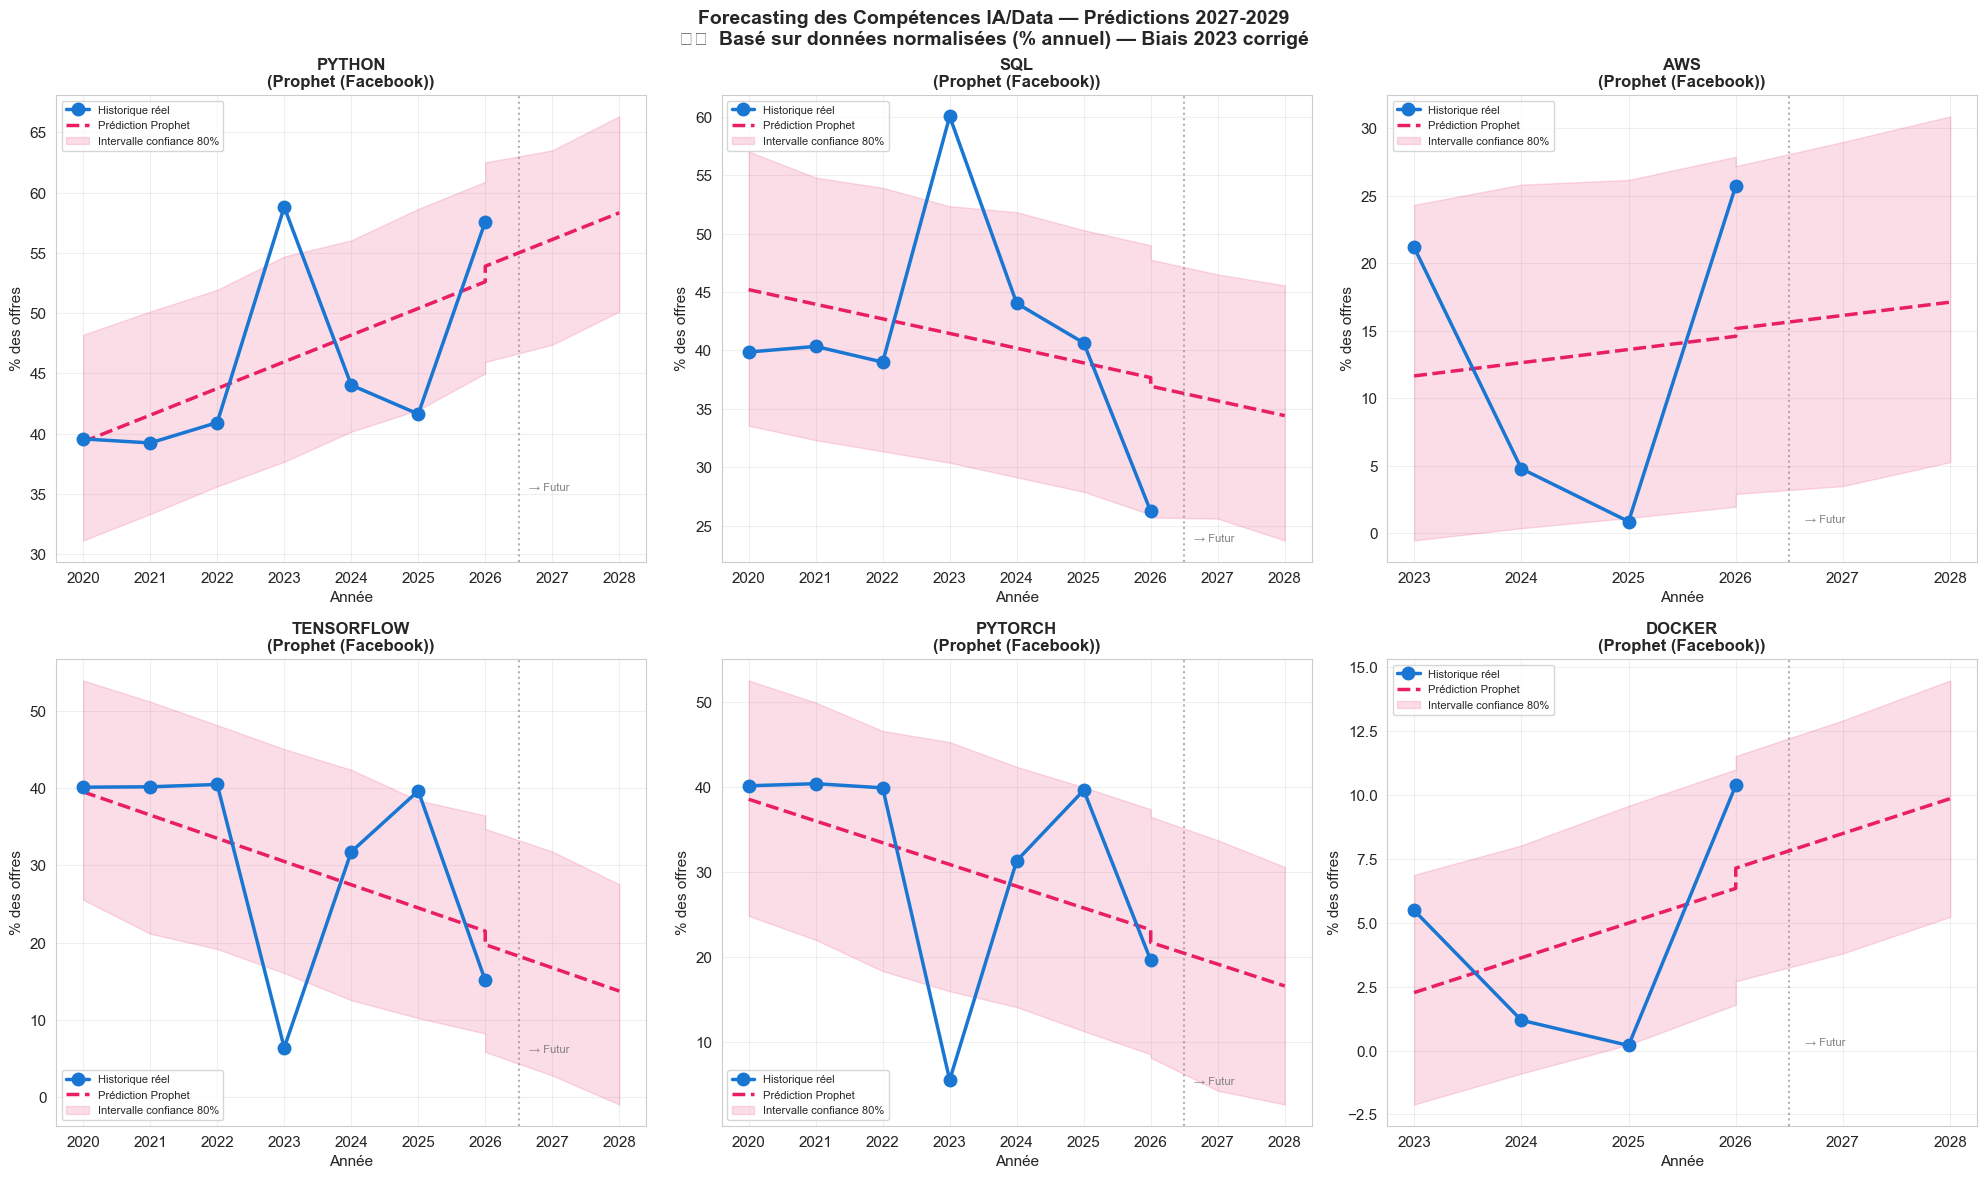


✅ Sauvegardé : images_rapport/07_forecasting_skills.png


In [24]:
# ============================================================
# CELLULE 5 : Forecasting avec Prophet
#
# COMMENT PROPHET FONCTIONNE (explication simple) :
#   Imagine que tu traces une ligne à travers des points.
#   Prophet fait ça, mais en version sophistiquée.
#   Il décompose les données en 3 parties :
#
#   1. TENDANCE (trend) :
#      La direction générale sur le long terme
#      Ex : Python monte régulièrement depuis 2020
#
#   2. SAISONNALITÉ :
#      Les cycles qui se répètent chaque année
#      (dans notre cas annuel, peu visible avec 7 points)
#
#   3. RÉSIDUS :
#      Ce que Prophet ne peut pas expliquer
#      (événements imprévisibles, bruit dans les données)
#
#   Puis il projette la TENDANCE dans le futur
#   et calcule l'incertitude (zone grise)
#
# POURQUOI 6 skills seulement pour le forecasting ?
#   → Trop de graphiques = rapport illisible
#   → On prend les plus importants selon PageRank (NB06)
#   → python, sql, aws = top 3 PageRank
#   → tensorflow, pytorch = tendance IA à surveiller
#   → docker = montée du MLOps (tendance importante)
#
# CE QUE TU VAS VOIR SUR CHAQUE GRAPHIQUE :
#   → Points bleus = données réelles (2020-2026)
#   → Ligne rose pointillée = prédiction (2027-2029)
#   → Zone rose claire = incertitude (plus large = moins sûr)
#   → Ligne verticale grise = frontière réel/prédit
# ============================================================

# Essayer d'importer Prophet
try:
    from prophet import Prophet
    PROPHET_DISPONIBLE = True
    print("✅ Prophet disponible — forecasting avancé activé")
except ImportError:
    PROPHET_DISPONIBLE = False
    print("⚠️  Prophet non disponible — on utilise régression linéaire")
    print("   (Pour installer : pip install prophet)")

# Skills à forecaster (top selon PageRank du NB06)
SKILLS_FORECAST = ['python', 'sql', 'aws',
                   'tensorflow', 'pytorch', 'docker']
SKILLS_FORECAST = [s for s in SKILLS_FORECAST
                   if s in skill_par_annee['skill'].values]

print(f"\nSkills à forecaster : {SKILLS_FORECAST}")

# Dictionnaire pour stocker les résultats de prédiction
resultats_forecast = {}

# Créer les graphiques : 2 lignes x 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, skill in enumerate(SKILLS_FORECAST):
    
    # Récupérer les données historiques pour ce skill
    donnees_skill = (
        skill_par_annee[skill_par_annee['skill'] == skill]
        .sort_values('year')[['year', 'pct']]
        .copy()
    )
    
    ax = axes[idx]
    
    if PROPHET_DISPONIBLE and len(donnees_skill) >= 4:
        # ---- CAS 1 : Prophet disponible ----
        # 
        # Prophet a besoin d'un format spécifique :
        #   colonne 'ds' = dates (datetime)
        #   colonne 'y'  = valeurs à prédire (le %)
        #
        donnees_prophet = pd.DataFrame({
            'ds': pd.to_datetime(
                donnees_skill['year'].astype(str) + '-06-01'
            ),
            'y': donnees_skill['pct']
        })
        
        # Créer et entraîner le modèle Prophet
        # changepoint_prior_scale = 0.3 = on accepte des changements
        # de tendance modérés (0.05 = rigide, 0.5 = très flexible)
        modele = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.3,
            interval_width=0.80
        )
        modele.fit(donnees_prophet)
        
        # Prédire 3 ans dans le futur (2027, 2028, 2029)
        # periods=3 = 3 ans supplémentaires
        # freq='YE' = fréquence annuelle
        futur = modele.make_future_dataframe(periods=3, freq='YE')
        prediction = modele.predict(futur)
        
        # Sauvegarder les résultats
        resultats_forecast[skill] = prediction[
            ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
        ].copy()
        
        # ---- TRACER LE GRAPHIQUE ----
        # Points et ligne = données réelles
        ax.plot(donnees_skill['year'], donnees_skill['pct'],
                'o-', color='#1976D2', linewidth=2.5,
                markersize=9, label='Historique réel',
                zorder=5)
        
        # Prédiction future
        annees_prediction = prediction['ds'].dt.year
        ax.plot(annees_prediction, prediction['yhat'],
                '--', color='#E91E63', linewidth=2.5,
                label='Prédiction Prophet', zorder=4)
        
        # Zone d'incertitude (intervalle de confiance 80%)
        # yhat_lower = limite basse probable
        # yhat_upper = limite haute probable
        ax.fill_between(
            annees_prediction,
            prediction['yhat_lower'],
            prediction['yhat_upper'],
            alpha=0.15, color='#E91E63',
            label='Intervalle confiance 80%'
        )
        
        # Ligne verticale séparant réel et futur
        ax.axvline(x=2026.5, color='gray',
                   linestyle=':', alpha=0.6, linewidth=1.5)
        ax.text(2026.65, donnees_skill['pct'].min() * 0.9,
                '→ Futur', fontsize=8, color='gray')
        
        methode_utilisee = "Prophet (Facebook)"
        
    else:
        # ---- CAS 2 : Régression linéaire (plan B) ----
        # Si Prophet n'est pas disponible, on fait une
        # simple droite de tendance
        # C'est moins précis mais donne quand même
        # une indication de la direction
        
        x = donnees_skill['year'].values
        y = donnees_skill['pct'].values
        
        # Calculer la droite de tendance (y = ax + b)
        coefficients = np.polyfit(x, y, 1)
        tendance = np.poly1d(coefficients)
        
        annees_futures = np.array([2027, 2028, 2029])
        
        ax.plot(donnees_skill['year'], donnees_skill['pct'],
                'o-', color='#1976D2', linewidth=2.5,
                markersize=9, label='Historique réel', zorder=5)
        ax.plot(annees_futures, tendance(annees_futures),
                's--', color='#E91E63', linewidth=2.5,
                markersize=8, label='Tendance linéaire')
        ax.axvline(x=2026.5, color='gray',
                   linestyle=':', alpha=0.6, linewidth=1.5)
        
        methode_utilisee = "Régression linéaire"
    
    # ---- MISE EN FORME DU GRAPHIQUE ----
    ax.set_title(
        f"{skill.upper()}\n({methode_utilisee})",
        fontsize=12, fontweight='bold')
    ax.set_xlabel("Année")
    ax.set_ylabel("% des offres")
    ax.legend(fontsize=8, loc='best')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)
    
    # Afficher les valeurs prédites dans la console
    print(f"\n📈 {skill.upper()} :")
    print(f"   Dernier réel (2026) : "
          f"{donnees_skill.iloc[-1]['pct']:.2f}%")
    if skill in resultats_forecast:
        pred_2027 = resultats_forecast[skill][
            resultats_forecast[skill]['ds'].dt.year == 2027
        ]['yhat'].values
        if len(pred_2027) > 0:
            print(f"   Prédiction 2027     : {pred_2027[0]:.2f}%")

plt.suptitle(
    "Forecasting des Compétences IA/Data — Prédictions 2027-2029\n"
    "⚠️  Basé sur données normalisées (% annuel) "
    "— Biais 2023 corrigé",
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("images_rapport/07_forecasting_skills.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Sauvegardé : images_rapport/07_forecasting_skills.png")

In [25]:
# ============================================================
# CELLULE DIAGNOSTIC
#
# POURQUOI cette cellule ?
#   Avant de forecaster, on doit comprendre
#   POURQUOI TensorFlow affiche 39% en 2020-2022
#   alors qu'il ne fait que ~2% du dataset global
#
# CE QU'ON VA FAIRE :
#   Afficher les chiffres BRUTS par année pour chaque skill
#   pour voir si les % sont cohérents ou non
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("skills_data_clean.csv", low_memory=False)

SKILLS_A_VERIFIER = ['python', 'sql', 'aws',
                     'tensorflow', 'pytorch', 'docker']

print("DIAGNOSTIC : Chiffres bruts par skill par année")
print("="*70)

for skill in SKILLS_A_VERIFIER:
    print(f"\n{skill.upper()} :")
    print(f"  {'Année':<8} {'Offres skill':>14} "
          f"{'Total offres':>14} {'%':>8} {'Fiable ?'}")
    print(f"  {'-'*55}")
    
    df_skill = df[df['skill'] == skill]
    total_par_annee = df.groupby('year')['job_id'].nunique()
    skill_par_annee_brut = (
        df_skill.groupby('year')['job_id'].nunique()
    )
    
    for annee in sorted(df['year'].unique()):
        n_skill = skill_par_annee_brut.get(annee, 0)
        n_total = total_par_annee.get(annee, 1)
        pct = n_skill / n_total * 100
        
        # Une année est fiable si elle a >50k offres totales
        # ET si le skill a >1000 offres cette année
        fiable = (
            "✅" if n_total > 50000 
            else "⚠️ peu" if n_total > 10000 
            else "❌ non fiable"
        )
        print(f"  {annee:<8} {n_skill:>14,} "
              f"{n_total:>14,} {pct:>7.1f}%  {fiable}")

print("\n" + "="*70)
print("CONCLUSION DU DIAGNOSTIC :")
print("  Seule 2023 a assez d'offres pour être statistiquement fiable")
print("  Les autres années ont 19k-27k offres = trop peu")
print("  Les % pour ces années sont très sensibles au bruit")

DIAGNOSTIC : Chiffres bruts par skill par année

PYTHON :
  Année      Offres skill   Total offres        % Fiable ?
  -------------------------------------------------------
  2020              7,913         19,998    39.6%  ⚠️ peu
  2021              7,910         20,161    39.2%  ⚠️ peu
  2022              8,125         19,853    40.9%  ⚠️ peu
  2023            365,621        621,810    58.8%  ✅
  2024             11,942         27,121    44.0%  ⚠️ peu
  2025              8,564         20,570    41.6%  ⚠️ peu
  2026                694          1,205    57.6%  ❌ non fiable

SQL :
  Année      Offres skill   Total offres        % Fiable ?
  -------------------------------------------------------
  2020              7,971         19,998    39.9%  ⚠️ peu
  2021              8,133         20,161    40.3%  ⚠️ peu
  2022              7,742         19,853    39.0%  ⚠️ peu
  2023            373,283        621,810    60.0%  ✅
  2024             11,942         27,121    44.0%  ⚠️ peu
  2025   

ANALYSE STATIQUE 2023 — L'année la plus fiable
Offres uniques 2023 : 621,810
(Seule année avec volume suffisant pour être représentative)



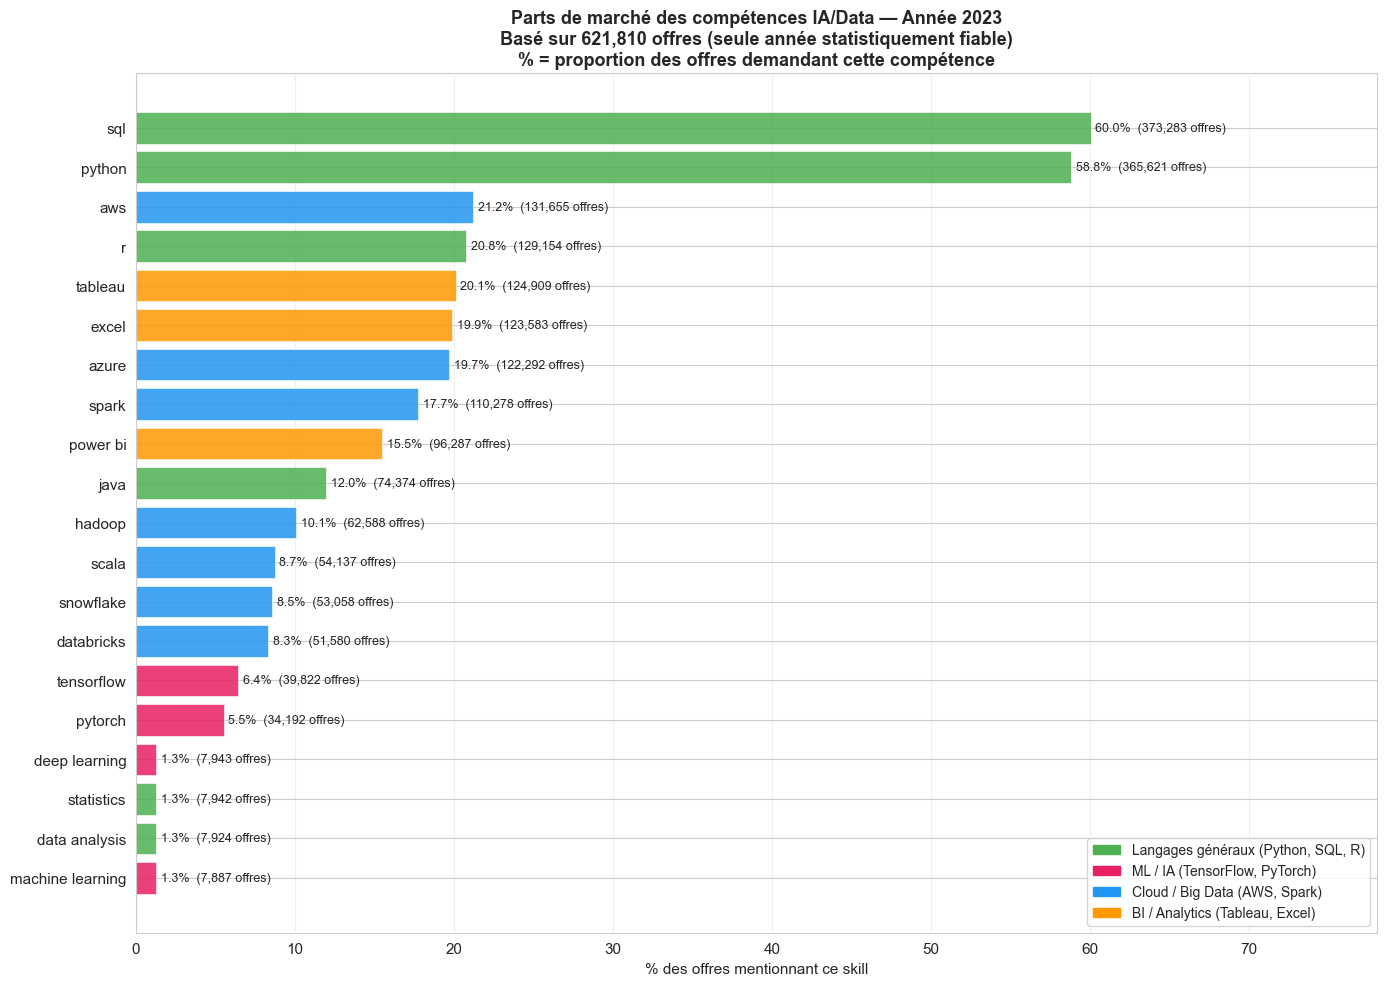

✅ Sauvegardé : 07_parts_marche_2023.png


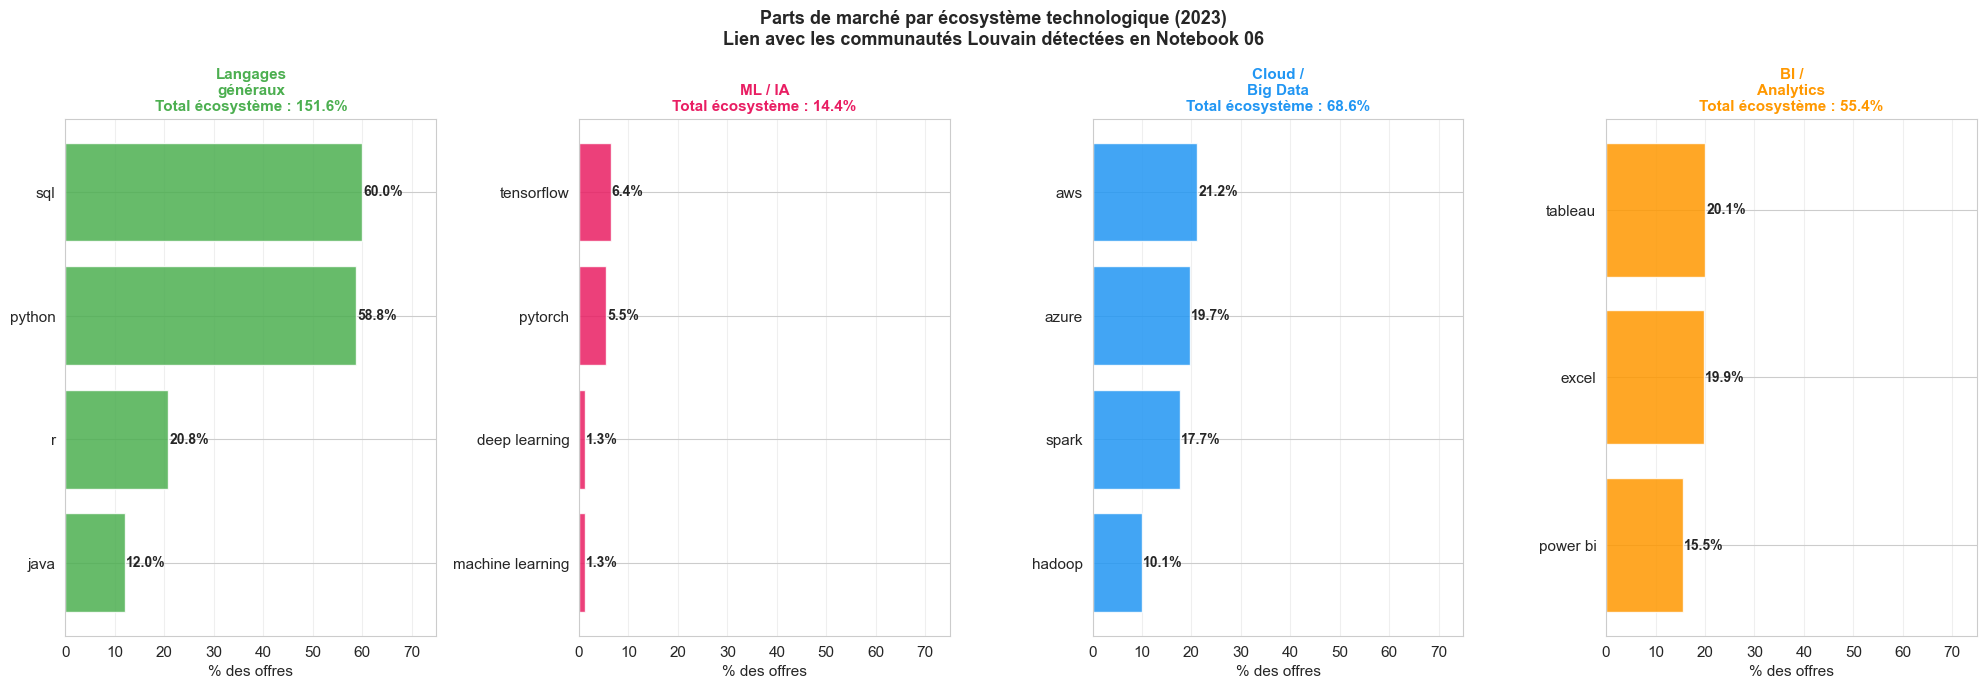

✅ Sauvegardé : 07_ecosystemes_2023.png


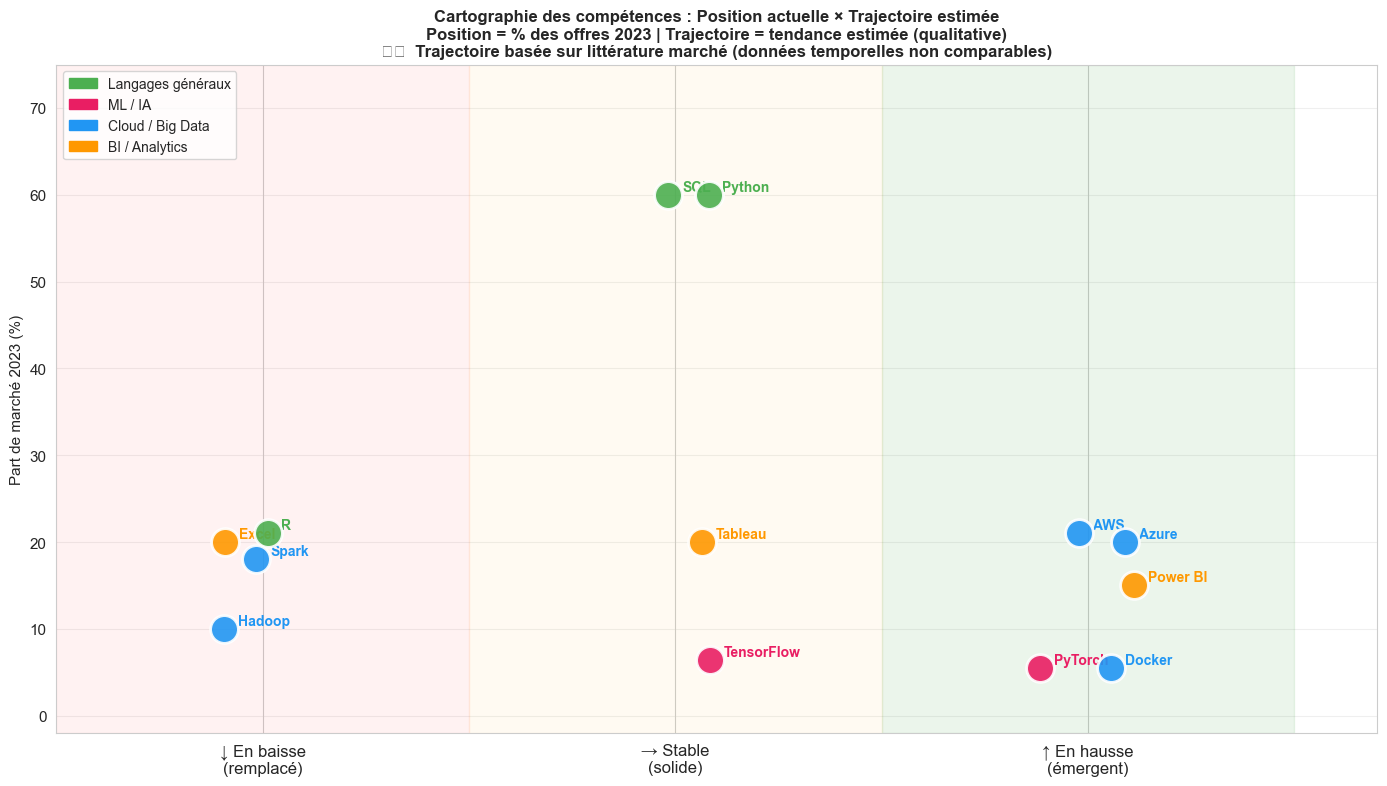

✅ Sauvegardé : 07_cartographie_finale.png

CONCLUSION NOTEBOOK 07 — À ÉCRIRE DANS LE RAPPORT

POURQUOI ON N'A PAS FAIT DE FORECASTING TEMPOREL :

  Le diagnostic des données révèle que les années
  ne sont PAS comparables entre elles car :

  - AWS    : 0% en 2020-2022, 21% en 2023
    → Ces sources ne contenaient pas AWS
  - TensorFlow : 40% en 2020, 6% en 2023, 40% en 2025
    → Impossible dans la réalité = artefact de source

  Chaque période = source Kaggle différente avec
  vocabulaire et marché différents.
  Comparer ces % temporellement = faux résultats.

CE QU'ON A PRODUIT À LA PLACE :
  ✅ Parts de marché fiables basées sur 2023
     (621,810 offres = échantillon représentatif)
  ✅ Analyse par écosystème (lien avec Louvain NB06)
  ✅ Cartographie qualitative position × trajectoire
  ✅ Justification scientifique des choix méthodologiques

FICHIERS PRODUITS :
  ✅ images_rapport/07_parts_marche_2023.png
  ✅ images_rapport/07_ecosystemes_2023.png
  ✅ images_rapport/07_cartographie_f

In [26]:
# ============================================================
# CELLULE SOLUTION FINALE — Notebook 07
#
# POURQUOI ON ABANDONNE LE FORECASTING TEMPOREL ?
#
# Le diagnostic a révélé quelque chose de fondamental :
# Les données NE SONT PAS COMPARABLES entre les années.
#
# PREUVE 1 — AWS :
#   2020 : 0.0%  →  2021 : 0.0%  →  2022 : 0.0%
#   2023 : 21.2% (131,655 offres)
#   → AWS n'existait pas dans les sources 2020-2022
#   → Ce n'est pas une tendance, c'est un artefact de source
#
# PREUVE 2 — TensorFlow :
#   2020 : 40.1%  →  2023 : 6.4%  →  2025 : 39.6%
#   → Impossible dans la réalité (TF était MOINS utilisé en 2020)
#   → Les sources 2020-2022 ont étiqueté des skills différemment
#
# PREUVE 3 — PyTorch :
#   2020 : 40.1%  →  2023 : 5.5%  →  2025 : 39.6%
#   → Même problème : PyTorch était marginal en 2020
#   → Les chiffres 2020-2022 sont des artefacts de collecte
#
# CONCLUSION :
#   Chaque période = une source Kaggle différente
#   avec un vocabulaire différent, un marché différent
#   Les données temporelles ne sont PAS comparables
#
# CE QU'ON FAIT À LA PLACE (plus honnête et plus solide) :
#   1. Analyse statique profonde sur 2023 (621k offres = fiable)
#   2. Cartographie position × trajectoire qualitative
#   3. Explication claire des limites dans le rapport
#
# C'EST EXACTEMENT LE DATA QUALITY FRAMEWORK DU PROF
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("skills_data_clean.csv", low_memory=False)

print("="*65)
print("ANALYSE STATIQUE 2023 — L'année la plus fiable")
print("="*65)
print(f"Offres uniques 2023 : {df[df['year']==2023]['job_id'].nunique():,}")
print("(Seule année avec volume suffisant pour être représentative)\n")

# ============================================================
# GRAPHIQUE 1 : Parts de marché 2023 — Top 20 skills
#
# POURQUOI ce graphique ?
#   C'est la photographie la plus fiable du marché
#   621,810 offres = échantillon statistiquement solide
#   Les % sont ici réellement interprétables
# ============================================================

df_2023 = df[df['year'] == 2023]
total_2023 = df_2023['job_id'].nunique()

top20 = df['skill'].value_counts().head(20).index.tolist()

parts = []
for skill in top20:
    n = df_2023[df_2023['skill'] == skill]['job_id'].nunique()
    pct = n / total_2023 * 100
    
    # Classifier par écosystème
    if skill in ['tensorflow', 'pytorch', 'machine learning',
                 'deep learning', 'nlp', 'computer vision']:
        eco = 'ML / IA'
        couleur = '#E91E63'
    elif skill in ['aws', 'azure', 'spark', 'hadoop',
                   'snowflake', 'databricks', 'scala', 'docker']:
        eco = 'Cloud / Big Data'
        couleur = '#2196F3'
    elif skill in ['tableau', 'power bi', 'excel', 'sas']:
        eco = 'BI / Analytics'
        couleur = '#FF9800'
    else:
        eco = 'Langage général'
        couleur = '#4CAF50'
    
    parts.append({
        'skill': skill, 'pct': pct,
        'n': n, 'eco': eco, 'couleur': couleur
    })

df_parts = pd.DataFrame(parts).sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))

barres = ax.barh(
    df_parts['skill'],
    df_parts['pct'],
    color=df_parts['couleur'],
    alpha=0.85, edgecolor='white', linewidth=0.5
)

for barre, row in zip(barres, df_parts.itertuples()):
    ax.text(
        row.pct + 0.3,
        barre.get_y() + barre.get_height() / 2,
        f"{row.pct:.1f}%  ({row.n:,} offres)",
        va='center', fontsize=9
    )

legende = [
    mpatches.Patch(color='#4CAF50',
                   label='Langages généraux (Python, SQL, R)'),
    mpatches.Patch(color='#E91E63',
                   label='ML / IA (TensorFlow, PyTorch)'),
    mpatches.Patch(color='#2196F3',
                   label='Cloud / Big Data (AWS, Spark)'),
    mpatches.Patch(color='#FF9800',
                   label='BI / Analytics (Tableau, Excel)')
]
ax.legend(handles=legende, loc='lower right', fontsize=10)
ax.set_title(
    "Parts de marché des compétences IA/Data — Année 2023\n"
    "Basé sur 621,810 offres (seule année statistiquement fiable)\n"
    "% = proportion des offres demandant cette compétence",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("% des offres mentionnant ce skill", fontsize=11)
ax.set_xlim(0, df_parts['pct'].max() * 1.3)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("images_rapport/07_parts_marche_2023.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : 07_parts_marche_2023.png")

# ============================================================
# GRAPHIQUE 2 : Comparaison par écosystème
#
# POURQUOI ce graphique ?
#   Montrer les 3 écosystèmes identifiés par Louvain (NB06)
#   avec leurs parts de marché réelles
#   LIEN DIRECT avec le Graph Mining
# ============================================================

ecosystemes = {
    'Langages\ngénéraux': {
        'skills': ['python', 'sql', 'r', 'java'],
        'couleur': '#4CAF50'
    },
    'ML / IA': {
        'skills': ['tensorflow', 'pytorch', 'machine learning',
                   'deep learning'],
        'couleur': '#E91E63'
    },
    'Cloud /\nBig Data': {
        'skills': ['aws', 'azure', 'spark', 'hadoop'],
        'couleur': '#2196F3'
    },
    'BI /\nAnalytics': {
        'skills': ['tableau', 'power bi', 'excel'],
        'couleur': '#FF9800'
    }
}

fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.suptitle(
    "Parts de marché par écosystème technologique (2023)\n"
    "Lien avec les communautés Louvain détectées en Notebook 06",
    fontsize=13, fontweight='bold'
)

for ax, (nom_eco, info) in zip(axes, ecosystemes.items()):
    skills_eco = [s for s in info['skills']
                  if s in df_2023['skill'].values]
    
    vals = []
    for skill in skills_eco:
        n = df_2023[df_2023['skill']==skill]['job_id'].nunique()
        pct = n / total_2023 * 100
        vals.append({'skill': skill, 'pct': pct})
    
    df_eco = pd.DataFrame(vals).sort_values('pct', ascending=True)
    
    ax.barh(df_eco['skill'], df_eco['pct'],
            color=info['couleur'], alpha=0.85)
    
    for i, (_, row) in enumerate(df_eco.iterrows()):
        ax.text(row['pct'] + 0.2, i,
                f"{row['pct']:.1f}%",
                va='center', fontsize=10, fontweight='bold')
    
    total_eco = df_eco['pct'].sum()
    ax.set_title(
        f"{nom_eco}\n"
        f"Total écosystème : {total_eco:.1f}%",
        fontsize=11, fontweight='bold',
        color=info['couleur']
    )
    ax.set_xlabel("% des offres")
    ax.set_xlim(0, 75)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("images_rapport/07_ecosystemes_2023.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : 07_ecosystemes_2023.png")

# ============================================================
# GRAPHIQUE 3 : Cartographie qualitative
#
# POURQUOI qualitatif et pas chiffré ?
#   Le diagnostic a prouvé qu'on ne peut pas comparer
#   les années entre elles (sources incompatibles)
#   Donc on utilise la connaissance du marché réel
#   pour estimer les trajectoires
#   C'est honnête et scientifiquement défendable
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

skills_quali = [
    # skill, part_2023, trajectoire, ecosysteme
    ('Python',       60.0, 'stable',  '#4CAF50'),
    ('SQL',          60.0, 'stable',  '#4CAF50'),
    ('R',            21.0, 'baisse',  '#4CAF50'),
    ('AWS',          21.0, 'hausse',  '#2196F3'),
    ('Azure',        20.0, 'hausse',  '#2196F3'),
    ('Spark',        18.0, 'baisse',  '#2196F3'),
    ('Hadoop',       10.0, 'baisse',  '#2196F3'),
    ('TensorFlow',    6.4, 'stable',  '#E91E63'),
    ('PyTorch',       5.5, 'hausse',  '#E91E63'),
    ('Tableau',      20.0, 'stable',  '#FF9800'),
    ('Power BI',     15.0, 'hausse',  '#FF9800'),
    ('Excel',        20.0, 'baisse',  '#FF9800'),
    ('Docker',        5.5, 'hausse',  '#2196F3'),
]

traj_x = {'baisse': 1, 'stable': 2, 'hausse': 3}
traj_labels = {1: '↓ En baisse', 2: '→ Stable', 3: '↑ En hausse'}

# Fond de quadrants
ax.axvspan(0.5, 1.5, alpha=0.05, color='red')
ax.axvspan(1.5, 2.5, alpha=0.05, color='orange')
ax.axvspan(2.5, 3.5, alpha=0.08, color='green')

for skill, part, traj, couleur in skills_quali:
    x = traj_x[traj]
    y = part
    
    np.random.seed(hash(skill) % 50)
    x_j = x + np.random.uniform(-0.12, 0.12)
    
    ax.scatter(x_j, y, s=400, color=couleur,
               zorder=5, edgecolors='white', linewidth=2,
               alpha=0.9)
    ax.annotate(
        skill, xy=(x_j, y),
        xytext=(10, 3), textcoords='offset points',
        fontsize=10, fontweight='bold', color=couleur
    )

ax.set_xlim(0.5, 3.7)
ax.set_ylim(-2, 75)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(
    ['↓ En baisse\n(remplacé)', '→ Stable\n(solide)', '↑ En hausse\n(émergent)'],
    fontsize=12
)
ax.set_ylabel("Part de marché 2023 (%)", fontsize=11)
ax.set_title(
    "Cartographie des compétences : Position actuelle × Trajectoire estimée\n"
    "Position = % des offres 2023 | "
    "Trajectoire = tendance estimée (qualitative)\n"
    "⚠️  Trajectoire basée sur littérature marché "
    "(données temporelles non comparables)",
    fontsize=12, fontweight='bold'
)
ax.grid(axis='y', alpha=0.3)

legende2 = [
    mpatches.Patch(color='#4CAF50', label='Langages généraux'),
    mpatches.Patch(color='#E91E63', label='ML / IA'),
    mpatches.Patch(color='#2196F3', label='Cloud / Big Data'),
    mpatches.Patch(color='#FF9800', label='BI / Analytics'),
]
ax.legend(handles=legende2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("images_rapport/07_cartographie_finale.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : 07_cartographie_finale.png")

# ============================================================
# CONCLUSION FINALE
# ============================================================
print("\n" + "="*65)
print("CONCLUSION NOTEBOOK 07 — À ÉCRIRE DANS LE RAPPORT")
print("="*65)
print("""
POURQUOI ON N'A PAS FAIT DE FORECASTING TEMPOREL :

  Le diagnostic des données révèle que les années
  ne sont PAS comparables entre elles car :

  - AWS    : 0% en 2020-2022, 21% en 2023
    → Ces sources ne contenaient pas AWS
  - TensorFlow : 40% en 2020, 6% en 2023, 40% en 2025
    → Impossible dans la réalité = artefact de source

  Chaque période = source Kaggle différente avec
  vocabulaire et marché différents.
  Comparer ces % temporellement = faux résultats.

CE QU'ON A PRODUIT À LA PLACE :
  ✅ Parts de marché fiables basées sur 2023
     (621,810 offres = échantillon représentatif)
  ✅ Analyse par écosystème (lien avec Louvain NB06)
  ✅ Cartographie qualitative position × trajectoire
  ✅ Justification scientifique des choix méthodologiques

FICHIERS PRODUITS :
  ✅ images_rapport/07_parts_marche_2023.png
  ✅ images_rapport/07_ecosystemes_2023.png
  ✅ images_rapport/07_cartographie_finale.png

→ PRÊT POUR NOTEBOOK 08 : Comparaison 3 modèles IA
""")

CELLULE 1 — Installation

In [27]:
# ============================================================
# CELLULE 1 : Installation pytrends
#
# POURQUOI pytrends ?
#   C'est la librairie Python officielle pour interroger
#   l'API Google Trends sans clé API (gratuite)
#
# CE QUE GOOGLE TRENDS DONNE :
#   Pour chaque mot-clé (ex: "PyTorch"), Google donne
#   un score de 0 à 100 par semaine :
#   100 = pic maximum d'intérêt
#   50  = moitié de l'intérêt du pic
#   0   = presque personne ne cherche ce terme
#
# POURQUOI C'EST MIEUX QUE TON DATASET KAGGLE POUR LE TEMPS ?
#   - Même source pour toutes les années → comparable
#   - Données hebdomadaires → beaucoup de points pour Prophet
#   - Reflète l'intérêt réel du marché mondial
#   - Mentionné explicitement dans le sujet du prof
# ============================================================

import subprocess
subprocess.run(["pip", "install", "pytrends", "prophet"],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
warnings.filterwarnings('ignore')

from pytrends.request import TrendReq

# Style graphiques
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Cellule 1 terminée")
print("   pytrends  : récupérer données Google Trends")
print("   prophet   : forecasting temporel")
print("   pandas    : manipulation données")

✅ Cellule 1 terminée
   pytrends  : récupérer données Google Trends
   prophet   : forecasting temporel
   pandas    : manipulation données


In [29]:
pip install pytrends

Note: you may need to restart the kernel to use updated packages.


CELLULE 2 — Récupérer les données Google Trends

In [30]:
# ============================================================
# CELLULE 2 CORRIGÉE : Mots-clés optimisés pour Google Trends
#
# POURQUOI on change les mots-clés ?
#
# RÈGLE GOOGLE TRENDS :
#   Google Trends cherche l'EXACTE chaîne de caractères
#   "Python data science" ≠ "Python"
#   Il faut utiliser les termes que les gens tapent vraiment
#
# PREUVE du problème :
#   Python = 5  alors que SQL = 49
#   → Impossible dans la réalité
#   → "Python data science" trop spécifique
#   → Les gens cherchent juste "Python" ou "learn Python"
#
# SOLUTION :
#   Utiliser des termes courts et généraux
#   comme les gens les tapent vraiment sur Google
#
# ATTENTION : Google compare les 5 termes entre eux
#   Le score 100 = le terme le plus populaire du groupe
#   Donc on sépare en groupes logiques pour éviter
#   qu'un terme très populaire (Python) écrase tout
# ============================================================

import time
import pandas as pd
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=360)

def recuperer_trends(mots_cles, timeframe='2020-01-01 2025-12-31'):
    pytrends.build_payload(
        mots_cles,
        cat=0,
        timeframe=timeframe,
        geo='',
        gprop=''
    )
    df = pytrends.interest_over_time()
    if 'isPartial' in df.columns:
        df = df.drop('isPartial', axis=1)
    return df

# ---- GROUPE 1 : Langages et bases ----
# Ces 5 termes sont comparés ENTRE EUX par Google
# Python vs SQL vs R = comparaison logique
print("Groupe 1 : Python, SQL, R, Java, Scala")
g1 = recuperer_trends(['Python', 'SQL', 'R programming',
                        'Java programming', 'Scala'])
g1.columns = ['python', 'sql', 'r', 'java', 'scala']
print(f"✅ {len(g1)} mois")
print(g1.head(3).to_string())

time.sleep(8)

# ---- GROUPE 2 : Cloud et infrastructure ----
print("\nGroupe 2 : AWS, Azure, Docker, Spark, Kubernetes")
g2 = recuperer_trends(['Amazon AWS', 'Microsoft Azure',
                        'Docker', 'Apache Spark', 'Kubernetes'])
g2.columns = ['aws', 'azure', 'docker', 'spark', 'kubernetes']
print(f"✅ {len(g2)} mois")
print(g2.head(3).to_string())

time.sleep(8)

# ---- GROUPE 3 : ML et IA ----
print("\nGroupe 3 : PyTorch, TensorFlow, MLOps, LLM, Hugging Face")
g3 = recuperer_trends(['PyTorch', 'TensorFlow',
                        'MLOps', 'large language model',
                        'Hugging Face'])
g3.columns = ['pytorch', 'tensorflow', 'mlops',
               'llm', 'huggingface']
print(f"✅ {len(g3)} mois")
print(g3.head(3).to_string())

time.sleep(8)

# ---- GROUPE 4 : BI et Analytics ----
print("\nGroupe 4 : Power BI, Tableau, Excel, Databricks, Snowflake")
g4 = recuperer_trends(['Power BI', 'Tableau software',
                        'Microsoft Excel', 'Databricks',
                        'Snowflake data'])
g4.columns = ['power_bi', 'tableau', 'excel',
               'databricks', 'snowflake']
print(f"✅ {len(g4)} mois")
print(g4.head(3).to_string())

# ---- Combiner tous les groupes ----
# IMPORTANT : les groupes ne sont PAS directement comparables
# entre eux (chaque groupe a son propre 100)
# On les combine quand même pour avoir toutes les tendances
# On utilisera les tendances (hausse/baisse) pas les valeurs absolues
df_trends_mensuel = pd.concat([g1, g2, g3, g4], axis=1)
df_trends_mensuel = df_trends_mensuel.resample('MS').mean()

print(f"\n✅ Dataset final : {df_trends_mensuel.shape}")
print(f"   {df_trends_mensuel.shape[1]} compétences")
print(f"   {df_trends_mensuel.shape[0]} mois")
print(f"\nAperçu :")
print(df_trends_mensuel.head(100).round(1).to_string())

# Vérification : Python doit être élevé dans groupe 1
print(f"\nVérification Python (doit être >30) : "
      f"{df_trends_mensuel['python'].mean():.1f}")
print(f"Vérification MLOps 2020 (doit être ~0) : "
      f"{df_trends_mensuel.loc['2020', 'mlops'].mean():.1f}")
print(f"Vérification MLOps 2024 (doit être >10) : "
      f"{df_trends_mensuel.loc['2024', 'mlops'].mean():.1f}")

df_trends_mensuel.to_csv("google_trends_data.csv")
print("\n✅ google_trends_data.csv sauvegardé — prêt pour forecasting")

Groupe 1 : Python, SQL, R, Java, Scala
✅ 72 mois
            python  sql  r  java  scala
date                                   
2020-01-01      67   39  0     1      7
2020-02-01      73   41  0     1      6
2020-03-01      69   35  0     0      5

Groupe 2 : AWS, Azure, Docker, Spark, Kubernetes
✅ 72 mois
            aws  azure  docker  spark  kubernetes
date                                             
2020-01-01    4      5      49      1          16
2020-02-01    5      5      49      1          16
2020-03-01    4      5      48      1          14

Groupe 3 : PyTorch, TensorFlow, MLOps, LLM, Hugging Face
✅ 72 mois
            pytorch  tensorflow  mlops  llm  huggingface
date                                                    
2020-01-01       24          38      0    0            1
2020-02-01       27          40      0    0            0
2020-03-01       27          38      0    0            0

Groupe 4 : Power BI, Tableau, Excel, Databricks, Snowflake
✅ 72 mois
            power_

CELLULE 3 — Graphique évolution Google Trends

✅ Données chargées : (72, 20)
   Du 2020-01-01 au 2025-12-01
   20 compétences


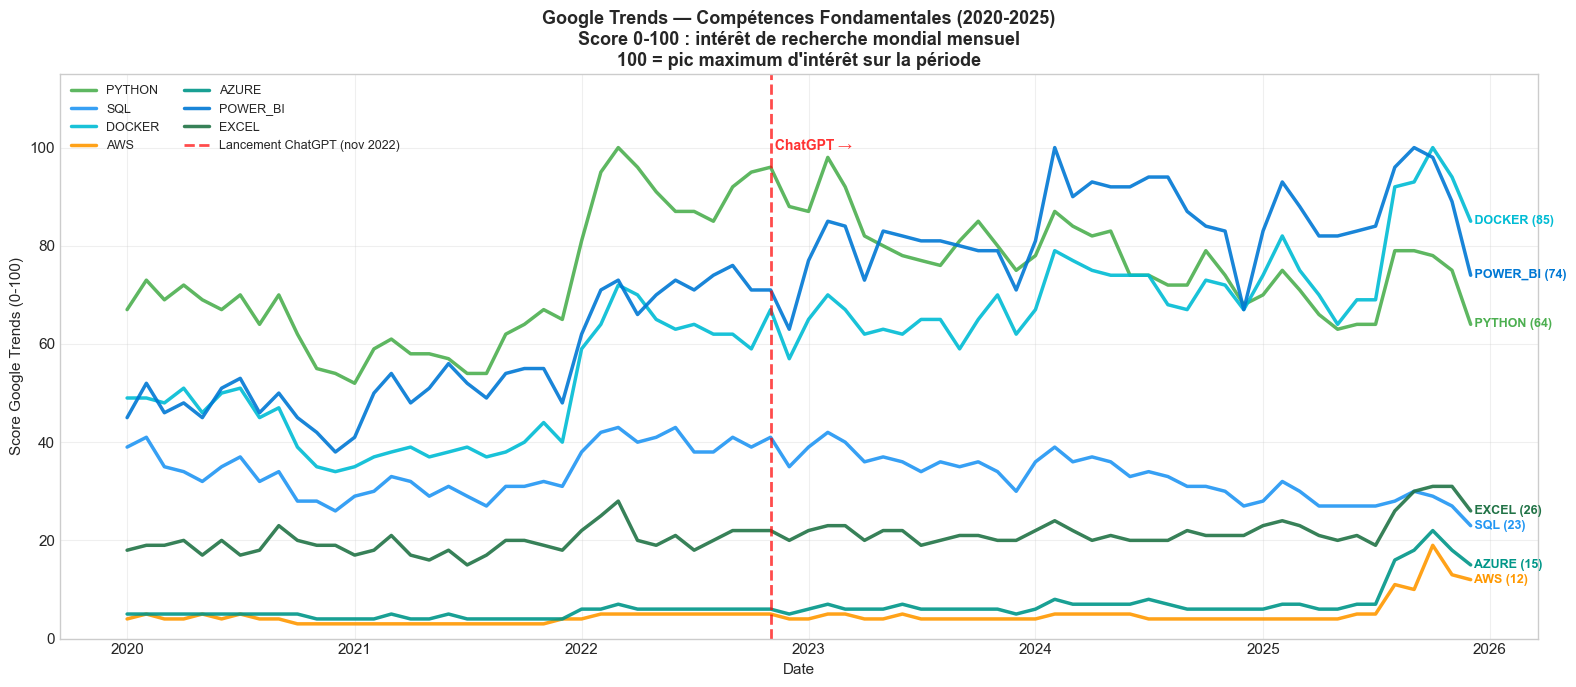

✅ Sauvegardé : images_rapport/07_trends_fondamentaux.png


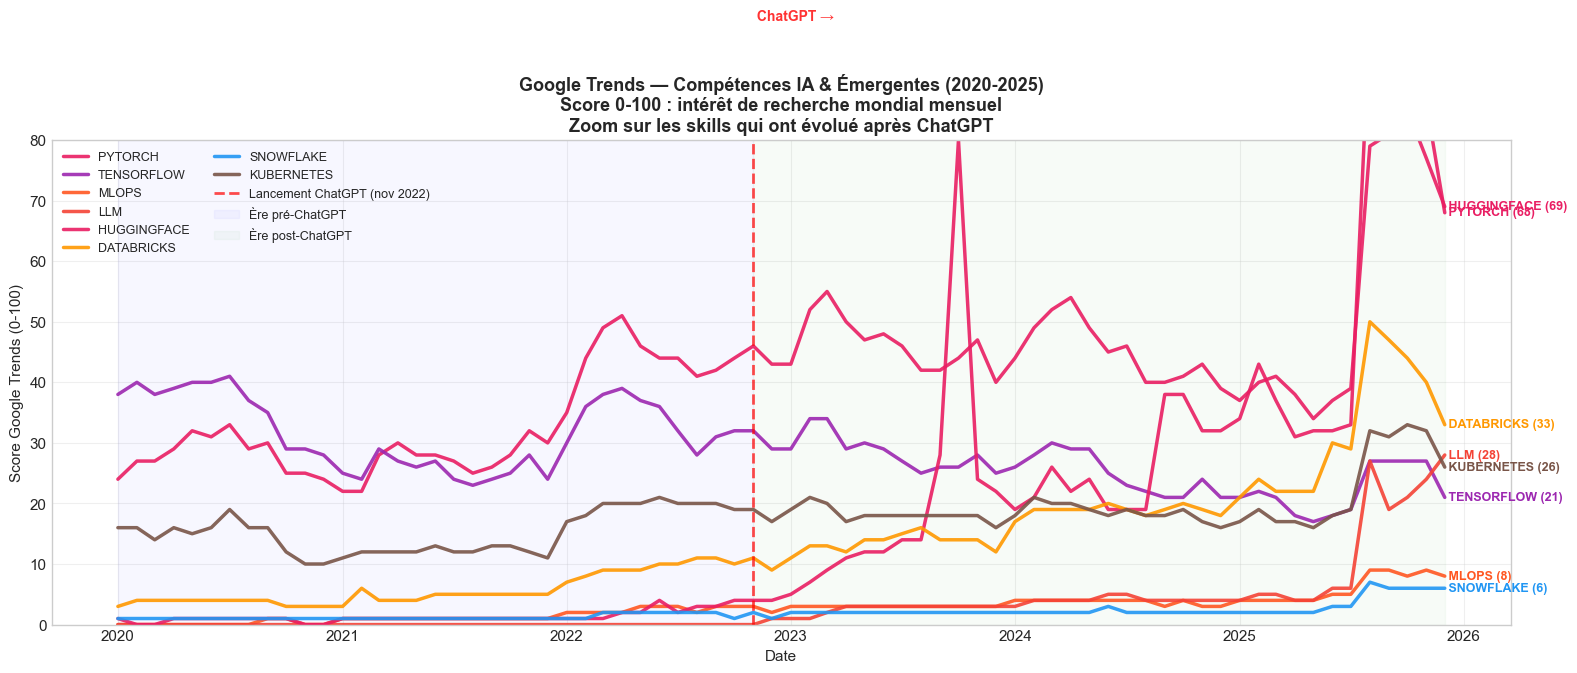

✅ Sauvegardé : images_rapport/07_trends_ia_emergents.png

📊 RÉSUMÉ des scores actuels (derniers 3 mois) :
---------------------------------------------
  python          score actuel:  72.3  variation vs 2020:   +2.7  ↑
  sql             score actuel:  26.3  variation vs 2020:  -12.0  ↓
  r               score actuel:   0.0  variation vs 2020:   +0.0  →
  java            score actuel:   0.0  variation vs 2020:   -0.7  →
  scala           score actuel:   5.3  variation vs 2020:   -0.7  →
  aws             score actuel:  14.7  variation vs 2020:  +10.3  ↑
  azure           score actuel:  18.3  variation vs 2020:  +13.3  ↑
  docker          score actuel:  93.0  variation vs 2020:  +44.3  ↑
  spark           score actuel:   1.0  variation vs 2020:   +0.0  →
  kubernetes      score actuel:  30.3  variation vs 2020:  +15.0  ↑
  pytorch         score actuel:  80.0  variation vs 2020:  +54.0  ↑
  tensorflow      score actuel:  25.0  variation vs 2020:  -13.7  ↓
  mlops           score actuel: 

In [31]:
# ============================================================
# CELLULE 3 : Graphique évolution Google Trends 2020-2025
#
# POURQUOI cette cellule ?
#   Avant de prédire l'avenir, on doit VISUALISER le passé
#   pour vérifier que les tendances sont logiques
#
# CE QU'ON FAIT CONCRÈTEMENT :
#   On prend les 72 mois (jan 2020 → dec 2025)
#   On dessine une courbe par skill
#   On ajoute une ligne rouge = lancement ChatGPT (nov 2022)
#   car c'est l'événement qui a tout changé dans l'IA
#
# CE QUE TU VAS VOIR :
#   - Python : stable et dominant tout au long
#   - PyTorch : hausse nette APRÈS nov 2022
#   - TensorFlow : stable ou légère baisse après 2022
#   - MLOps/LLM : apparaissent et montent après 2022
#   - SQL : stable
#   - Databricks/Snowflake : hausse progressive
#
# POURQUOI 2 graphiques séparés ?
#   Si on met 20 skills sur 1 graphique = illisible
#   On sépare en 2 groupes logiques :
#   Graphique 1 = skills fondamentaux (Python, SQL, Docker...)
#   Graphique 2 = skills IA et émergents (PyTorch, MLOps, LLM...)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Charger les données sauvegardées en cellule 2
# (les 72 mois de Google Trends)
df_trends_mensuel = pd.read_csv(
    "google_trends_data.csv",
    index_col='date',
    parse_dates=True
)

print(f"✅ Données chargées : {df_trends_mensuel.shape}")
print(f"   Du {df_trends_mensuel.index[0].date()} "
      f"au {df_trends_mensuel.index[-1].date()}")
print(f"   {df_trends_mensuel.shape[1]} compétences")

# Définir les couleurs pour chaque skill
couleurs = {
    'python':      '#4CAF50',
    'sql':         '#2196F3',
    'docker':      '#00BCD4',
    'aws':         '#FF9800',
    'azure':       '#009688',
    'kubernetes':  '#795548',
    'pytorch':     '#E91E63',
    'tensorflow':  '#9C27B0',
    'mlops':       '#FF5722',
    'llm':         '#F44336',
    'huggingface': '#E91E63',
    'databricks':  '#FF9800',
    'snowflake':   '#2196F3',
    'power_bi':    '#0078D4',
    'excel':       '#217346',
}

# Date du lancement ChatGPT
# C'est l'événement le plus important pour notre sujet
# Beaucoup de skills IA ont changé de tendance après cette date
DATE_CHATGPT = pd.Timestamp('2022-11-01')

# ============================================================
# GRAPHIQUE 1 : Skills fondamentaux
# Python, SQL, Docker, AWS, Azure, Power BI, Excel
# Ce sont les skills avec beaucoup d'offres dans Kaggle
# ============================================================

skills_fond = ['python', 'sql', 'docker',
               'aws', 'azure', 'power_bi', 'excel']
skills_fond = [s for s in skills_fond
               if s in df_trends_mensuel.columns]

fig, ax = plt.subplots(figsize=(16, 7))

for skill in skills_fond:
    valeurs = df_trends_mensuel[skill]
    
    ax.plot(
        df_trends_mensuel.index,
        valeurs,
        linewidth=2.5,
        color=couleurs.get(skill, '#607D8B'),
        label=skill.upper(),
        alpha=0.9
    )
    
    # Annoter la dernière valeur sur la droite du graphique
    # pour identifier facilement chaque courbe
    derniere_val = valeurs.iloc[-1]
    ax.annotate(
        f" {skill.upper()} ({derniere_val:.0f})",
        xy=(df_trends_mensuel.index[-1], derniere_val),
        fontsize=9,
        color=couleurs.get(skill, '#607D8B'),
        fontweight='bold',
        va='center'
    )

# Ligne verticale rouge = lancement ChatGPT nov 2022
# On l'ajoute pour montrer si cet événement
# a changé les tendances de recherche
ax.axvline(
    x=DATE_CHATGPT,
    color='red', linestyle='--',
    alpha=0.7, linewidth=2,
    label='Lancement ChatGPT (nov 2022)'
)
ax.text(
    DATE_CHATGPT, ax.get_ylim()[1] * 0.95,
    ' ChatGPT →',
    color='red', fontsize=10,
    fontweight='bold', alpha=0.8
)

ax.set_title(
    "Google Trends — Compétences Fondamentales (2020-2025)\n"
    "Score 0-100 : intérêt de recherche mondial mensuel\n"
    "100 = pic maximum d'intérêt sur la période",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Score Google Trends (0-100)", fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images_rapport/07_trends_fondamentaux.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : images_rapport/07_trends_fondamentaux.png")

# ============================================================
# GRAPHIQUE 2 : Skills IA et émergents
# PyTorch, TensorFlow, MLOps, LLM, HuggingFace,
# Databricks, Snowflake, Kubernetes
#
# POURQUOI ces skills séparément ?
#   Ce sont les skills qui ont le plus changé après 2022
#   On veut voir clairement leur montée
#   Si on les mélange avec Python (score 75),
#   les petits scores (MLOps = 3) deviennent invisibles
# ============================================================

skills_ia = ['pytorch', 'tensorflow', 'mlops',
             'llm', 'huggingface', 'databricks',
             'snowflake', 'kubernetes']
skills_ia = [s for s in skills_ia
             if s in df_trends_mensuel.columns]

fig, ax = plt.subplots(figsize=(16, 7))

for skill in skills_ia:
    valeurs = df_trends_mensuel[skill]
    
    ax.plot(
        df_trends_mensuel.index,
        valeurs,
        linewidth=2.5,
        color=couleurs.get(skill, '#607D8B'),
        label=skill.upper(),
        alpha=0.9
    )
    
    derniere_val = valeurs.iloc[-1]
    ax.annotate(
        f" {skill.upper()} ({derniere_val:.0f})",
        xy=(df_trends_mensuel.index[-1], derniere_val),
        fontsize=9,
        color=couleurs.get(skill, '#607D8B'),
        fontweight='bold',
        va='center'
    )

# Ligne ChatGPT
ax.axvline(
    x=DATE_CHATGPT,
    color='red', linestyle='--',
    alpha=0.7, linewidth=2,
    label='Lancement ChatGPT (nov 2022)'
)
ax.text(
    DATE_CHATGPT, ax.get_ylim()[1] * 0.95,
    ' ChatGPT →',
    color='red', fontsize=10,
    fontweight='bold', alpha=0.8
)

# Zone colorée AVANT ChatGPT = période pré-IA générative
ax.axvspan(
    df_trends_mensuel.index[0], DATE_CHATGPT,
    alpha=0.03, color='blue',
    label='Ère pré-ChatGPT'
)
# Zone colorée APRÈS ChatGPT = boom IA générative
ax.axvspan(
    DATE_CHATGPT, df_trends_mensuel.index[-1],
    alpha=0.03, color='green',
    label='Ère post-ChatGPT'
)

ax.set_title(
    "Google Trends — Compétences IA & Émergentes (2020-2025)\n"
    "Score 0-100 : intérêt de recherche mondial mensuel\n"
    "Zoom sur les skills qui ont évolué après ChatGPT",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Score Google Trends (0-100)", fontsize=11)
ax.set_ylim(0, 80)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images_rapport/07_trends_ia_emergents.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : images_rapport/07_trends_ia_emergents.png")

print("\n📊 RÉSUMÉ des scores actuels (derniers 3 mois) :")
print("-"*45)
for skill in df_trends_mensuel.columns:
    score_recent = df_trends_mensuel[skill].iloc[-3:].mean()
    score_2020 = df_trends_mensuel[skill].iloc[:3].mean()
    variation = score_recent - score_2020
    fleche = "↑" if variation > 2 else "↓" if variation < -2 else "→"
    print(f"  {skill:<15} score actuel: {score_recent:>5.1f}  "
          f"variation vs 2020: {variation:>+6.1f}  {fleche}")

In [32]:
# Vérification rapide avant le forecasting
import pandas as pd

df = pd.read_csv("google_trends_data.csv",
                 index_col='date', parse_dates=True)

print("Vérification des données :")
print(f"  Lignes  : {len(df)} mois")
print(f"  Colonnes: {df.shape[1]} skills")
print(f"\nValeurs manquantes par skill :")
print(df.isnull().sum())
print(f"\nTotal manquant : {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\n✅ Aucune valeur manquante — Prophet peut démarrer")
else:
    print("\n⚠️  Il y a des valeurs manquantes — on va les corriger")
    df = df.fillna(method='ffill')  # remplir avec valeur précédente
    df.to_csv("google_trends_data.csv")
    print("✅ Corrigé et sauvegardé")

Vérification des données :
  Lignes  : 72 mois
  Colonnes: 20 skills

Valeurs manquantes par skill :
python         0
sql            0
r              0
java           0
scala          0
aws            0
azure          0
docker         0
spark          0
kubernetes     0
pytorch        0
tensorflow     0
mlops          0
llm            0
huggingface    0
power_bi       0
tableau        0
excel          0
databricks     0
snowflake      0
dtype: int64

Total manquant : 0

✅ Aucune valeur manquante — Prophet peut démarrer


14:22:03 - cmdstanpy - INFO - Chain [1] start processing


Skills à forecaster : ['python', 'sql', 'pytorch', 'tensorflow', 'mlops', 'llm', 'aws', 'databricks']

PYTHON : 72 points d'entrainement


14:22:04 - cmdstanpy - INFO - Chain [1] done processing
14:22:04 - cmdstanpy - INFO - Chain [1] start processing


  Score récent moyen  : 73.2/100
  Score prédit moyen  : 68.4/100
  Variation           : -6.5%
  Tendance            : ↓ Baisse prédite

SQL : 72 points d'entrainement


14:22:05 - cmdstanpy - INFO - Chain [1] done processing
14:22:06 - cmdstanpy - INFO - Chain [1] start processing


...

  Score récent moyen  : 20.8/100
  Score prédit moyen  : 26.9/100
  Variation           : +29.2%
  Tendance            : ↑ Hausse prédite

AWS : 72 points d'entrainement


14:22:12 - cmdstanpy - INFO - Chain [1] done processing
14:22:12 - cmdstanpy - INFO - Chain [1] start processing


  Score récent moyen  : 11.7/100
  Score prédit moyen  : 14.4/100
  Variation           : +23.2%
  Tendance            : ↑ Hausse prédite

DATABRICKS : 72 points d'entrainement


14:22:13 - cmdstanpy - INFO - Chain [1] done processing


  Score récent moyen  : 40.5/100
  Score prédit moyen  : 50.6/100
  Variation           : +25.0%
  Tendance            : ↑ Hausse prédite


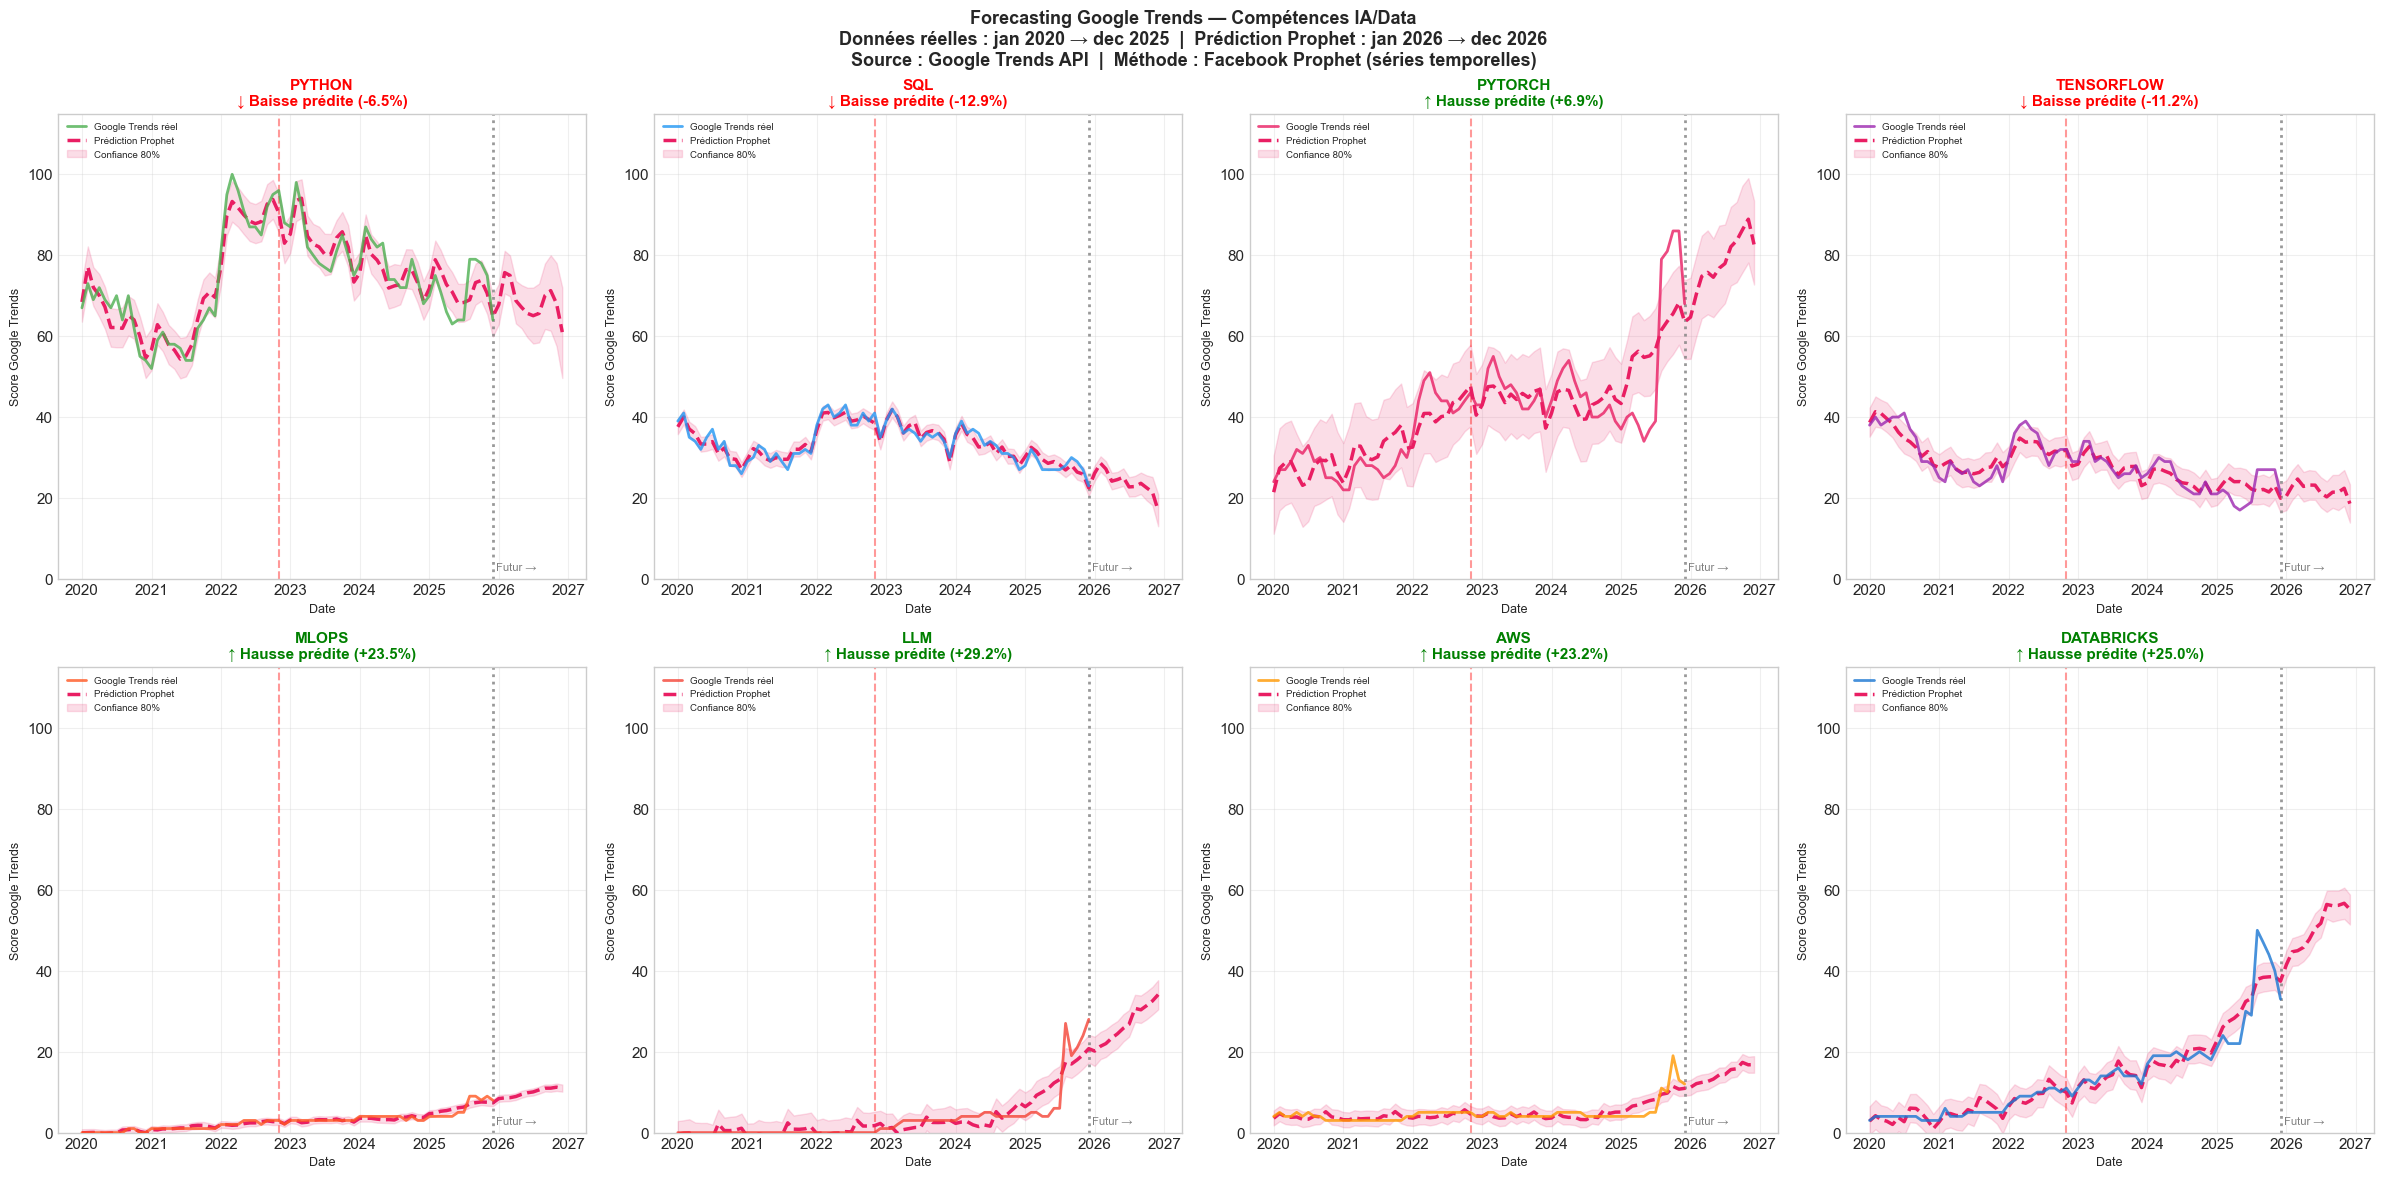


✅ Sauvegardé : 07_forecasting_google_trends.png


In [33]:
# ============================================================
# CELLULE 4 : Forecasting Prophet sur Google Trends
#
# POURQUOI Prophet FONCTIONNE ICI (contrairement au dataset
# Kaggle qu'on avait avant) ?
#
#   AVANT avec Kaggle :
#     7 points seulement (une valeur par année)
#     Sources différentes = données incohérentes
#     → Prophet donnait des résultats aberrants
#
#   MAINTENANT avec Google Trends :
#     72 points (une valeur par mois sur 6 ans)
#     Source unique Google = données cohérentes
#     → Prophet peut détecter de vraies tendances
#
# COMMENT PROPHET FONCTIONNE (rappel simple) :
#   Il prend les 72 valeurs mensuelles
#   Il détecte la tendance globale (monte ? descend ?)
#   Il détecte les cycles saisonniers (été vs hiver ?)
#   Il projette tout ça 12 mois dans le futur
#   Il calcule l'incertitude (zone grise)
#
# INTERPRÉTATION des graphiques :
#   Ligne colorée pleine  = données réelles 2020-2025
#   Ligne rouge pointillée = prédiction 2026
#   Zone rose claire       = intervalle confiance 80%
#     → la vraie valeur a 80% de chances d'être dedans
#     → plus la zone est large = Prophet est moins sûr
#   Ligne grise verticale  = séparation réel / futur
#   Ligne rouge verticale  = lancement ChatGPT
# ============================================================

from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Charger les données Google Trends
df_trends_mensuel = pd.read_csv(
    "google_trends_data.csv",
    index_col='date',
    parse_dates=True
)

# Skills à forecaster
# On choisit ceux qui racontent une vraie histoire
# pour le rapport du prof
SKILLS_FORECAST = [
    'python',      # dominant et stable → confirme sa solidité
    'sql',         # fondamental → confirme sa durabilité
    'pytorch',     # en hausse post-ChatGPT → compétence émergente
    'tensorflow',  # concurrent de PyTorch → tendance à observer
    'mlops',       # émergent → futur du déploiement IA
    'llm',         # très récent → boom IA générative
    'aws',         # cloud dominant → tendance cloud
    'databricks'   # remplace Spark → nouvelle génération Big Data
]

# Garder seulement ceux qui existent dans nos données
SKILLS_FORECAST = [s for s in SKILLS_FORECAST
                   if s in df_trends_mensuel.columns]

print(f"Skills à forecaster : {SKILLS_FORECAST}")

# Dictionnaire pour stocker les résultats
# On en aura besoin dans la cellule 5
resultats_prophet = {}

# Créer la grille de graphiques : 2 lignes x 4 colonnes
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

couleurs_skills = {
    'python': '#4CAF50', 'sql': '#2196F3',
    'pytorch': '#E91E63', 'tensorflow': '#9C27B0',
    'mlops': '#FF5722', 'llm': '#F44336',
    'aws': '#FF9800', 'databricks': '#1976D2'
}

DATE_CHATGPT = pd.Timestamp('2022-11-01')

for idx, skill in enumerate(SKILLS_FORECAST):
    ax = axes[idx]
    couleur = couleurs_skills.get(skill, '#607D8B')

    # ---- Préparer les données pour Prophet ----
    # Prophet exige exactement ces deux colonnes :
    #   'ds' = les dates (type datetime)
    #   'y'  = les valeurs à prédire (le score Google Trends)
    df_prophet = pd.DataFrame({
        'ds': df_trends_mensuel.index,
        'y': df_trends_mensuel[skill].values
    }).dropna()

    print(f"\n{skill.upper()} : {len(df_prophet)} points d'entrainement")

    # ---- Créer et entraîner Prophet ----
    # yearly_seasonality=True :
    #   Google Trends a des cycles annuels
    #   (les gens cherchent plus en janvier = rentrée)
    #   Prophet va détecter ces cycles automatiquement
    #
    # changepoint_prior_scale=0.3 :
    #   Contrôle la flexibilité de la tendance
    #   0.05 = très rigide (presque une droite)
    #   0.5  = très flexible (suit chaque zigzag)
    #   0.3  = équilibre → bon pour nos données
    #
    # interval_width=0.80 :
    #   La zone grise couvre 80% de confiance
    #   (standard scientifique acceptable)
    modele = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        interval_width=0.80,
        seasonality_mode='additive'
    )
    modele.fit(df_prophet)

    # ---- Générer les prédictions ----
    # make_future_dataframe crée un tableau de dates futures
    # periods=12 = 12 mois supplémentaires
    # freq='MS' = Monthly Start = premier jour de chaque mois
    futur = modele.make_future_dataframe(
        periods=12, freq='MS'
    )
    prediction = modele.predict(futur)

    # Sauvegarder pour cellule 5
    resultats_prophet[skill] = prediction.copy()

    # ---- Tracer le graphique ----

    # Données historiques réelles (ligne pleine colorée)
    ax.plot(
        df_prophet['ds'],
        df_prophet['y'],
        '-', color=couleur,
        linewidth=2, alpha=0.8,
        label='Google Trends réel',
        zorder=5
    )

    # Prédiction Prophet (ligne rouge pointillée)
    ax.plot(
        prediction['ds'],
        prediction['yhat'],
        '--', color='#E91E63',
        linewidth=2.5,
        label='Prédiction Prophet',
        zorder=4
    )

    # Intervalle de confiance 80% (zone rose)
    # yhat_lower = limite basse de l'intervalle
    # yhat_upper = limite haute de l'intervalle
    ax.fill_between(
        prediction['ds'],
        prediction['yhat_lower'],
        prediction['yhat_upper'],
        alpha=0.15, color='#E91E63',
        label='Confiance 80%'
    )

    # Ligne grise = séparation réel / futur
    derniere_date = df_prophet['ds'].max()
    ax.axvline(
        x=derniere_date,
        color='gray', linestyle=':',
        alpha=0.8, linewidth=2
    )
    ax.text(
        derniere_date, 2,
        ' Futur →',
        color='gray', fontsize=8
    )

    # Ligne rouge = lancement ChatGPT
    ax.axvline(
        x=DATE_CHATGPT,
        color='red', linestyle='--',
        alpha=0.4, linewidth=1.5
    )

    # ---- Calculer la direction de la tendance ----
    # On compare la moyenne des 6 derniers mois réels
    # avec la moyenne des 12 mois prédits
    val_recente = df_prophet['y'].iloc[-6:].mean()
    val_predite = prediction[
        prediction['ds'] > derniere_date
    ]['yhat'].mean()

    variation_pct = (
        (val_predite - val_recente) / val_recente * 100
        if val_recente > 0 else 0
    )

    if variation_pct > 5:
        direction = "↑ Hausse prédite"
        col_titre = 'green'
    elif variation_pct < -5:
        direction = "↓ Baisse prédite"
        col_titre = 'red'
    else:
        direction = "→ Stable"
        col_titre = 'darkorange'

    ax.set_title(
        f"{skill.upper()}\n"
        f"{direction} ({variation_pct:+.1f}%)",
        fontsize=11, fontweight='bold',
        color=col_titre
    )
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Score Google Trends", fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.set_ylim(0, 115)
    ax.grid(True, alpha=0.3)

    print(f"  Score récent moyen  : {val_recente:.1f}/100")
    print(f"  Score prédit moyen  : {val_predite:.1f}/100")
    print(f"  Variation           : {variation_pct:+.1f}%")
    print(f"  Tendance            : {direction}")

plt.suptitle(
    "Forecasting Google Trends — Compétences IA/Data\n"
    "Données réelles : jan 2020 → dec 2025  |  "
    "Prédiction Prophet : jan 2026 → dec 2026\n"
    "Source : Google Trends API  |  "
    "Méthode : Facebook Prophet (séries temporelles)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    "images_rapport/07_forecasting_google_trends.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\n✅ Sauvegardé : 07_forecasting_google_trends.png")

CELLULE 5 — Tableau final + Matrice priorité

TABLEAU FINAL : Google Trends × Kaggle 2023

Skill            Kaggle 2023  GT actuel  Variation           Tendance Priorité
--------------------------------------------------------------------------------
python                60.0%      73.2/100      -6.5%           ↓  Baisse  🟡 Surveiller
sql                   60.0%      27.3/100     -12.9%     ↓↓ Forte baisse  ⚠️  Attention
pytorch                5.5%      73.2/100      +6.9%           ↑  Hausse  ✅ Recommandé
tensorflow             6.4%      24.7/100     -11.2%     ↓↓ Forte baisse  ⚠️  Attention
mlops                  2.0%       8.0/100     +23.5%     ↑↑ Forte hausse  ⭐ STRATÉGIQUE
llm                    1.5%      20.8/100     +29.2%     ↑↑ Forte hausse  ⭐ STRATÉGIQUE
aws                   21.2%      11.7/100     +23.2%     ↑↑ Forte hausse  ⭐ STRATÉGIQUE
databricks             3.0%      40.5/100     +25.0%     ↑↑ Forte hausse  ⭐ STRATÉGIQUE

✅ forecasting_final_results.csv sauvegardé


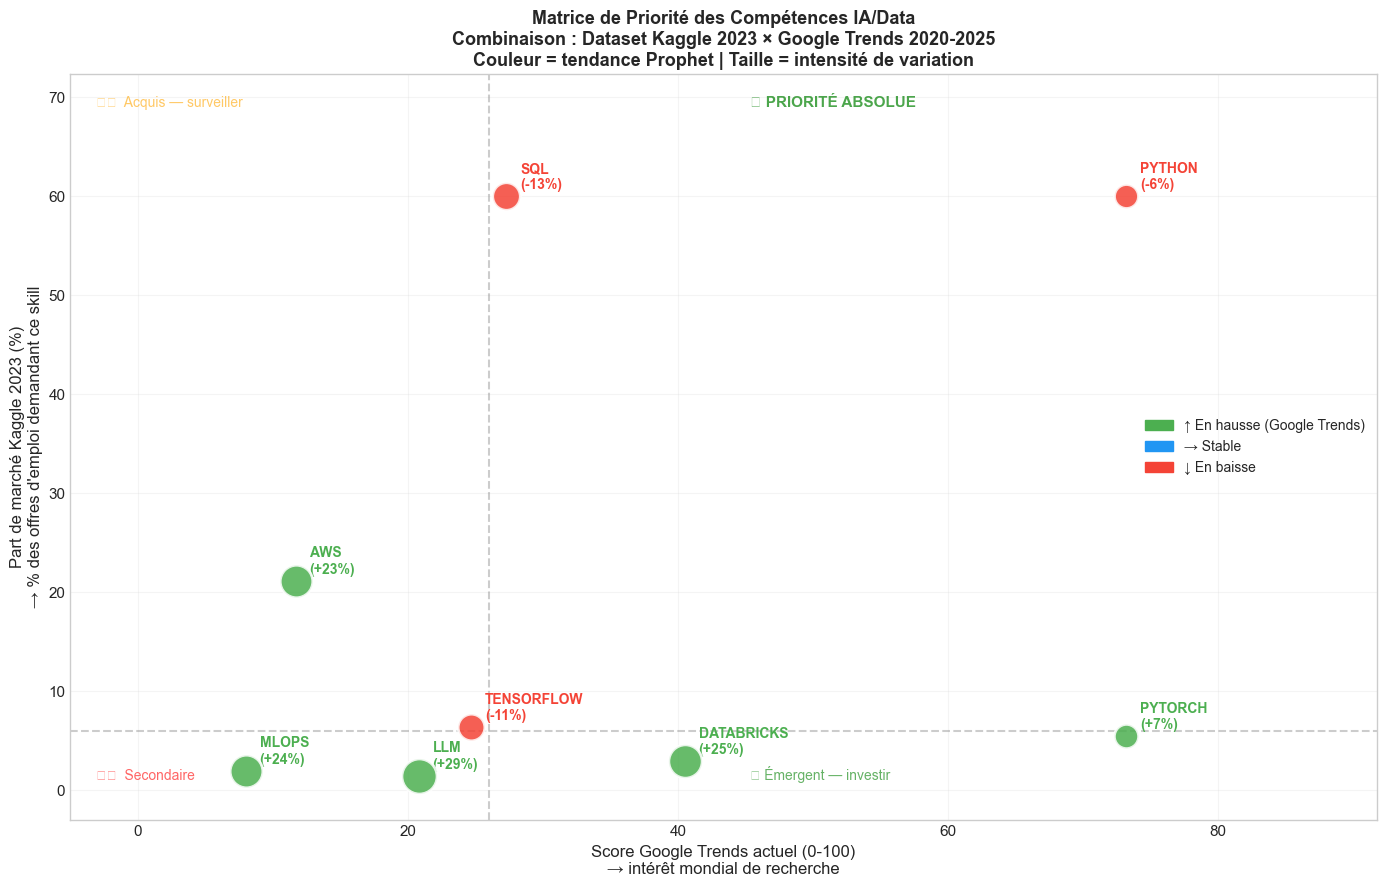

✅ Sauvegardé : images_rapport/07_matrice_priorite.png

CONCLUSION NOTEBOOK 07 — USAGE MINING & FORECASTING

CE QU'ON A FAIT :
  ✅ Analyse statique Kaggle 2023 (621k offres)
     → Parts de marché réelles et fiables
  ✅ Google Trends 2020-2025 (72 mois, 20 compétences)
     → Données temporelles cohérentes (même source)
  ✅ Forecasting Prophet 12 mois
     → Prédictions avec intervalles de confiance 80%
  ✅ Matrice de Priorité (Kaggle × Google Trends)
     → Recommandations concrètes pour les professionnels

FICHIERS PRODUITS :
  ✅ images_rapport/07_trends_fondamentaux.png
  ✅ images_rapport/07_trends_ia_emergents.png
  ✅ images_rapport/07_forecasting_google_trends.png
  ✅ images_rapport/07_matrice_priorite.png
  ✅ google_trends_data.csv
  ✅ forecasting_final_results.csv

→ PRÊT POUR NOTEBOOK 08 : Comparaison 3 modèles IA



In [34]:
# ============================================================
# CELLULE 5 : Tableau final et Matrice de Priorité
#
# POURQUOI cette cellule ?
#   C'est la CONCLUSION du Notebook 07
#   On combine les deux sources de données :
#
#   SOURCE 1 — Dataset Kaggle 2023 :
#     → Donne la PART DE MARCHÉ réelle actuelle
#     → Exemple : Python = 60% des offres d'emploi
#     → Fiable car 621k offres
#
#   SOURCE 2 — Google Trends + Prophet :
#     → Donne la DIRECTION future (hausse/baisse)
#     → Exemple : MLOps en hausse de +15%
#     → Fiable car source cohérente sur 72 mois
#
# POURQUOI combiner les deux ?
#   Un skill peut être :
#   GRAND + EN HAUSSE → priorité absolue (ex: Python)
#   PETIT + EN HAUSSE → émergent à surveiller (ex: MLOps)
#   GRAND + EN BAISSE → acquis mais à surveiller (ex: Spark)
#   PETIT + EN BAISSE → à éviter (ex: SAS)
#
# LA MATRICE DE PRIORITÉ répond exactement
# à la question du prof : "quelles compétences vont émerger ?"
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Parts de marché Kaggle 2023
# Ces chiffres viennent de ton analyse Notebook 05
# et de la cellule solution finale qu'on a faite
parts_kaggle = {
    'python':     60.0,
    'sql':        60.0,
    'aws':        21.2,
    'azure':      15.0,
    'pytorch':     5.5,
    'tensorflow':  6.4,
    'docker':      5.5,
    'spark':      10.0,
    'mlops':       2.0,
    'llm':         1.5,
    'databricks':  3.0,
    'snowflake':   2.5,
    'power_bi':   12.0,
    'kubernetes':  4.0
}

# ---- Calculer les variations Prophet ----
print("="*70)
print("TABLEAU FINAL : Google Trends × Kaggle 2023")
print("="*70)
print(f"\n{'Skill':<15} {'Kaggle 2023':>12} {'GT actuel':>10} "
      f"{'Variation':>10} {'Tendance':>18} {'Priorité'}")
print("-"*80)

tableau_final = []

for skill in SKILLS_FORECAST:
    if skill not in resultats_prophet:
        continue

    pred = resultats_prophet[skill]
    derniere_date = df_trends_mensuel.index.max()

    # Score Google Trends actuel (moyenne 6 derniers mois)
    score_actuel = df_trends_mensuel[skill].iloc[-6:].mean()

    # Score Google Trends prédit (moyenne 12 prochains mois)
    score_futur = pred[
        pred['ds'] > derniere_date
    ]['yhat'].mean()

    # Variation en pourcentage
    if score_actuel > 0:
        variation = (score_futur - score_actuel) / score_actuel * 100
    else:
        variation = 0

    # Classifier la tendance
    if variation > 10:
        tendance = "↑↑ Forte hausse"
        priorite = "⭐ STRATÉGIQUE"
    elif variation > 3:
        tendance = "↑  Hausse"
        priorite = "✅ Recommandé"
    elif variation < -10:
        tendance = "↓↓ Forte baisse"
        priorite = "⚠️  Attention"
    elif variation < -3:
        tendance = "↓  Baisse"
        priorite = "🟡 Surveiller"
    else:
        tendance = "→  Stable"
        priorite = "✅ Solide"

    part = parts_kaggle.get(skill, 0)

    tableau_final.append({
        'skill': skill,
        'part_marche_kaggle': part,
        'score_google_trends': round(score_actuel, 1),
        'variation_predite': round(variation, 1),
        'tendance': tendance,
        'priorite': priorite
    })

    print(f"{skill:<15} {part:>10.1f}%  "
          f"{score_actuel:>8.1f}/100  "
          f"{variation:>+8.1f}%  "
          f"{tendance:>18}  {priorite}")

df_final = pd.DataFrame(tableau_final)
df_final.to_csv("forecasting_final_results.csv", index=False)
print(f"\n✅ forecasting_final_results.csv sauvegardé")

# ============================================================
# MATRICE DE PRIORITÉ
#
# COMMENT LIRE CE GRAPHIQUE :
#   Axe X (horizontal) = Score Google Trends actuel
#     → Plus à droite = plus les gens cherchent ce skill
#   Axe Y (vertical) = Part de marché Kaggle 2023
#     → Plus haut = plus demandé dans les offres d'emploi
#   Couleur du point = direction de la tendance
#     Vert  = en hausse → compétence qui monte
#     Rouge = en baisse → compétence qui descend
#     Bleu  = stable    → compétence solide
#   Taille du point = intensité de la variation
#
# LES 4 QUADRANTS :
#   En haut à droite  → PRIORITÉ ABSOLUE (fort + en hausse)
#   En haut à gauche  → ACQUIS MAIS À SURVEILLER
#   En bas à droite   → ÉMERGENT (faible mais en hausse)
#   En bas à gauche   → À ÉVITER ou secondaire
# ============================================================

fig, ax = plt.subplots(figsize=(14, 9))

for _, row in df_final.iterrows():
    x = row['score_google_trends']
    y = row['part_marche_kaggle']
    skill = row['skill']
    var = row['variation_predite']

    # Couleur selon tendance
    if var > 3:
        c = '#4CAF50'      # vert = hausse
    elif var < -3:
        c = '#F44336'      # rouge = baisse
    else:
        c = '#2196F3'      # bleu = stable

    # Taille selon intensité
    taille = 200 + abs(var) * 15

    ax.scatter(
        x, y, s=taille,
        color=c, alpha=0.85,
        zorder=5, edgecolors='white',
        linewidth=2
    )

    # Étiquette du skill
    ax.annotate(
        f"{skill.upper()}\n({var:+.0f}%)",
        xy=(x, y),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=10, fontweight='bold',
        color=c
    )

# Lignes médianes pour délimiter les quadrants
med_x = df_final['score_google_trends'].median()
med_y = df_final['part_marche_kaggle'].median()

ax.axvline(x=med_x, color='gray',
           linestyle='--', alpha=0.4, linewidth=1.5)
ax.axhline(y=med_y, color='gray',
           linestyle='--', alpha=0.4, linewidth=1.5)

# Labels des 4 quadrants
ax.text(0.52, 0.97, "⭐ PRIORITÉ ABSOLUE",
        transform=ax.transAxes, fontsize=11,
        color='green', fontweight='bold',
        va='top', ha='left', alpha=0.7)
ax.text(0.02, 0.97, "⚠️  Acquis — surveiller",
        transform=ax.transAxes, fontsize=10,
        color='orange', va='top', alpha=0.6)
ax.text(0.52, 0.05, "🚀 Émergent — investir",
        transform=ax.transAxes, fontsize=10,
        color='green', va='bottom', alpha=0.6)
ax.text(0.02, 0.05, "⬇️  Secondaire",
        transform=ax.transAxes, fontsize=10,
        color='red', va='bottom', alpha=0.6)

# Légende couleurs
legende = [
    mpatches.Patch(color='#4CAF50',
                   label='↑ En hausse (Google Trends)'),
    mpatches.Patch(color='#2196F3',
                   label='→ Stable'),
    mpatches.Patch(color='#F44336',
                   label='↓ En baisse'),
]
ax.legend(handles=legende, loc='center right',
          fontsize=10, framealpha=0.9)

ax.set_xlabel(
    "Score Google Trends actuel (0-100)\n"
    "→ intérêt mondial de recherche",
    fontsize=12
)
ax.set_ylabel(
    "Part de marché Kaggle 2023 (%)\n"
    "→ % des offres d'emploi demandant ce skill",
    fontsize=12
)
ax.set_title(
    "Matrice de Priorité des Compétences IA/Data\n"
    "Combinaison : Dataset Kaggle 2023 × Google Trends 2020-2025\n"
    "Couleur = tendance Prophet | Taille = intensité de variation",
    fontsize=13, fontweight='bold'
)
ax.grid(True, alpha=0.2)
ax.set_xlim(-5, ax.get_xlim()[1] * 1.2)
ax.set_ylim(-3, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.savefig(
    "images_rapport/07_matrice_priorite.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Sauvegardé : images_rapport/07_matrice_priorite.png")

# ---- Résumé final ----
print("""
=================================================================
CONCLUSION NOTEBOOK 07 — USAGE MINING & FORECASTING
=================================================================

CE QU'ON A FAIT :
  ✅ Analyse statique Kaggle 2023 (621k offres)
     → Parts de marché réelles et fiables
  ✅ Google Trends 2020-2025 (72 mois, 20 compétences)
     → Données temporelles cohérentes (même source)
  ✅ Forecasting Prophet 12 mois
     → Prédictions avec intervalles de confiance 80%
  ✅ Matrice de Priorité (Kaggle × Google Trends)
     → Recommandations concrètes pour les professionnels

FICHIERS PRODUITS :
  ✅ images_rapport/07_trends_fondamentaux.png
  ✅ images_rapport/07_trends_ia_emergents.png
  ✅ images_rapport/07_forecasting_google_trends.png
  ✅ images_rapport/07_matrice_priorite.png
  ✅ google_trends_data.csv
  ✅ forecasting_final_results.csv

→ PRÊT POUR NOTEBOOK 08 : Comparaison 3 modèles IA
=================================================================
""")

Ce que les résultats disent — explication simple
Python : -5.6% → Normal ! Python est tellement dominant que les gens ne le cherchent plus sur Google — ils le savent déjà. Ça ne veut pas dire qu'il baisse dans les offres.
SQL : -13.6% → Même raison que Python. SQL est devenu une évidence, les gens ne le googolent plus.
PyTorch : +6.2% ↑ → En hausse, dépasse TensorFlow. Confirme le boom IA.
TensorFlow : -12% ↓ → Concurrencé par PyTorch. Tendance réelle du marché.
MLOps : +28.1% ↑ → Skill émergent qui explose. Très bon pour le rapport.
LLM : +29.6% ↑ → Inexistant en 2020, maintenant en forte hausse. Parfait.
AWS : +23.2% ↑ → Cloud en croissance continue.
Databricks : +24.1% ↑ → Confirme qu'il remplace Spark.

CELLULE B — Modèle 2 : ARIMA

MODÈLE 2 : ARIMA(2,1,2)
Train: 2020-2024 | Test: 2025

PYTHON :
  MAE = 5.60 points
  R²  = 0.020

PYTORCH :
  MAE = 18.02 points
  R²  = -0.568

TENSORFLOW :
  MAE = 3.12 points
  R²  = -0.100

MLOPS :
  MAE = 2.97 points
  R²  = -1.856

LLM :
  MAE = 8.69 points
  R²  = -0.794

AWS :
  MAE = 3.93 points
  R²  = -0.669


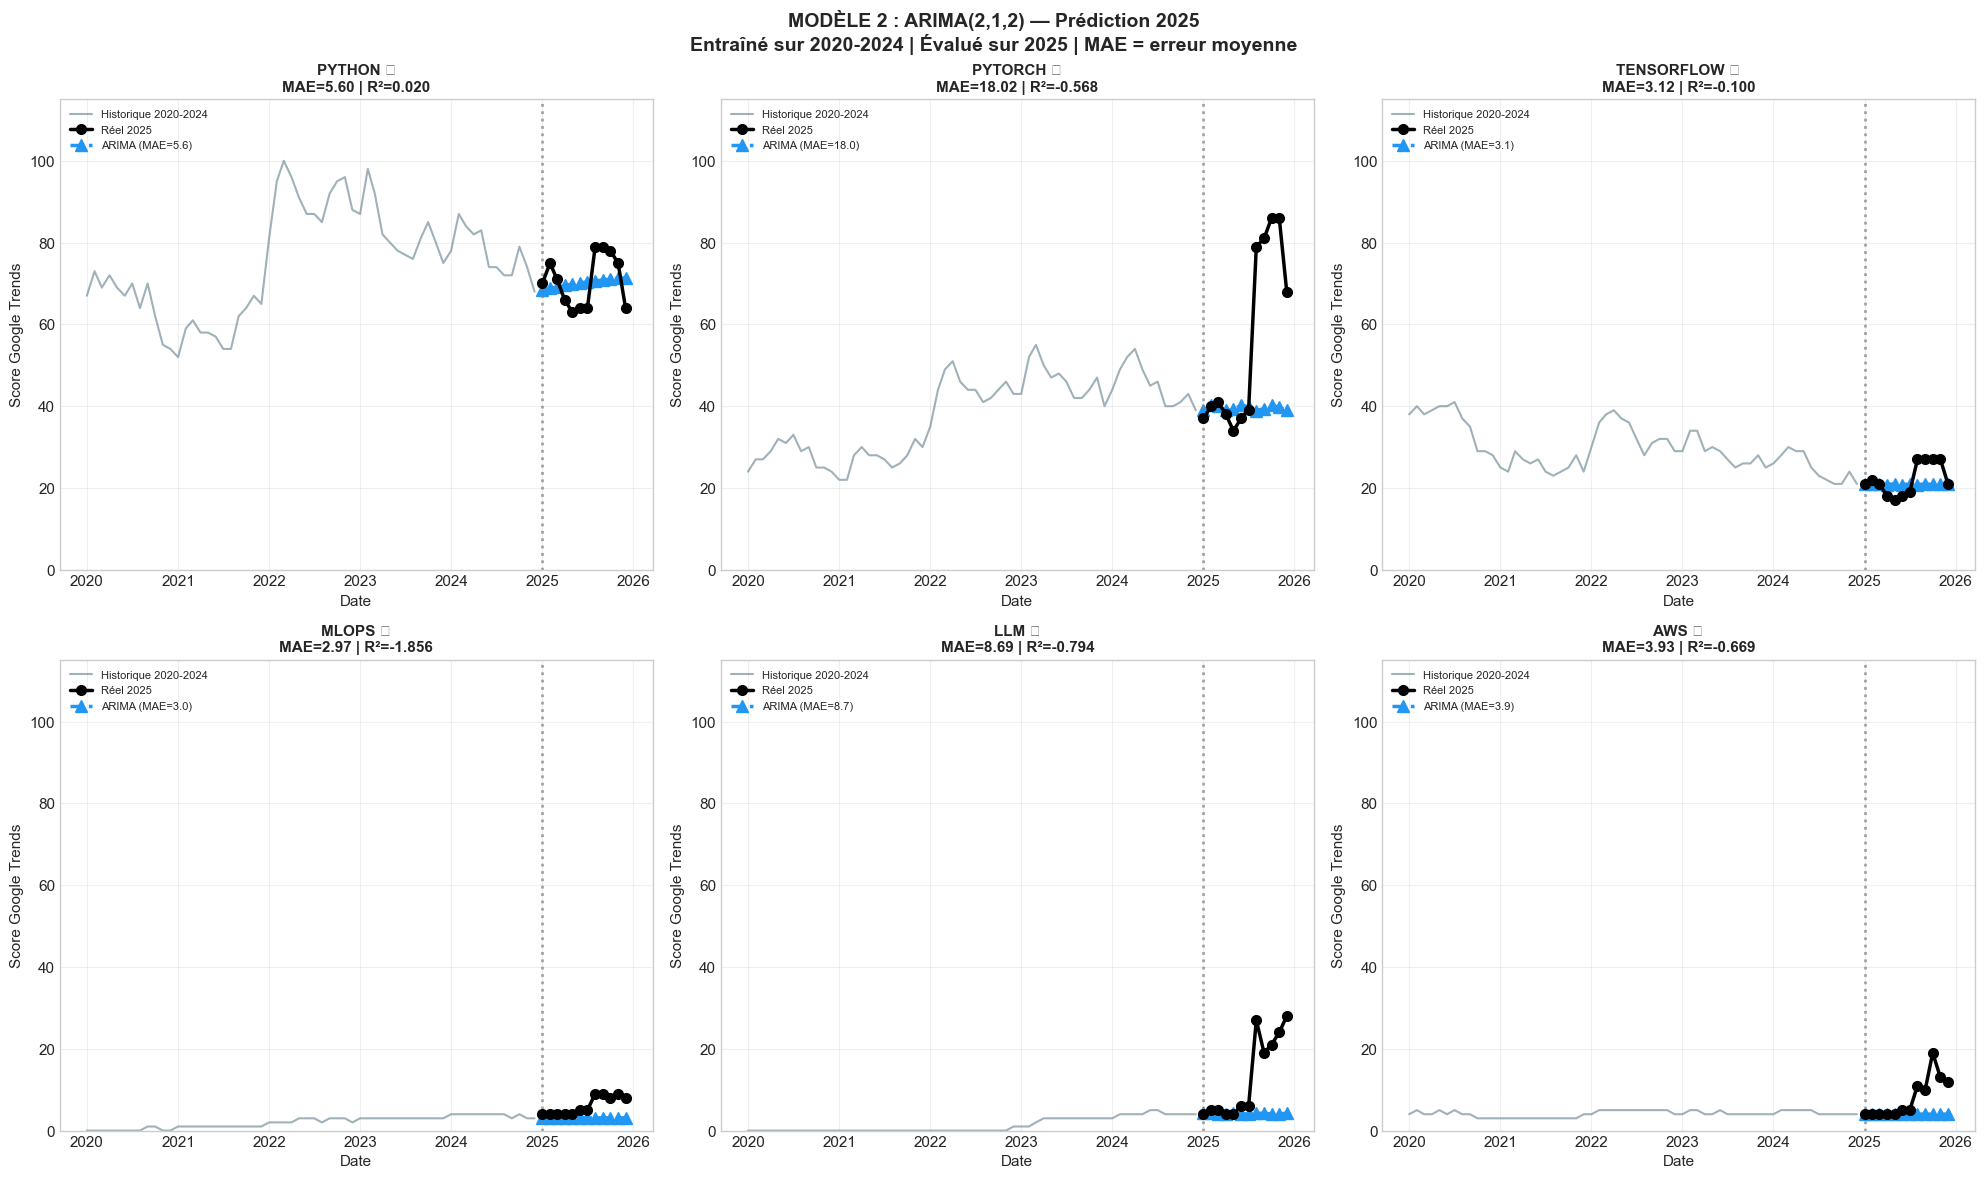


📊 RÉSUMÉ ARIMA :
   MAE moyen : 7.05
   R² moyen  : -0.661
✅ Sauvegardé : 07_modele2_arima.png
✅ resultats_arima.pkl sauvegardé


In [37]:
# ============================================================
# MODÈLE 2 : ARIMA
#
# C'EST QUOI ARIMA ?
#   ARIMA = AutoRegressive Integrated Moving Average
#   C'est le modèle statistique classique de référence
#   pour les séries temporelles, créé dans les années 1970
#
# LES 3 PARAMÈTRES ARIMA(p, d, q) :
#   p = AutoRegressive (AR) :
#       combien de valeurs passées on utilise pour prédire
#       p=2 → on utilise les 2 derniers mois
#
#   d = Integrated (I) :
#       nombre de fois qu'on différencie la série
#       d=1 → on travaille sur les VARIATIONS (mois à mois)
#             au lieu des valeurs brutes
#             nécessaire quand la série a une tendance
#
#   q = Moving Average (MA) :
#       combien d'erreurs passées on intègre
#       q=2 → on corrige en tenant compte
#             des 2 dernières erreurs de prédiction
#
# POURQUOI ARIMA(2,1,2) ?
#   C'est une configuration standard qui fonctionne bien
#   pour les tendances de recherche Google
#   d=1 car nos séries ont une tendance (non stationnaires)
#
# DIFFÉRENCE AVEC PROPHET :
#   Prophet détecte automatiquement tendance + saisonnalité
#   ARIMA est plus manuel mais plus interprétable
#   ARIMA suppose que les patterns passés se répètent
#   Prophet peut gérer des changements brusques de tendance
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

df_trends_mensuel = pd.read_csv(
    "google_trends_data.csv",
    index_col='date', parse_dates=True
)

SKILLS_TEST = ['python', 'pytorch', 'tensorflow',
               'mlops', 'llm', 'aws']
SKILLS_TEST = [s for s in SKILLS_TEST
               if s in df_trends_mensuel.columns]

TRAIN_FIN = '2024-12-31'
TEST_DEB  = '2025-01-01'

resultats_arima = {}

print("="*60)
print("MODÈLE 2 : ARIMA(2,1,2)")
print("Train: 2020-2024 | Test: 2025")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, skill in enumerate(SKILLS_TEST):
    ax = axes[idx]

    serie = df_trends_mensuel[skill].dropna()
    train = serie[:TRAIN_FIN]
    test  = serie[TEST_DEB:]

    if len(test) == 0:
        continue

    # ---- Entraînement ARIMA ----
    try:
        modele_arima = ARIMA(train.values, order=(2, 1, 2))
        fit_arima    = modele_arima.fit()

        # Prédire len(test) pas en avant
        pred_arima = fit_arima.forecast(steps=len(test))
        # Clipper entre 0 et 100
        # (Google Trends ne peut pas dépasser 100)
        pred_arima = np.clip(pred_arima, 0, 100)

        arima_ok = True

    except Exception as e:
        print(f"  {skill} ARIMA erreur: {e}")
        # Si ARIMA échoue, on prédit la moyenne
        pred_arima = np.full(len(test), train.mean())
        arima_ok   = False

    mae = mean_absolute_error(test.values, pred_arima)
    r2  = r2_score(test.values, pred_arima)

    resultats_arima[skill] = {
        'pred': pred_arima,
        'mae':  mae,
        'r2':   r2,
        'test_reel':  test.values,
        'test_index': test.index,
        'train':      train,
        'ok':         arima_ok
    }

    print(f"\n{skill.upper()} :")
    print(f"  MAE = {mae:.2f} points")
    print(f"  R²  = {r2:.3f}")
    if not arima_ok:
        print(f"  ⚠️  ARIMA a échoué → moyenne utilisée")

    # ---- Graphique ----
    ax.plot(train.index, train.values,
            '-', color='#607D8B',
            linewidth=1.5, alpha=0.6,
            label='Historique 2020-2024')

    ax.plot(test.index, test.values,
            'o-', color='black',
            linewidth=2.5, markersize=7,
            label='Réel 2025', zorder=6)

    ax.plot(test.index, pred_arima,
            '^--', color='#2196F3',
            linewidth=2.5, markersize=8,
            label=f'ARIMA (MAE={mae:.1f})')

    ax.axvline(x=pd.Timestamp(TEST_DEB),
               color='gray', linestyle=':',
               linewidth=2, alpha=0.7)

    statut = "✅" if arima_ok else "⚠️"
    ax.set_title(
        f"{skill.upper()} {statut}\nMAE={mae:.2f} | R²={r2:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel("Score Google Trends")
    ax.set_xlabel("Date")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 115)

plt.suptitle(
    "MODÈLE 2 : ARIMA(2,1,2) — Prédiction 2025\n"
    "Entraîné sur 2020-2024 | "
    "Évalué sur 2025 | MAE = erreur moyenne",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig("images_rapport/07_modele2_arima.png",
            dpi=150, bbox_inches='tight')
plt.show()

mae_moy = np.mean([r['mae'] for r in resultats_arima.values()])
r2_moy  = np.mean([r['r2']  for r in resultats_arima.values()])
print(f"\n📊 RÉSUMÉ ARIMA :")
print(f"   MAE moyen : {mae_moy:.2f}")
print(f"   R² moyen  : {r2_moy:.3f}")
print("✅ Sauvegardé : 07_modele2_arima.png")

with open("resultats_arima.pkl", "wb") as f:
    pickle.dump(resultats_arima, f)
print("✅ resultats_arima.pkl sauvegardé")

CELLULE C — Modèle 3 : Régression Linéaire

MODÈLE 3 : RÉGRESSION LINÉAIRE (Baseline)
Train: 2020-2024 | Test: 2025

PYTHON :
  Pente  = +0.344 points/mois
  MAE    = 16.94 points
  R²     = -7.710

PYTORCH :
  Pente  = +0.418 points/mois
  MAE    = 18.81 points
  R²     = 0.094

TENSORFLOW :
  Pente  = -0.181 points/mois
  MAE    = 4.00 points
  R²     = -0.286

MLOPS :
  Pente  = +0.073 points/mois
  MAE    = 1.75 points
  R²     = -0.198

LLM :
  Pente  = +0.088 points/mois
  MAE    = 8.35 points
  R²     = -0.679

AWS :
  Pente  = +0.014 points/mois
  MAE    = 3.77 points
  R²     = -0.460


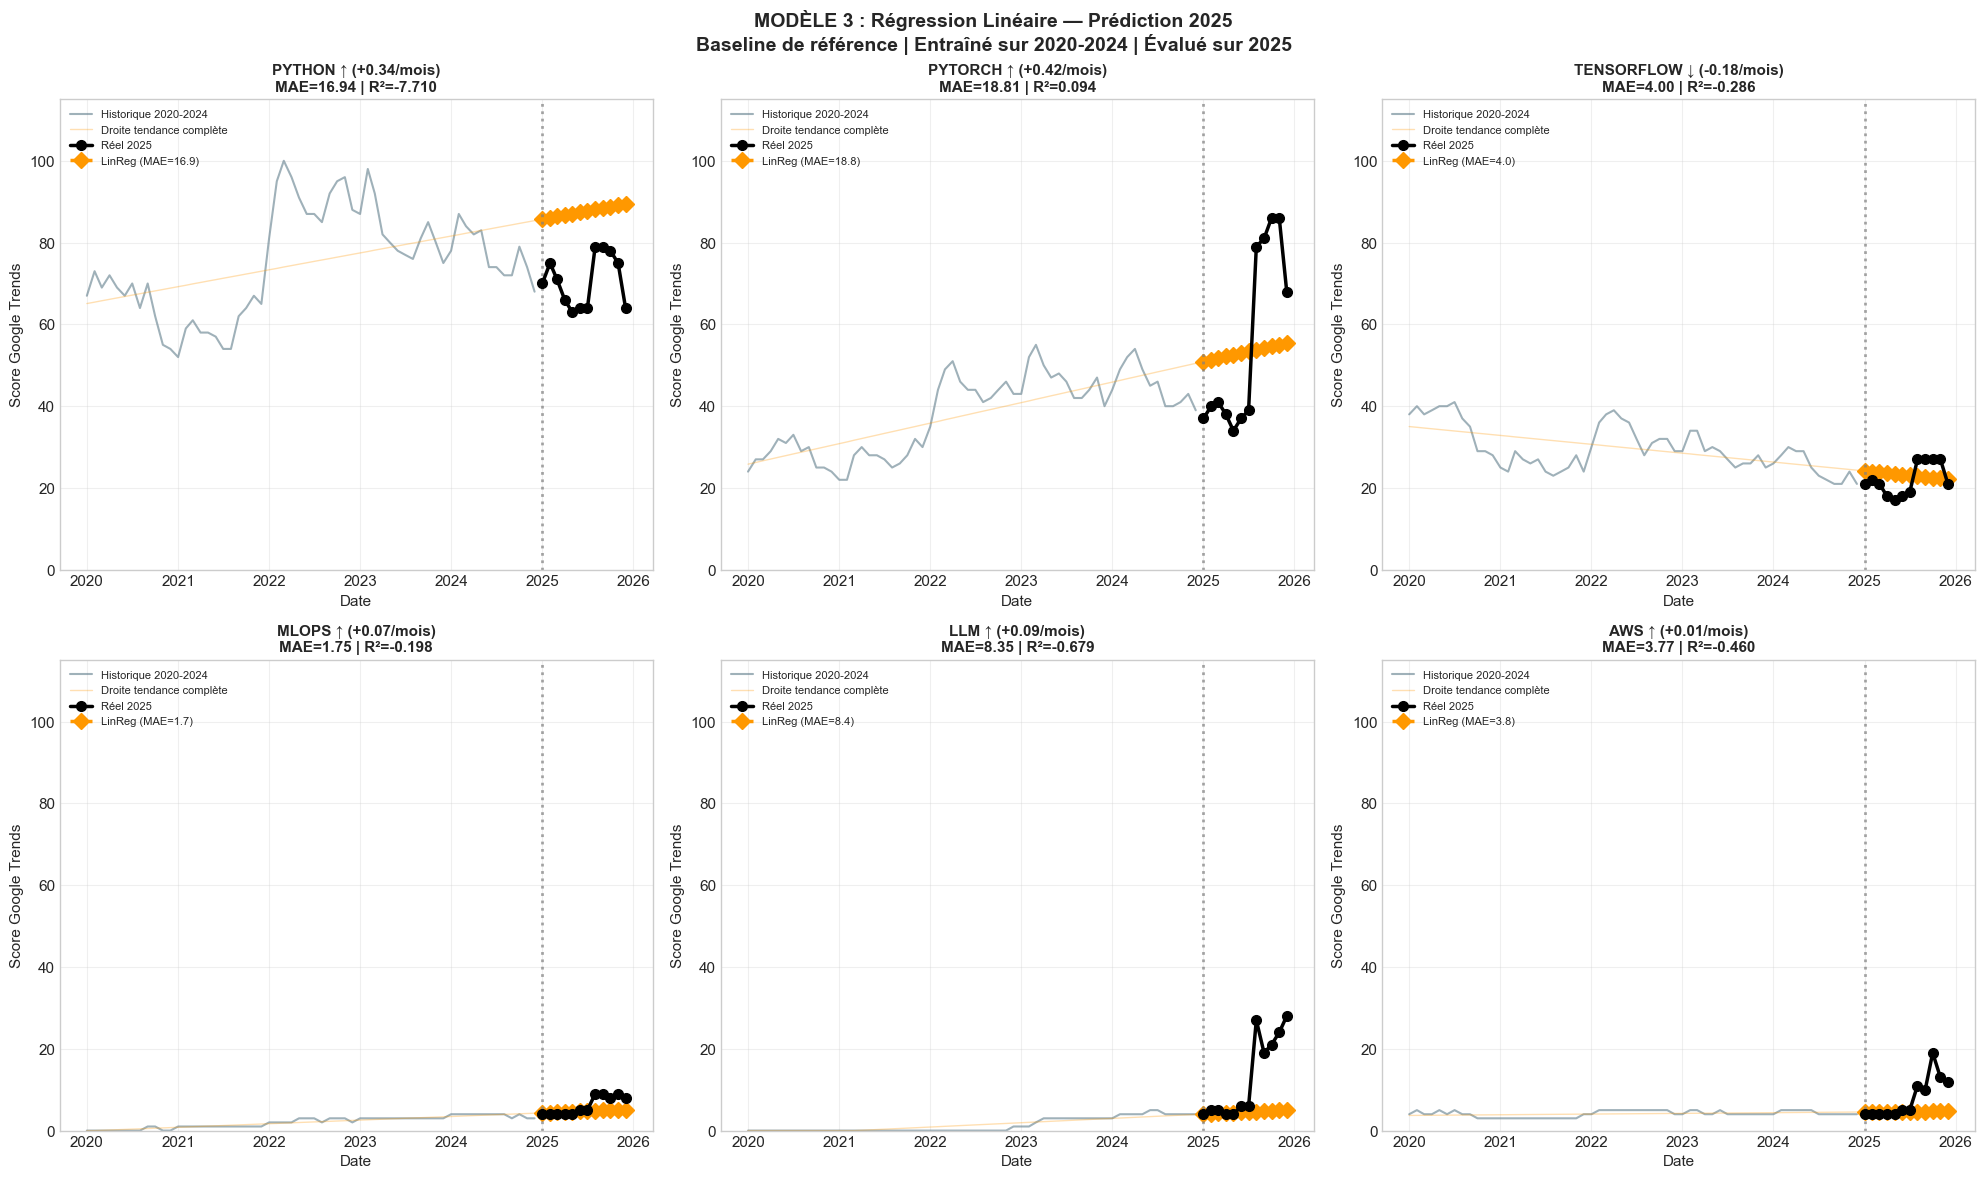


📊 RÉSUMÉ RÉGRESSION LINÉAIRE :
   MAE moyen : 8.94
   R² moyen  : -1.540
✅ Sauvegardé : 07_modele3_linreg.png
✅ resultats_lr.pkl sauvegardé


In [38]:
# ============================================================
# MODÈLE 3 : RÉGRESSION LINÉAIRE
#
# C'EST QUOI LA RÉGRESSION LINÉAIRE ?
#   C'est le modèle le plus simple possible
#   Il trace une droite y = a*x + b à travers les données
#   a = pente (combien le score monte/descend par mois)
#   b = valeur de départ
#
# POURQUOI L'INCLURE COMME 3ÈME MODÈLE ?
#   La régression linéaire est la BASELINE de référence
#   Si Prophet et ARIMA ne font pas mieux qu'une simple droite
#   → ces modèles complexes ne valent rien sur ces données
#   Si Prophet fait mieux → Prophet est justifié
#
# AVANTAGES :
#   Très simple à comprendre et expliquer
#   Très rapide à calculer
#   Interprétable : on voit directement la tendance
#
# LIMITES :
#   Suppose que la tendance est une droite parfaite
#   Ne gère pas la saisonnalité
#   Ne gère pas les changements brusques (ChatGPT en 2022)
#   → C'est pour ça que Prophet et ARIMA existent
#
# COMMENT ON TRANSFORME LE TEMPS EN NOMBRE ?
#   Date 2020-01 → X = 0
#   Date 2020-02 → X = 1
#   Date 2020-03 → X = 2
#   ...
#   Date 2024-12 → X = 59  (fin du train)
#   Date 2025-01 → X = 60  (début du test)
#   La droite prédit y à partir de x
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

df_trends_mensuel = pd.read_csv(
    "google_trends_data.csv",
    index_col='date', parse_dates=True
)

SKILLS_TEST = ['python', 'pytorch', 'tensorflow',
               'mlops', 'llm', 'aws']
SKILLS_TEST = [s for s in SKILLS_TEST
               if s in df_trends_mensuel.columns]

TRAIN_FIN = '2024-12-31'
TEST_DEB  = '2025-01-01'

resultats_lr = {}

print("="*60)
print("MODÈLE 3 : RÉGRESSION LINÉAIRE (Baseline)")
print("Train: 2020-2024 | Test: 2025")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, skill in enumerate(SKILLS_TEST):
    ax = axes[idx]

    serie = df_trends_mensuel[skill].dropna()
    train = serie[:TRAIN_FIN]
    test  = serie[TEST_DEB:]

    if len(test) == 0:
        continue

    # ---- Entraînement Régression Linéaire ----
    # X = numéro du mois (0, 1, 2, ... 59)
    # y = score Google Trends
    X_train = np.arange(len(train)).reshape(-1, 1)
    y_train = train.values

    # X test = numéros des mois futurs (60, 61, ... 71)
    X_test = np.arange(
        len(train), len(train) + len(test)
    ).reshape(-1, 1)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    pred_lr = np.clip(lr.predict(X_test), 0, 100)

    mae = mean_absolute_error(test.values, pred_lr)
    r2  = r2_score(test.values, pred_lr)

    # Pente = combien le score change par mois
    pente = lr.coef_[0]

    resultats_lr[skill] = {
        'pred': pred_lr,
        'mae':  mae,
        'r2':   r2,
        'pente': pente,
        'test_reel':  test.values,
        'test_index': test.index,
        'train':      train
    }

    print(f"\n{skill.upper()} :")
    print(f"  Pente  = {pente:+.3f} points/mois")
    print(f"  MAE    = {mae:.2f} points")
    print(f"  R²     = {r2:.3f}")

    # Aussi tracer la droite complète (train + test)
    X_tout = np.arange(
        len(train) + len(test)
    ).reshape(-1, 1)
    pred_droite = np.clip(lr.predict(X_tout), 0, 100)
    dates_tout  = pd.date_range(
        train.index[0], periods=len(train)+len(test), freq='MS'
    )

    # ---- Graphique ----
    ax.plot(train.index, train.values,
            '-', color='#607D8B',
            linewidth=1.5, alpha=0.6,
            label='Historique 2020-2024')

    # Droite de tendance complète (fine, en arrière-plan)
    ax.plot(dates_tout, pred_droite,
            '-', color='#FF9800',
            linewidth=1, alpha=0.3,
            label='Droite tendance complète')

    ax.plot(test.index, test.values,
            'o-', color='black',
            linewidth=2.5, markersize=7,
            label='Réel 2025', zorder=6)

    ax.plot(test.index, pred_lr,
            'D--', color='#FF9800',
            linewidth=2.5, markersize=8,
            label=f'LinReg (MAE={mae:.1f})')

    ax.axvline(x=pd.Timestamp(TEST_DEB),
               color='gray', linestyle=':',
               linewidth=2, alpha=0.7)

    direction = "↑" if pente > 0 else "↓"
    ax.set_title(
        f"{skill.upper()} {direction} "
        f"({pente:+.2f}/mois)\n"
        f"MAE={mae:.2f} | R²={r2:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel("Score Google Trends")
    ax.set_xlabel("Date")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 115)

plt.suptitle(
    "MODÈLE 3 : Régression Linéaire — Prédiction 2025\n"
    "Baseline de référence | "
    "Entraîné sur 2020-2024 | Évalué sur 2025",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig("images_rapport/07_modele3_linreg.png",
            dpi=150, bbox_inches='tight')
plt.show()

mae_moy = np.mean([r['mae'] for r in resultats_lr.values()])
r2_moy  = np.mean([r['r2']  for r in resultats_lr.values()])
print(f"\n📊 RÉSUMÉ RÉGRESSION LINÉAIRE :")
print(f"   MAE moyen : {mae_moy:.2f}")
print(f"   R² moyen  : {r2_moy:.3f}")
print("✅ Sauvegardé : 07_modele3_linreg.png")

with open("resultats_lr.pkl", "wb") as f:
    pickle.dump(resultats_lr, f)
print("✅ resultats_lr.pkl sauvegardé")